In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.patches as ps
import torch
#import torch_geometric
import pandas as pd
import torch.nn as nn
import optuna

print(optuna.__version__)
optuna.logging.set_verbosity(optuna.logging.WARNING)

import torch, os

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.tri as mtri

from pathlib import Path
from models import CondSM
from scipy.optimize import curve_fit
from sm import NeuralNet
from utils import create_dopant_configuration, current_distribution

print(torch.version.cuda)
print(torch.__version__)

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 11,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 10,    # affects horizontal colorbar ticks
    "ytick.labelsize": 9,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "legend.fontsize": 9,
})

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

4.4.0
12.6
2.10.0+cu126
cuda


7
Best voltage vector: tensor([-0.7615, -0.5057,  0.7243,  1.2858,  0.9933,  1.3125])


"data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_BO/bayes_opt_data_type={data_type}_input_idx={input_index}'\n               f'_func_type={func_type}_lambda_1={lambda_1}_lambda_2={lambda_2}_c_range={c_range}.npz'\n)\nI_true = data['current']*1e21\nI_err = 1.96 * data['sem']\n\nI_true_z  = (I_true - I_true.mean()) / I_true.std()\n\nplt.plot(input_range.squeeze(), I_true)"

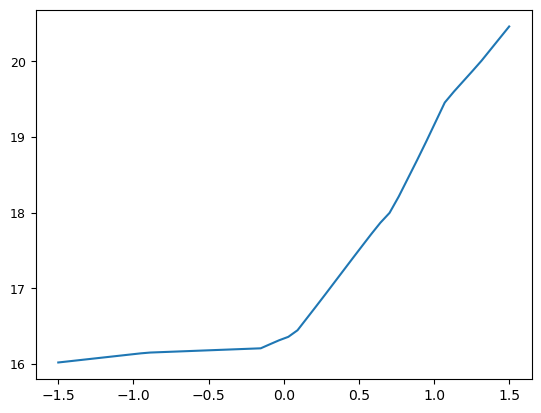

In [3]:
data_type = 'data_vMB_ring_1e7'
func_type = 'ReLU'
input_index = 3
num_voltages = 7
lambda_1 = 0.0
lambda_2 = 1.0
c_range = 1.5
state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/final_datasets/{data_type}/sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth', weights_only=False, map_location='cuda')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])

df = pd.read_csv(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_BO/bayes_opt_data_type={data_type}_input_idx={input_index}'
                 f'_func_type={func_type}_lambda_1={lambda_1}__lambda_2={lambda_2}_c_range={c_range}.csv'
)
best_target_idx = np.argmax(df['target'].to_numpy())
print(best_target_idx)
control_volts = torch.tensor(df[[f"x{i}" for i in range(6)]].to_numpy(), dtype=torch.float32)
print('Best voltage vector:', control_volts[best_target_idx, :])
n = 50
best_control_volts = control_volts[best_target_idx, :].expand(n, -1)

control_indices = [c_index for c_index in range(num_voltages) if c_index != input_index]

input_range = torch.linspace(-1.5, 1.5, n).unsqueeze(0)

input_tensor = torch.zeros(n, num_voltages)
for k, c_index in enumerate(control_indices):
    input_tensor[:, c_index] = best_control_volts[:, k]

input_tensor[:, input_index] = input_range

model.eval()
with torch.no_grad():
    y_out = model(input_tensor).detach().numpy().squeeze()

plt.plot(input_range.squeeze(), y_out)

"""data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_BO/bayes_opt_data_type={data_type}_input_idx={input_index}'
               f'_func_type={func_type}_lambda_1={lambda_1}_lambda_2={lambda_2}_c_range={c_range}.npz'
)
I_true = data['current']*1e21
I_err = 1.96 * data['sem']

I_true_z  = (I_true - I_true.mean()) / I_true.std()

plt.plot(input_range.squeeze(), I_true)"""

In [5]:
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "font.size": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 8,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

# -----------------------------
# Target functions
# -----------------------------
def make_target_function(func_type: str):
    if func_type == "ReLU":
        m = nn.ReLU()
        return lambda x: m(x)
    if func_type == "Sigmoid":
        m = nn.Sigmoid()
        return lambda x: m(4 * x)
    if func_type == "Parabola":
        return lambda x: x**2
    if func_type == "Cubic":
        return lambda x: x**3
    if func_type == "Sine":
        return lambda x: torch.sin(3 * x)
    if func_type == "Cosine":
        return lambda x: torch.cos(3 * x)
    raise ValueError(f"Unknown func_type={func_type}")

def zscore(x: torch.Tensor, eps: float = 1e-8):
    return (x - x.mean()) / (x.std() + eps)

# -----------------------------
# Model loader helper
# -----------------------------
def load_condsm_for_datatype(CondSM_cls, ckpt_path: str, device="cuda"):
    state_dict = torch.load(ckpt_path, weights_only=False, map_location=device)
    model = CondSM_cls(state_dict["layer_dims"], state_dict["dropout"], state_dict["batch_norm"]).to(device)
    model.load_state_dict(state_dict["model_state_dict"])
    model.eval()
    return model

# -----------------------------
# Build input tensor given one random-sampled control vector
# (mirrors your current logic)
# -----------------------------
def build_input_tensor_from_npz(
    npz: dict,
    n: int,
    in_idx: int,
    x_min: float = -1.5,
    x_max: float =  1.5,
    device="cuda",
):
    true_output_idx = 0
    true_input_idx = in_idx + 1  # matches your convention

    # npz['control'] appears to be one best control vector (shape (8,) or similar)
    # You delete output idx and true input idx to obtain the 6 controls.
    ctrl6 = np.delete(npz["control"], [true_output_idx, true_input_idx])
    controls = torch.from_numpy(ctrl6).to(device).float().expand(n, -1)

    # Insert x at the right place so that x corresponds to original true_input_idx
    c_left, c_right = controls[:, :in_idx], controls[:, in_idx:]
    x = torch.linspace(x_min, x_max, n, device=device).unsqueeze(1)
    x_full = torch.cat([c_left, x, c_right], dim=-1)  # shape (n, 7)
    return x.squeeze(1), x_full

# -----------------------------
# Single-panel plotting styles
# -----------------------------
def plot_panel_raw(ax, x, y_sm, I_out, I_err, title=None, show_ylabel=False):
    ax.plot(x, y_sm, lw=1.0, label="SM")
    ax.fill_between(x, I_out - I_err, I_out + I_err, alpha=0.25, label="kMC band", color='green')
    ax.plot(x, I_out, lw=0.9, label="kMC", color='green')

    ax.set_xlabel(r"$V$ [V]")
    if show_ylabel:
        ax.set_ylabel(r"$I_{\mathrm{out}}$ [nA]")
    if title:
        ax.set_title(title)

def plot_panel_z(ax, x, y_sm, y_tgt, title=None, show_ylabel=False):
    ax.plot(x, zscore(y_sm), lw=1.0, label="SM")
    ax.plot(x, zscore(y_tgt), lw=1.0, label="Target")
    ax.set_xlabel(r"$V$ [V]")
    if show_ylabel:
        ax.set_ylabel("Z-score")
    if title:
        ax.set_title(title)

# -----------------------------
# Main grid plotting function
# -----------------------------
def plot_inverse_design_grid(
    CondSM_cls,
    model_ckpt_template: str,     # f".../{data_type}/sm_{data_type}_baseline_0_epochs=1000_....pth"
    npz_template: str,            # f".../random_func_type={func_type}_data_type={data_type}_maxl2=2.0_input_idx={in_idx}_seed={seed}.npz"
    out_pdf: str,
    func_types: list[str],
    data_types: list[str],
    in_idx: int,
    seed: int,
    n: int = 50,
    time_scale: float = 1e21,
    x_min: float = -1.5,
    x_max: float =  1.5,
    device: str = "cuda",
    mode: str = "z",              # "raw" or "z"
    sharex: bool = True,
    sharey: bool = True,
    compact: bool = True,
):
    """
    Creates a grid:
      rows = func_types
      cols = data_types
    Each cell is either:
      - raw fit (SM + kMC band), or
      - z-scored target vs solution.
    """

    n_rows = len(func_types)
    n_cols = len(data_types)

    # Pre-load models once per data_type
    models = {}
    for dt in data_types:
        ckpt_path = model_ckpt_template.format(data_type=dt)
        models[dt] = load_condsm_for_datatype(CondSM_cls, ckpt_path, device=device)

    # Figure sizing: keep panels compact and square-ish
    # You can tweak these numbers; they work well for paper grids.
    panel_w = 2.2 if compact else 3.0
    panel_h = 2.0 if compact else 2.7
    fig_w = panel_w * n_cols
    fig_h = panel_h * n_rows
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(fig_w, fig_h),
        sharex=sharex, sharey=sharey,
        squeeze=False
    )

    # Reduce whitespace for paper
    fig.subplots_adjust(left=0.06, right=0.995, bottom=0.08, top=0.92, wspace=0.08, hspace=0.15)

    # Create ONE global legend later
    legend_handles = None
    legend_labels = None

    for i, func_type in enumerate(func_types):
        tgt_fn = make_target_function(func_type)

        for j, dt in enumerate(data_types):
            ax = axes[i, j]

            # Load NPZ for best random solution
            npz_path = npz_template.format(func_type=func_type, data_type=dt, in_idx=in_idx, seed=seed)
            data = np.load(npz_path)

            # Build input tensor and predict
            x, x_full = build_input_tensor_from_npz(
                data, n=n, in_idx=in_idx, x_min=x_min, x_max=x_max, device=device
            )

            with torch.no_grad():
                y_sm = models[dt](x_full).detach().cpu().squeeze()

            I_out = torch.tensor(data["current"], dtype=torch.float32) * time_scale
            I_err = torch.tensor(data["sem"], dtype=torch.float32) * time_scale

            # Style: minimal ticks, no per-panel legends
            ax.minorticks_on()
            ax.tick_params(direction="in", which="both", top=True, right=True)
            ax.grid(which="major", alpha=0.25, lw=0.5)

            # Titles: top row = data type, left col = func type (compact)
            title = None
            if i == 0:
                title = dt
            if j == 0:
                # Put function name as y-side annotation (saves vertical space)
                ax.text(
                    -0.28, 0.5, func_type, rotation=90,
                    va="center", ha="center", transform=ax.transAxes
                )

            show_ylabel = (j == 0)  # only left column shows y-label

            if mode == "raw":
                plot_panel_raw(
                    ax, x.cpu().numpy(),
                    y_sm.cpu().numpy(),
                    I_out.cpu().numpy(),
                    I_err.cpu().numpy(),
                    title=title,
                    show_ylabel=show_ylabel
                )
            elif mode == "z":
                y_tgt = tgt_fn(x.cpu())
                plot_panel_z(
                    ax, x.cpu().numpy(),
                    y_sm.cpu().numpy(),
                    y_tgt.cpu().numpy(),
                    title=title,
                    show_ylabel=show_ylabel
                )
            else:
                raise ValueError("mode must be 'raw' or 'z'")

            # Capture legend entries from first axis only
            """if legend_handles is None:
                h, l = ax.get_legend_handles_labels()
                legend_handles, legend_labels = h, l"""

            # Remove repeated labels for compactness
            if compact:
                if i != n_rows - 1:
                    ax.set_xlabel("")
                if j != 0:
                    ax.set_ylabel("")
                # Optional: hide tick labels except bottom row / left column
                if i != n_rows - 1:
                    ax.tick_params(labelbottom=False)
                if j != 0:
                    ax.tick_params(labelleft=False)

    # Global title and legend (single legend)
    fig.suptitle("Inverse design via random programming (best-of-N)", y=0.985)

    # --- collect legend entries from all axes (so "Target" always appears) ---
    handles, labels = [], []
    for ax in fig.axes:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    
    # de-duplicate while preserving order
    seen = set()
    legend_handles, legend_labels = [], []
    for h, lab in zip(handles, labels):
        if lab and lab not in seen:
            legend_handles.append(h)
            legend_labels.append(lab)
            seen.add(lab)
    
        
    # Put legend across top or bottom; adjust as you like
    if legend_handles:
        fig.legend(
            legend_handles, legend_labels,
            loc="upper center", ncol=min(4, len(legend_labels)),
            frameon=False, bbox_to_anchor=(0.5, 0.955)
        )

    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_pdf}")

# -----------------------------
# Optional: 2-row per target (raw + z) in one figure
# -----------------------------
def plot_inverse_design_grid_dual(
    CondSM_cls,
    model_ckpt_template: str,
    npz_template: str,
    out_pdf: str,
    func_types: list[str],
    data_types: list[str],
    in_idx: int,
    seed: int,
    n: int = 50,
    time_scale: float = 1e21,
    x_min: float = -1.5,
    x_max: float =  1.5,
    device: str = "cuda",
):
    """
    Creates a grid with 2 rows per function:
      For each function:
        row 2k: raw
        row 2k+1: z
      cols: data_types
    """
    doubled_funcs = []
    for f in func_types:
        doubled_funcs.append((f, "raw"))
        doubled_funcs.append((f, "z"))

    n_rows = len(doubled_funcs)
    n_cols = len(data_types)

    models = {}
    for dt in data_types:
        ckpt_path = model_ckpt_template.format(data_type=dt)
        models[dt] = load_condsm_for_datatype(CondSM_cls, ckpt_path, device=device)

    panel_w, panel_h = 2.2, 1.6
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(panel_w * n_cols, panel_h * n_rows),
        sharex=True, sharey=False, squeeze=False
    )
    fig.subplots_adjust(left=0.06, right=0.995, bottom=0.06, top=0.94, wspace=0.08, hspace=0.18)

    legend_handles = None
    legend_labels = None

    for i, (func_type, mode) in enumerate(doubled_funcs):
        tgt_fn = make_target_function(func_type)

        for j, dt in enumerate(data_types):
            ax = axes[i, j]
            npz_path = npz_template.format(func_type=func_type, data_type=dt, in_idx=in_idx, seed=seed)
            data = np.load(npz_path)

            x, x_full = build_input_tensor_from_npz(data, n=n, in_idx=in_idx, x_min=x_min, x_max=x_max, device=device)
            #print(func_type)
            #print(x_full[:2, :])
            with torch.no_grad():
                y_sm = models[dt](x_full).detach().cpu().squeeze()

            I_out = torch.tensor(data["current"], dtype=torch.float32) * time_scale
            I_err = torch.tensor(data["sem"], dtype=torch.float32) * time_scale

            ax.minorticks_on()
            ax.tick_params(direction="in", which="both", top=True, right=True)
            ax.grid(which="major", alpha=0.25, lw=0.5)

            """if i == 0:
                ax.set_title(dt)"""

            if j == 0:
                ax.text(
                    -0.28, 0.5, f"{func_type}", rotation=90,
                    va="center", ha="center", transform=ax.transAxes, fontsize=8
                )

            if mode == "raw":
                plot_panel_raw(ax, x.cpu().numpy(), y_sm.cpu().numpy(),
                               I_out.cpu().numpy(), I_err.cpu().numpy(),
                               title=None, show_ylabel=(j == 0))
            else:
                y_tgt = tgt_fn(x.cpu())
                plot_panel_z(ax, x.cpu().numpy(), y_sm.cpu().numpy(),
                             y_tgt.cpu().numpy(),
                             title=None, show_ylabel=(j == 0))

            """if legend_handles is None:
                h, l = ax.get_legend_handles_labels()
                legend_handles, legend_labels = h, l"""
                
            if j != 0:
                ax.set_ylabel("")
                ax.tick_params(labelleft=False)
            if i != n_rows - 1:
                ax.set_xlabel("")
                ax.tick_params(labelbottom=False)

    # --- collect legend entries from all axes ---
    handles, labels = [], []
    for ax in fig.axes:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    
    # de-duplicate while preserving order
    seen = set()
    legend_handles, legend_labels = [], []
    for h, lab in zip(handles, labels):
        if lab and lab not in seen:
            legend_handles.append(h)
            legend_labels.append(lab)
            seen.add(lab)


    #fig.suptitle("Best-of-N random programming: raw + z-scored view", y=0.985)
    if legend_handles and legend_labels:
        fig.legend(legend_handles, legend_labels, loc="upper center",
                   ncol=min(4, len(legend_labels)), frameon=False,
                   bbox_to_anchor=(0.5, 0.96))

    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_pdf}")


In [6]:
from models import CondSM

model_types = ['uni_1e7', 'data_vMB_ring_1e7', 'grad_towards_1e7', 'grad_away_1e7']
func_types  = ["ReLU", "Sigmoid", "Parabola", "Sine"]  # your 4 targets

model_ckpt_template = (
    "/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/final_datasets/{data_type}/"
    "sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth"
)

npz_template = (
    "/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_BO/"
    "bayes_opt_data_type={data_type}_input_idx=3_func_type={func_type}_lambda_1=0.0_lambda_2=1.0_c_range=1.5.npz"
)

plot_inverse_design_grid_dual(
    CondSM_cls=CondSM,
    model_ckpt_template=model_ckpt_template,
    npz_template=npz_template,
    out_pdf="grid_bo_funcs.pdf",
    func_types=func_types,
    data_types=model_types,
    in_idx=3,
    seed=42,
)

Saved: grid_bo_funcs.pdf


## rnd sampling 1d

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ecdf_grid_4targets(
    func_types,
    data_types,
    scores_txt_template,
    out_pdf,
    data_type_labels=None,    # NEW: dict {data_type: "Nice label"} or list same length as data_types
    max_points=50_000,
    ncols=2,
    figsize=(7.2, 7.2),
    xscale=None,
    yscale=None,
    use_ccdf=False,
    ccdf_logy=True,
    global_xlim_quantiles=(0.0, 0.99),
    legend=True,
    seed_for_subsample=0,
):
    rng = np.random.default_rng(seed_for_subsample)

    # ---- build mapping dt -> label ----
    if data_type_labels is None:
        dt2lab = {dt: dt for dt in data_types}
    elif isinstance(data_type_labels, dict):
        dt2lab = {dt: data_type_labels.get(dt, dt) for dt in data_types}
    else:
        # assume list/tuple aligned with data_types
        if len(data_type_labels) != len(data_types):
            raise ValueError("data_type_labels must be dict or list with same length as data_types")
        dt2lab = {dt: lab for dt, lab in zip(data_types, data_type_labels)}

    # ---- pass 1: global x-limits ----
    all_vals = []
    for func_type in func_types:
        for dt in data_types:
            p = scores_txt_template.format(data_type=dt, func_type=func_type)
            s = np.loadtxt(p)
            s = np.asarray(s, float).ravel()
            s = s[np.isfinite(s)]
            if max_points is not None and len(s) > max_points:
                idx = rng.choice(len(s), size=max_points, replace=False)
                s = s[idx]
            if len(s):
                all_vals.append(s)

    if len(all_vals) == 0:
        raise RuntimeError("No score values loaded. Check scores_txt_template paths.")

    all_vals = np.concatenate(all_vals)
    lo_q, hi_q = global_xlim_quantiles
    xmin = float(np.quantile(all_vals, lo_q))
    xmax = float(np.quantile(all_vals, hi_q))
    if xmin == xmax:
        xmin, xmax = float(np.min(all_vals)), float(np.max(all_vals))

    # ---- pass 2: plot grid ----
    n_targets = len(func_types)
    nrows = int(np.ceil(n_targets / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.flatten()
    fig.subplots_adjust(left=0.10, right=0.98, bottom=0.08, top=0.88, wspace=0.18, hspace=0.22)

    for k, func_type in enumerate(func_types):
        ax = axes[k]
        ax.minorticks_on()
        ax.tick_params(top=True, right=True, which='both', direction='in')
        ax.grid(lw=0.5, alpha=0.5, which='major')
        ax.grid(lw=0.5, alpha=0.35, which='minor', axis='y')
        ax.set_box_aspect(1)

        for dt in data_types:
            scores_path = scores_txt_template.format(data_type=dt, func_type=func_type)
            s = np.loadtxt(scores_path)
            s = np.asarray(s, float).ravel()
            s = s[np.isfinite(s)]
            if max_points is not None and len(s) > max_points:
                idx = rng.choice(len(s), size=max_points, replace=False)
                s = s[idx]

            s_sorted = np.sort(s)
            n = len(s_sorted)
            if n == 0:
                continue

            ecdf = np.arange(1, n + 1) / n
            label = dt2lab[dt]   # NEW: custom label

            if use_ccdf:
                y = 1.0 - ecdf
                ax.plot(s_sorted, y, lw=1.6, label=label)
            else:
                ax.plot(s_sorted, ecdf, lw=1.6, label=label)

        ax.set_title(f"{func_type}", fontdict={'weight': 'bold'})
        ax.set_xlabel(r"Fitness $\mathcal{E}_Z$")

        if k % ncols == 0:
            ax.set_ylabel(r"$\mathrm{ECDF}(\mathcal{E}_Z)$" if not use_ccdf else r"$1-\mathrm{ECDF}(\mathcal{E}_Z)$")
        else:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)

        ax.set_xlim(xmin, xmax)

        if use_ccdf and ccdf_logy:
            ax.set_yscale("log")
            ax.set_ylim(1.0 / (max_points if max_points else 100_000), 1.0)
        else:
            ax.set_ylim(0.0, 1.0)

        if xscale is not None:
            ax.set_xscale(xscale)
        if yscale is not None and not (use_ccdf and ccdf_logy):
            ax.set_yscale(yscale)

    for kk in range(n_targets, len(axes)):
        axes[kk].axis("off")

    # ---- global legend (dedupe) ----
    if legend:
        handles, labels = [], []
        for ax in fig.axes:
            h, l = ax.get_legend_handles_labels()
            handles.extend(h)
            labels.extend(l)

        seen = set()
        H, L = [], []
        for h, lab in zip(handles, labels):
            if lab and lab not in seen:
                H.append(h); L.append(lab); seen.add(lab)

        fig.legend(
            H, L,
            loc="upper center",
            ncol=min(4, len(L)),
            frameon=False,
            bbox_to_anchor=(0.5, 0.96),
            columnspacing=1.0,
            handlelength=1.6,
            handletextpad=0.4,
        )

    fig.savefig(out_pdf, bbox_inches="tight", pad_inches=0.08)
    plt.close(fig)
    print(f"Saved: {out_pdf}\nShared x-limits: [{xmin:.4g}, {xmax:.4g}] (quantiles {global_xlim_quantiles})")

import numpy as np
import matplotlib.pyplot as plt

def plot_ecdf_grid_1row(
    func_types,
    data_types,
    scores_txt_template,
    out_pdf,
    data_type_labels=None,
    max_points=50_000,
    figsize=None,                 # if None, chosen automatically
    xscale=None,
    yscale=None,
    use_ccdf=False,
    ccdf_logy=True,
    global_xlim_quantiles=(0.0, 0.99),
    legend=True,
    seed_for_subsample=0,
):
    rng = np.random.default_rng(seed_for_subsample)

    # ---- build mapping dt -> label ----
    if data_type_labels is None:
        dt2lab = {dt: dt for dt in data_types}
    elif isinstance(data_type_labels, dict):
        dt2lab = {dt: data_type_labels.get(dt, dt) for dt in data_types}
    else:
        if len(data_type_labels) != len(data_types):
            raise ValueError("data_type_labels must be dict or list with same length as data_types")
        dt2lab = {dt: lab for dt, lab in zip(data_types, data_type_labels)}

    # ---- pass 1: global x-limits ----
    all_vals = []
    for func_type in func_types:
        for dt in data_types:
            p = scores_txt_template.format(data_type=dt, func_type=func_type)
            s = np.loadtxt(p)
            s = np.asarray(s, float).ravel()
            s = s[np.isfinite(s)]
            if max_points is not None and len(s) > max_points:
                idx = rng.choice(len(s), size=max_points, replace=False)
                s = s[idx]
            if len(s):
                all_vals.append(s)

    if len(all_vals) == 0:
        raise RuntimeError("No score values loaded. Check scores_txt_template paths.")

    all_vals = np.concatenate(all_vals)
    lo_q, hi_q = global_xlim_quantiles
    xmin = float(np.quantile(all_vals, lo_q))
    xmax = float(np.quantile(all_vals, hi_q))
    if xmin == xmax:
        xmin, xmax = float(np.min(all_vals)), float(np.max(all_vals))

    # ---- force 1-row layout ----
    n_targets = len(func_types)
    nrows, ncols = 1, n_targets

    # choose a reasonable default figsize if not provided
    if figsize is None:
        # ~2.4 inches per panel wide, ~2.4 inches tall
        figsize = (2.4 * n_targets, 2.6)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.flatten()

    # More top space for legend; compact spacing between panels
    fig.subplots_adjust(left=0.06, right=0.995, bottom=0.18, top=0.80, wspace=0.01, hspace=0.0)

    for k, func_type in enumerate(func_types):
        ax = axes[k]
        ax.minorticks_on()
        ax.tick_params(top=True, right=True, which='both', direction='in')
        ax.grid(lw=0.5, alpha=0.5, which='major')
        ax.grid(lw=0.5, alpha=0.35, which='minor', axis='y')
        ax.set_box_aspect(0.88)

        for dt in data_types:
            scores_path = scores_txt_template.format(data_type=dt, func_type=func_type)
            s = np.loadtxt(scores_path)
            s = np.asarray(s, float).ravel()
            s = s[np.isfinite(s)]
            if max_points is not None and len(s) > max_points:
                idx = rng.choice(len(s), size=max_points, replace=False)
                s = s[idx]

            s_sorted = np.sort(s)
            n = len(s_sorted)
            if n == 0:
                continue

            ecdf = np.arange(1, n + 1) / n
            label = dt2lab[dt]

            if use_ccdf:
                y = 1.0 - ecdf
                ax.plot(s_sorted, y, lw=1.6, label=label)
            else:
                ax.plot(s_sorted, ecdf, lw=1.6, label=label)

        ax.set_title(f"{func_type}", fontdict={'weight': 'bold'})
        ax.set_xlabel(r"Fitness $\mathcal{E}_Z$")
        ax.set_xlim(xmin, xmax)

        # only first panel shows y-label to save space
        if k == 0:
            ax.set_ylabel(r"$\mathrm{ECDF}(\mathcal{E}_{\mathrm{aff}})$" if not use_ccdf else r"$1-\mathrm{ECDF}(\mathcal{E}_{\mathrm{aff}})$")
        else:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)

        if use_ccdf and ccdf_logy:
            ax.set_yscale("log")
            ax.set_ylim(1.0 / (max_points if max_points else 100_000), 1.0)
        else:
            ax.set_ylim(0.0, 1.0)

        if xscale is not None:
            ax.set_xscale(xscale)
        if yscale is not None and not (use_ccdf and ccdf_logy):
            ax.set_yscale(yscale)

    # ---- global legend ----
    if legend:
        handles, labels = [], []
        for ax in fig.axes:
            h, l = ax.get_legend_handles_labels()
            handles.extend(h)
            labels.extend(l)

        seen = set()
        H, L = [], []
        for h, lab in zip(handles, labels):
            if lab and lab not in seen:
                H.append(h); L.append(lab); seen.add(lab)

        fig.legend(
            H, L,
            loc="upper center",
            ncol=min(len(L), 6),
            frameon=False,
            bbox_to_anchor=(0.5, 0.98),
            columnspacing=1.0,
            handlelength=1.6,
            handletextpad=0.4,
        )

    fig.savefig(out_pdf, bbox_inches="tight", pad_inches=0.04)
    plt.close(fig)
    print(f"Saved: {out_pdf}\nShared x-limits: [{xmin:.4g}, {xmax:.4g}] (quantiles {global_xlim_quantiles})")


import numpy as np
import matplotlib.pyplot as plt

def plot_ccdf_grid_1row(
    func_types,
    data_types,
    scores_txt_template,
    out_pdf,
    data_type_labels=None,
    max_points=50_000,
    figsize=None,                 # if None, chosen automatically
    xscale=None,                  # e.g. "log" or None
    yscale="log",                 # CCDF is usually best on log-y
    global_xlim_quantiles=(0.0, 0.99),
    ccdf_floor=None,              # if None, uses 1/max_points (or 1/n)
    legend=True,
    seed_for_subsample=0,
):
    """
    1-row grid of CCDF curves across multiple target functions.
    CCDF(s) = P(score >= s) = 1 - ECDF(s).

    Parameters
    ----------
    func_types : list[str]
        Target function names (one panel per target).
    data_types : list[str]
        Dataset/model identifiers (one CCDF curve per data_type in each panel).
    scores_txt_template : str
        Path template with {data_type} and {func_type}.
    out_pdf : str
        Output path for PDF.
    data_type_labels : dict or list or None
        Mapping from data_type -> label, or list aligned with data_types.
    max_points : int or None
        Subsample size per curve to speed up plotting.
    xscale : str or None
        Matplotlib xscale ("log" often helpful if scores span decades).
    yscale : str or None
        Typically "log" for CCDF.
    global_xlim_quantiles : tuple(float,float)
        Quantiles for shared x-limits computed across all curves.
    ccdf_floor : float or None
        Lower y-limit for log-y. If None, uses 1/max_points if max_points else 1/n per curve.
    legend : bool
        Add a global legend.
    seed_for_subsample : int
        RNG seed for subsampling.
    """
    rng = np.random.default_rng(seed_for_subsample)

    # ---- build mapping dt -> label ----
    if data_type_labels is None:
        dt2lab = {dt: dt for dt in data_types}
    elif isinstance(data_type_labels, dict):
        dt2lab = {dt: data_type_labels.get(dt, dt) for dt in data_types}
    else:
        if len(data_type_labels) != len(data_types):
            raise ValueError("data_type_labels must be dict or list with same length as data_types")
        dt2lab = {dt: lab for dt, lab in zip(data_types, data_type_labels)}

    # ---- pass 1: global x-limits from pooled data (subsampled) ----
    all_vals = []
    for func_type in func_types:
        for dt in data_types:
            p = scores_txt_template.format(data_type=dt, func_type=func_type)
            s = np.loadtxt(p)
            s = np.asarray(s, float).ravel()
            s = s[np.isfinite(s)]
            if max_points is not None and len(s) > max_points:
                idx = rng.choice(len(s), size=max_points, replace=False)
                s = s[idx]
            if len(s):
                all_vals.append(s)

    if len(all_vals) == 0:
        raise RuntimeError("No score values loaded. Check scores_txt_template paths.")

    all_vals = np.concatenate(all_vals)
    lo_q, hi_q = global_xlim_quantiles
    xmin = float(np.quantile(all_vals, lo_q))
    xmax = float(np.quantile(all_vals, hi_q))
    if xmin == xmax:
        xmin, xmax = float(np.min(all_vals)), float(np.max(all_vals))

    # ---- layout: 1 row, one panel per target ----
    n_targets = len(func_types)
    nrows, ncols = 1, n_targets

    if figsize is None:
        figsize = (2.4 * n_targets, 2.6)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize, squeeze=False)
    axes = axes.flatten()
    fig.subplots_adjust(left=0.06, right=0.995, bottom=0.18, top=0.80, wspace=0.01, hspace=0.0)

    for k, func_type in enumerate(func_types):
        ax = axes[k]
        ax.minorticks_on()
        ax.tick_params(top=True, right=True, which='both', direction='in')
        ax.grid(lw=0.5, alpha=0.5, which='major')
        ax.grid(lw=0.5, alpha=0.35, which='minor', axis='y')
        ax.set_box_aspect(0.88)

        for dt in data_types:
            scores_path = scores_txt_template.format(data_type=dt, func_type=func_type)
            s = np.loadtxt(scores_path)
            s = np.asarray(s, float).ravel()
            s = s[np.isfinite(s)]

            if max_points is not None and len(s) > max_points:
                idx = rng.choice(len(s), size=max_points, replace=False)
                s = s[idx]

            s_sorted = np.sort(s)
            n = len(s_sorted)
            if n == 0:
                continue

            ecdf = np.arange(1, n + 1) / n
            ccdf = 1.0 - ecdf

            # avoid zeros when using log-y
            if yscale == "log":
                floor = ccdf_floor
                if floor is None:
                    # best effort floor: 1/max_points if provided else 1/n
                    floor = 1.0 / (max_points if (max_points is not None) else n)
                ccdf = np.clip(ccdf, floor, 1.0)

            ax.plot(s_sorted, ccdf, lw=1.6, label=dt2lab[dt])

        ax.set_title(f"{func_type}", fontdict={'weight': 'bold'})
        ax.set_xlabel(r"Fitness $\mathcal{E}_{\mathrm{aff}}$")
        ax.set_xlim(xmin, xmax)

        if k == 0:
            ax.set_ylabel(r"$1-\mathrm{ECDF}(\mathcal{E}_{\mathrm{aff}})$")
        else:
            ax.set_ylabel("")
            ax.tick_params(labelleft=False)

        if xscale is not None:
            ax.set_xscale(xscale)
        if yscale is not None:
            ax.set_yscale(yscale)

        # y-limits
        if yscale == "log":
            floor = ccdf_floor
            if floor is None:
                floor = 1.0 / (max_points if (max_points is not None) else 100_000)
            ax.set_ylim(floor, 1.0)
        else:
            ax.set_ylim(0.0, 1.0)

    # ---- global legend ----
    if legend:
        handles, labels = [], []
        for ax in fig.axes:
            h, l = ax.get_legend_handles_labels()
            handles.extend(h)
            labels.extend(l)

        seen = set()
        H, L = [], []
        for h, lab in zip(handles, labels):
            if lab and lab not in seen:
                H.append(h); L.append(lab); seen.add(lab)

        fig.legend(
            H, L,
            loc="upper center",
            ncol=min(len(L), 6),
            frameon=False,
            bbox_to_anchor=(0.5, 0.98),
            columnspacing=1.0,
            handlelength=1.6,
            handletextpad=0.4,
        )

    fig.savefig(out_pdf, bbox_inches="tight", pad_inches=0.04)
    plt.close(fig)
    print(f"Saved: {out_pdf}\nShared x-limits: [{xmin:.4g}, {xmax:.4g}] (quantiles {global_xlim_quantiles})")

In [4]:
c_v_min, c_v_max = -1.5, 1.5
seed = 42
max_l2 = 2.0
input_index = 3

base = "/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/1d_funcs_random_mse"

scores_txt_template = (
    base
    + "/scores_random_affine_data_type={data_type}_func={func_type}"
    + f"_cmin={c_v_min}_cmax={c_v_max}_seed={seed}_maxl2={max_l2}_input_idx={input_index}.txt"
)

func_types  = ["ReLU", "Sigmoid", "Parabola", "Sine"]  # your 4 targets
data_type_labels = {
    "uni_1e7": "Uniform",
    "data_vMB_ring_1e7": "Annular",
    "grad_towards_1e7": r"Gradient towards the output",
    "grad_away_1e7": r"Gradient away from the output",
}

"""plot_ecdf_grid_4targets(
    func_types=["ReLU", "Sigmoid", "Parabola", "Sine"],
    data_types=["uni_1e7", "data_vMB_ring_1e7", "grad_towards_1e7", "grad_away_1e7"],
    data_type_labels=data_type_labels,
    scores_txt_template=scores_txt_template,
    out_pdf="ecdf_grid_4targets_customlabels.pdf",
    max_points=50_000,
    use_ccdf=False,
    global_xlim_quantiles=(0.0, 0.99),
    legend=True,
    xscale='log'
)"""

q0 = 0.0
q1 = 1.0
plot_ecdf_grid_1row(
    func_types=["ReLU", "Sigmoid", "Parabola", "Sine"],
    data_types=["uni_1e7", "data_vMB_ring_1e7", "grad_towards_1e7", "grad_away_1e7"],
    data_type_labels=data_type_labels,
    scores_txt_template=scores_txt_template,
    out_pdf=f"ecdf_random_mse_row_4targets_1e6_q0={q0}_q1={q1}.pdf",
    max_points=1_000_000,
    # figsize=(10, 2.8),  # optional override
    use_ccdf=False,
    global_xlim_quantiles=(q0, q1),
    legend=True,
    xscale=None
)

q0, q1 = 0.0, 1.0
plot_ccdf_grid_1row(
    func_types=["ReLU", "Sigmoid", "Parabola", "Sine"],
    data_types=["uni_1e7", "data_vMB_ring_1e7", "grad_towards_1e7", "grad_away_1e7"],
    data_type_labels=data_type_labels,
    scores_txt_template=scores_txt_template,
    out_pdf=f"ccdf_random_mse_row_4targets_1e6_q0={q0}_q1={q1}.pdf",
    max_points=1_000_000,
    xscale=None,      # or "log" if scores span decades
    yscale=None,     # CCDF is usually log-y
    global_xlim_quantiles=(q0, q1),
    legend=True,
)

Saved: ecdf_random_mse_row_4targets_1e6_q0=0.0_q1=1.0.pdf
Shared x-limits: [3.663e-05, 0.4869] (quantiles (0.0, 1.0))
Saved: ccdf_random_mse_row_4targets_1e6_q0=0.0_q1=1.0.pdf
Shared x-limits: [3.663e-05, 0.4869] (quantiles (0.0, 1.0))


In [44]:
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

mpl.rcParams.update({
    "font.size": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.titlesize": 8,
    "axes.labelsize": 8,
    "legend.fontsize": 8,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

# -----------------------------
# Target functions
# -----------------------------
def make_target_function(func_type: str):
    if func_type == "ReLU":
        m = nn.ReLU()
        return lambda x: m(x)
    if func_type == "Sigmoid":
        m = nn.Sigmoid()
        return lambda x: m(4 * x)
    if func_type == "Parabola":
        return lambda x: x**2
    if func_type == "Cubic":
        return lambda x: x**3
    if func_type == "Sine":
        return lambda x: torch.sin(3 * x)
    if func_type == "Cosine":
        return lambda x: torch.cos(3 * x)
    raise ValueError(f"Unknown func_type={func_type}")

def zscore(x: torch.Tensor, eps: float = 1e-8):
    return (x - x.mean()) / (x.std() + eps)

# -----------------------------
# Model loader helper
# -----------------------------
def load_condsm_for_datatype(CondSM_cls, ckpt_path: str, device="cuda"):
    state_dict = torch.load(ckpt_path, weights_only=False, map_location=device)
    model = CondSM_cls(state_dict["layer_dims"], state_dict["dropout"], state_dict["batch_norm"]).to(device)
    model.load_state_dict(state_dict["model_state_dict"])
    model.eval()
    return model

# -----------------------------
# Build input tensor given one random-sampled control vector
# (mirrors your current logic)
# -----------------------------
def build_input_tensor_from_npz(
    npz: dict,
    n: int,
    in_idx: int,
    x_min: float = -1.5,
    x_max: float =  1.5,
    device="cuda",
):
    true_output_idx = 0
    true_input_idx = in_idx + 1  # matches your convention

    # npz['control'] appears to be one best control vector (shape (8,) or similar)
    # You delete output idx and true input idx to obtain the 6 controls.
    ctrl6 = np.delete(npz["control"], [true_output_idx, true_input_idx])
    controls = torch.from_numpy(ctrl6).to(device).float().expand(n, -1)

    # Insert x at the right place so that x corresponds to original true_input_idx
    c_left, c_right = controls[:, :in_idx], controls[:, in_idx:]
    x = torch.linspace(x_min, x_max, n, device=device).unsqueeze(1)
    x_full = torch.cat([c_left, x, c_right], dim=-1)  # shape (n, 7)
    return x.squeeze(1), x_full

# -----------------------------
# Single-panel plotting styles
# -----------------------------
def plot_panel_raw(ax, x, y_sm, I_out, I_err, title=None, show_ylabel=False):
    ax.plot(x, y_sm, lw=1.0, label="SM")
    ax.fill_between(x, I_out - I_err, I_out + I_err, alpha=0.25, label="kMC band", color='green')
    ax.plot(x, I_out, lw=0.9, label="kMC", color='green')

    ax.set_xlabel(r"$V$ [V]")
    if show_ylabel:
        ax.set_ylabel(r"$I_{\mathrm{out}}$ [nA]")
    if title:
        ax.set_title(title)

def plot_panel_z(ax, x, y_sm, y_tgt, title=None, show_ylabel=False):
    ax.plot(x, zscore(y_sm), lw=1.0, label="SM")
    ax.plot(x, zscore(y_tgt), lw=1.0, label="Target")
    ax.set_xlabel(r"$V$ [V]")
    if show_ylabel:
        ax.set_ylabel("Z-score")
    if title:
        ax.set_title(title)

# -----------------------------
# Main grid plotting function
# -----------------------------
def plot_inverse_design_grid(
    CondSM_cls,
    model_ckpt_template: str,     # f".../{data_type}/sm_{data_type}_baseline_0_epochs=1000_....pth"
    npz_template: str,            # f".../random_func_type={func_type}_data_type={data_type}_maxl2=2.0_input_idx={in_idx}_seed={seed}.npz"
    out_pdf: str,
    func_types: list[str],
    data_types: list[str],
    in_idx: int,
    seed: int,
    n: int = 50,
    time_scale: float = 1e21,
    x_min: float = -1.5,
    x_max: float =  1.5,
    device: str = "cuda",
    mode: str = "z",              # "raw" or "z"
    sharex: bool = True,
    sharey: bool = True,
    compact: bool = True,
):
    """
    Creates a grid:
      rows = func_types
      cols = data_types
    Each cell is either:
      - raw fit (SM + kMC band), or
      - z-scored target vs solution.
    """

    n_rows = len(func_types)
    n_cols = len(data_types)

    # Pre-load models once per data_type
    models = {}
    for dt in data_types:
        ckpt_path = model_ckpt_template.format(data_type=dt)
        models[dt] = load_condsm_for_datatype(CondSM_cls, ckpt_path, device=device)

    # Figure sizing: keep panels compact and square-ish
    # You can tweak these numbers; they work well for paper grids.
    panel_w = 2.2 if compact else 3.0
    panel_h = 2.0 if compact else 2.7
    fig_w = panel_w * n_cols
    fig_h = panel_h * n_rows
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(fig_w, fig_h),
        sharex=sharex, sharey=sharey,
        squeeze=False
    )

    # Reduce whitespace for paper
    fig.subplots_adjust(left=0.06, right=0.995, bottom=0.08, top=0.92, wspace=0.08, hspace=0.15)

    # Create ONE global legend later
    legend_handles = None
    legend_labels = None

    for i, func_type in enumerate(func_types):
        tgt_fn = make_target_function(func_type)

        for j, dt in enumerate(data_types):
            ax = axes[i, j]

            # Load NPZ for best random solution
            npz_path = npz_template.format(func_type=func_type, data_type=dt, in_idx=in_idx, seed=seed)
            data = np.load(npz_path)

            # Build input tensor and predict
            x, x_full = build_input_tensor_from_npz(
                data, n=n, in_idx=in_idx, x_min=x_min, x_max=x_max, device=device
            )

            with torch.no_grad():
                y_sm = models[dt](x_full).detach().cpu().squeeze()

            I_out = torch.tensor(data["current"], dtype=torch.float32) * time_scale
            I_err = torch.tensor(data["sem"], dtype=torch.float32) * time_scale

            # Style: minimal ticks, no per-panel legends
            ax.minorticks_on()
            ax.tick_params(direction="in", which="both", top=True, right=True)
            ax.grid(which="major", alpha=0.25, lw=0.5)

            # Titles: top row = data type, left col = func type (compact)
            title = None
            if i == 0:
                title = dt
            if j == 0:
                # Put function name as y-side annotation (saves vertical space)
                ax.text(
                    -0.28, 0.5, func_type, rotation=90,
                    va="center", ha="center", transform=ax.transAxes
                )

            show_ylabel = (j == 0)  # only left column shows y-label

            if mode == "raw":
                plot_panel_raw(
                    ax, x.cpu().numpy(),
                    y_sm.cpu().numpy(),
                    I_out.cpu().numpy(),
                    I_err.cpu().numpy(),
                    title=title,
                    show_ylabel=show_ylabel
                )
            elif mode == "z":
                y_tgt = tgt_fn(x.cpu())
                plot_panel_z(
                    ax, x.cpu().numpy(),
                    y_sm.cpu().numpy(),
                    y_tgt.cpu().numpy(),
                    title=title,
                    show_ylabel=show_ylabel
                )
            else:
                raise ValueError("mode must be 'raw' or 'z'")

            # Capture legend entries from first axis only
            """if legend_handles is None:
                h, l = ax.get_legend_handles_labels()
                legend_handles, legend_labels = h, l"""

            # Remove repeated labels for compactness
            if compact:
                if i != n_rows - 1:
                    ax.set_xlabel("")
                if j != 0:
                    ax.set_ylabel("")
                # Optional: hide tick labels except bottom row / left column
                if i != n_rows - 1:
                    ax.tick_params(labelbottom=False)
                if j != 0:
                    ax.tick_params(labelleft=False)

    # Global title and legend (single legend)
    fig.suptitle("Inverse design via random programming (best-of-N)", y=0.985)

    # --- collect legend entries from all axes (so "Target" always appears) ---
    handles, labels = [], []
    for ax in fig.axes:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    
    # de-duplicate while preserving order
    seen = set()
    legend_handles, legend_labels = [], []
    for h, lab in zip(handles, labels):
        if lab and lab not in seen:
            legend_handles.append(h)
            legend_labels.append(lab)
            seen.add(lab)
    
        
    # Put legend across top or bottom; adjust as you like
    if legend_handles:
        fig.legend(
            legend_handles, legend_labels,
            loc="upper center", ncol=min(4, len(legend_labels)),
            frameon=False, bbox_to_anchor=(0.5, 0.955)
        )

    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_pdf}")

# -----------------------------
# Optional: 2-row per target (raw + z) in one figure
# -----------------------------
def plot_inverse_design_grid_dual(
    CondSM_cls,
    model_ckpt_template: str,
    npz_template: str,
    out_pdf: str,
    func_types: list[str],
    data_types: list[str],
    in_idx: int,
    seed: int,
    n: int = 50,
    time_scale: float = 1e21,
    x_min: float = -1.5,
    x_max: float =  1.5,
    device: str = "cuda",
):
    """
    Creates a grid with 2 rows per function:
      For each function:
        row 2k: raw
        row 2k+1: z
      cols: data_types
    """
    doubled_funcs = []
    for f in func_types:
        doubled_funcs.append((f, "raw"))
        doubled_funcs.append((f, "z"))

    n_rows = len(doubled_funcs)
    n_cols = len(data_types)

    models = {}
    for dt in data_types:
        ckpt_path = model_ckpt_template.format(data_type=dt)
        models[dt] = load_condsm_for_datatype(CondSM_cls, ckpt_path, device=device)

    panel_w, panel_h = 2.2, 1.6
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(panel_w * n_cols, panel_h * n_rows),
        sharex=True, sharey=False, squeeze=False
    )
    fig.subplots_adjust(left=0.06, right=0.995, bottom=0.06, top=0.94, wspace=0.08, hspace=0.18)

    legend_handles = None
    legend_labels = None

    for i, (func_type, mode) in enumerate(doubled_funcs):
        tgt_fn = make_target_function(func_type)

        for j, dt in enumerate(data_types):
            ax = axes[i, j]
            npz_path = npz_template.format(func_type=func_type, data_type=dt, in_idx=in_idx, seed=seed)
            data = np.load(npz_path)

            x, x_full = build_input_tensor_from_npz(data, n=n, in_idx=in_idx, x_min=x_min, x_max=x_max, device=device)
            with torch.no_grad():
                y_sm = models[dt](x_full).detach().cpu().squeeze()

            I_out = torch.tensor(data["current"], dtype=torch.float32) * time_scale
            I_err = torch.tensor(data["sem"], dtype=torch.float32) * time_scale

            ax.minorticks_on()
            ax.tick_params(direction="in", which="both", top=True, right=True)
            ax.grid(which="major", alpha=0.25, lw=0.5)

            """if i == 0:
                ax.set_title(dt)"""

            if j == 0:
                ax.text(
                    -0.28, 0.5, f"{func_type}", rotation=90,
                    va="center", ha="center", transform=ax.transAxes, fontsize=8
                )

            if mode == "raw":
                plot_panel_raw(ax, x.cpu().numpy(), y_sm.cpu().numpy(),
                               I_out.cpu().numpy(), I_err.cpu().numpy(),
                               title=None, show_ylabel=(j == 0))
            else:
                y_tgt = tgt_fn(x.cpu())
                plot_panel_z(ax, x.cpu().numpy(), y_sm.cpu().numpy(),
                             y_tgt.cpu().numpy(),
                             title=None, show_ylabel=(j == 0))

            """if legend_handles is None:
                h, l = ax.get_legend_handles_labels()
                legend_handles, legend_labels = h, l"""
                
            if j != 0:
                ax.set_ylabel("")
                ax.tick_params(labelleft=False)
            if i != n_rows - 1:
                ax.set_xlabel("")
                ax.tick_params(labelbottom=False)

    # --- collect legend entries from all axes ---
    handles, labels = [], []
    for ax in fig.axes:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    
    # de-duplicate while preserving order
    seen = set()
    legend_handles, legend_labels = [], []
    for h, lab in zip(handles, labels):
        if lab and lab not in seen:
            legend_handles.append(h)
            legend_labels.append(lab)
            seen.add(lab)


    #fig.suptitle("Best-of-N random programming: raw + z-scored view", y=0.985)
    if legend_handles and legend_labels:
        fig.legend(legend_handles, legend_labels, loc="upper center",
                   ncol=min(4, len(legend_labels)), frameon=False,
                   bbox_to_anchor=(0.5, 0.96))

    fig.savefig(out_pdf, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {out_pdf}")


In [32]:
from models import CondSM

model_types = ['uni_1e7', 'data_vMB_ring_1e7', 'grad_towards_1e7', 'grad_away_1e7']
func_types  = ["ReLU", "Sigmoid", "Parabola", "Sine"]  # your 4 targets

model_ckpt_template = (
    "/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/final_datasets/{data_type}/"
    "sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth"
)

npz_template = (
    "/gpfs/bwfor/work/ws/hd_gy283-my_data_new/1d_funcs_random/"
    "random_func_type={func_type}_data_type={data_type}_maxl2=2.0_input_idx={in_idx}_seed={seed}.npz"
)

# 1) Z-scored grid (very compact for paper)
plot_inverse_design_grid(
    CondSM_cls=CondSM,
    model_ckpt_template=model_ckpt_template,
    npz_template=npz_template,
    out_pdf="grid_bestfits_z.pdf",
    func_types=func_types,
    data_types=model_types,
    in_idx=3,
    seed=42,
    mode="z",
    compact=True,
)

# 2) Raw-current grid
plot_inverse_design_grid(
    CondSM_cls=CondSM,
    model_ckpt_template=model_ckpt_template,
    npz_template=npz_template,
    out_pdf="grid_bestfits_raw.pdf",
    func_types=func_types,
    data_types=model_types,
    in_idx=3,
    seed=42,
    mode="raw",
    compact=True,
)

# 3) Optional: raw+z together (2 rows per target)
plot_inverse_design_grid_dual(
    CondSM_cls=CondSM,
    model_ckpt_template=model_ckpt_template,
    npz_template=npz_template,
    out_pdf="grid_bestfits_raw_and_z.pdf",
    func_types=func_types,
    data_types=model_types,
    in_idx=3,
    seed=42,
)


Saved: grid_bestfits_z.pdf
Saved: grid_bestfits_raw.pdf
Saved: grid_bestfits_raw_and_z.pdf


## kMC Evaluation of 1D Functions

['current', 'currentStd', 'sem', 'control', 'inputIdx', 'outputIdx']
[-9.99999000e+02 -3.09772611e-01  6.12288713e-01 -2.38211185e-01
 -9.99999000e+02 -1.17968464e+00  1.34319711e+00 -5.25894701e-01]
tensor([-0.3098,  0.6123, -0.2382, -1.5000, -1.1797,  1.3432, -0.5259])


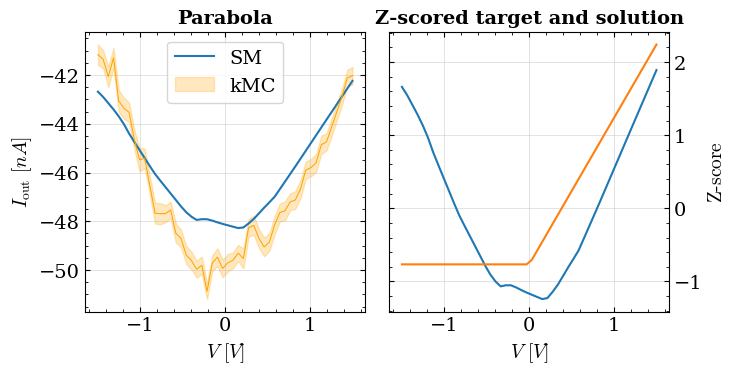

In [30]:
from models import CondSM
import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "legend.fontsize": 11,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})


e_0 = 1.60217663e-19
time_scale = 1e21
out_scale = e_0 * time_scale

model_types = ['uni_1e7', 'data_vMB_ring_1e7', 'grad_towards_1e7', 'grad_away_1e7']

data_type = 'data_vMB_ring_1e7'
state_dict = torch.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_recover/final_datasets/{data_type}/sm_{data_type}_baseline_0_epochs=1000_dp=0.1_bn=True_hd=90_ls=5_noise=True.pth', weights_only=False, map_location='cuda')

model = CondSM(state_dict['layer_dims'], state_dict['dropout'], state_dict['batch_norm'])
model.load_state_dict(state_dict['model_state_dict'])

seed = 42
func_type = 'Parabola'

if func_type == 'Parabola':
    def target_function(x):
        m = nn.ReLU()
        return m(x)
elif func_type == 'Sigmoid':
    def target_function(x):
        m = nn.Sigmoid()
        return m(4*x)
elif func_type == 'Parabola':
    def target_function(x):
        return x**2
elif func_type == 'Cubic':
    def target_function(x):
        return x**3
elif func_type == 'Sine':
    def target_function(x):
        return torch.sin(3*x)
elif func_type == 'Cosine':
    def target_function(x):
        return torch.cos(3*x)

def normalize_over_range(x):
    
    z = (x - x.mean()) / (x.std() + 1e-8) 
    
    return z

in_idx = 3

data_kmc = np.load(
    f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/1d_funcs_random/'
    f'random_func_type={func_type}_data_type={data_type}_maxl2=2.0_input_idx={in_idx}_seed={seed}.npz'
)

n = 50
true_output_idx = 0
true_input_idx = in_idx + 1
print(data_kmc.files)
print(data_kmc['control'])
controls = torch.from_numpy(np.delete(data_kmc['control'], [0, true_input_idx])).expand(n, -1)

c_left, c_right = controls[:, :in_idx], controls[:, in_idx:]
#control_indices = [c_idx for c_idx in range(8) if c_idx not in (true_input_idx, true_output_idx)]
#print(control_indices)
input_range = torch.linspace(-1.5, 1.5, n).unsqueeze(1)
input_tensor = torch.cat([c_left, input_range, c_right], axis=-1).float()
print(input_tensor[0, :])
model.eval()
with torch.no_grad():
    y_out = model(input_tensor).detach().cpu().squeeze()

#input_tensor = torch.zeros(n, 7)
#input_tensor[:, in_idx] = input_range
#print(input_tensor)
#for k, c_idx in enumerate(control_indices)
#    input_tensor[:, ]

I_out = data_kmc['current'] * time_scale
I_err = data_kmc['sem'] * time_scale


fig = plt.figure(figsize=(8, 4))

ax_1 = fig.add_axes([0.10, 0.18, 0.36, 0.70])
ax_2 = fig.add_axes([0.48, 0.18, 0.36, 0.70])

for a in (ax_1, ax_2):
    a.minorticks_on()
    a.tick_params(top=True, right=True, which='both')
    a.tick_params(direction='in', which='both')
    a.grid(which='major', alpha=.5, lw=.5)
    a.set_box_aspect(1)

ax_1.plot(input_range.squeeze(), y_out, label='SM')
ax_1.fill_between(input_range.squeeze(), I_out - I_err, I_out + I_err, alpha=.25, color='orange', label='kMC')
ax_1.plot(input_range.squeeze(), I_out, lw=0.75, color='orange')
ax_1.set_xlabel(r'$V \, \, [V]$')
ax_1.set_ylabel(r'$I_{\mathrm{out}} \, \, [nA]$')
ax_1.set_title(rf'{func_type}', fontdict={'weight': 'bold'})
ax_1.legend()

ax_2.tick_params(labelleft=False, labelright=True)
ax_2.yaxis.set_label_position('right')
ax_2.plot(input_range.squeeze(), normalize_over_range(y_out))
ax_2.plot(input_range.squeeze(), normalize_over_range(target_function(input_range.squeeze())))
ax_2.set_ylabel(r'$\text{Z-score}$')
ax_2.set_xlabel(r'$V \, \, [V]$')
ax_2.set_title(r'Z-scored target and solution', fontdict={'weight': 'bold'})

#fig.subplots_adjust(wspace=0.5)
fig.savefig(f'evaluation_random_data_type={data_type}_funct={func_type}_input_idx={in_idx}_maxl2=2.0_seed={seed}.pdf')
plt.show()

In [131]:
data_type = 'grad_away_1e7'
func_type = 'Cosine'
in_idx = 3
data = np.loadtxt(
    f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/1d_funcs_random/'
    f'random_data_type={data_type}_func={func_type}_cmin=-1.5_cmax=1.5_seed=42_maxl2=2.0_input_idx={in_idx}.txt'
)
print(data.tolist())

[-0.5512767434120178, 0.8997340202331543, 0.5740776062011719, -0.05313372611999512, -1.4928081035614014, -0.40772485733032227]


In [46]:
data_type = 'grad_away_1e7'
gate = 'NOR'
data = np.loadtxt(f'/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/{data_type}_gate_data/{data_type}_gate={gate}_params_seed=42_sigma_val=0.01_score=sigmamargin.txt')
print(data.tolist())

[1.460519790649414, -0.9568479061126709, -0.5035076141357422, -0.26229703426361084, 0.5541777610778809]


In [8]:
data = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/testing_current.npz')
print(float(data['current']) / 1.602e-19)

-0.03420455851071193


/tmp/ipykernel_2112529/4150874922.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(float(data['current']) / 1.602e-19)


max current: 0.28565861425131883
min current: -0.29472305788424186


(array([ 3.,  8., 19., 24., 18., 13.,  8.,  4.,  2.,  1.]),
 array([0.00012001, 0.00016955, 0.00021909, 0.00026863, 0.00031817,
        0.00036771, 0.00041725, 0.00046679, 0.00051633, 0.00056587,
        0.00061541]),
 <BarContainer object of 10 artists>)

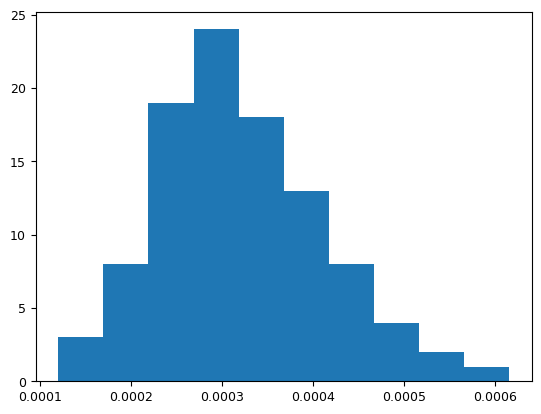

In [14]:
data = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/uni_1e6_with_sem_test_batch/batch_0.npz')

current = data['currents']
print(f'max current: {current.max()}')
print(f'min current: {current.min()}')
sem = data['sem']
fig, ax = plt.subplots(ncols=1)
ax.hist(sem)
#ax[1].hist(current)

['outputIdx', 'currents', 'inputs', 'sampleStd', 'sem', 'T', 'sigma', 'acc_xy', 'don_xy', 'ele_xy', 'jagged_lengths', 'neighbour_indices', 'init_energies', 'acc_don_int', 'acc_acc_int', 'rand_energies', 'rate_prefactors']
(2000,)


(array([ 53., 167., 234., 247., 359., 369., 206., 248.,  85.,  32.]),
 array([-0.22841634, -0.18363604, -0.13885574, -0.09407544, -0.04929514,
        -0.00451485,  0.04026545,  0.08504575,  0.12982605,  0.17460635,
         0.21938664]),
 <BarContainer object of 10 artists>)

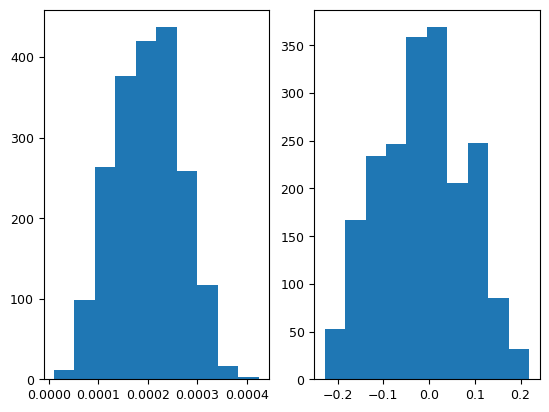

In [11]:
data = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/uni_a=5_ed=0.1_1e7/batch_0.npz')
print(data.files)
print(data['sem'].shape)

sem = data['sem']
currents = data['currents']

fig, ax = plt.subplots(ncols=2)
ax[0].hist(sem)
ax[1].hist(currents)

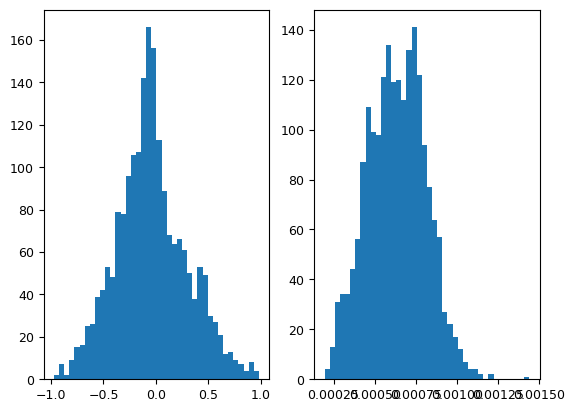

In [16]:
data = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/data_vMB_ring_1e7/batch_0.npz')
i_0 = data['currents']
v_0 = data['inputs']
sem_0 = data['sem']

fig, ax = plt.subplots(ncols=2)
ax[0].hist(i_0, bins=40)
ax[1].hist(sem_0, bins=40)
plt.show()

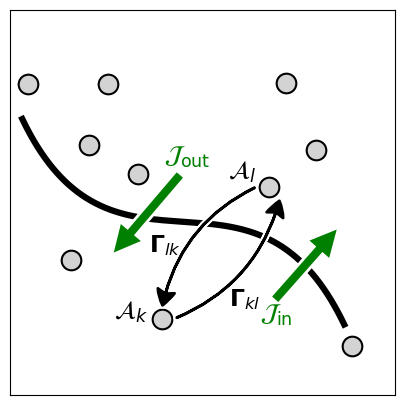

In [166]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(5,5))

np.random.seed(442)
X = np.array(
    [[0.39467617, 0.19820664],
     [0.25483107, 0.80854535],
     [0.79601517, 0.63636831],
     [0.88934441, 0.127539],
     [0.20436208, 0.65042541],
     [0.71658844, 0.80996585],
     [0.15956, 0.35146919],
     [0.3316606,  0.57526892],
     [0.67151264, 0.54134168],
     [0.04662263, 0.80876876]]
)
ax.text(x=0.5651264, y=0.56134168, s="$\mathcal{A}_l$", fontsize=18)
ax.text(x=0.27067617, y=0.19820664, s="$\mathcal{A}_k$", fontsize=18)
ax.scatter(*X.T, s=200, fc='lightgrey', ec='k', lw=1.5)

arrow_1 = FancyArrowPatch(
    posA=[0.64151264, 0.54134168], posB=[0.39467617, 0.225820664],
    arrowstyle="Fancy,head_length=0.6,head_width=0.7,tail_width=.01",        # nice arrow head
    mutation_scale=18,       # head size
    linewidth=2,
    color='k',
    connectionstyle="arc3,rad=0.25"  # curvature (+/- changes side)
)
arrow_1.set_path_effects([
    pe.Stroke(linewidth=5, foreground="white"),  # outline
    pe.Normal()
])

arrow_2 = FancyArrowPatch(
    posA=[0.4267617, 0.19820664], posB=[0.70151264, 0.51134168],
    arrowstyle="Fancy,head_length=.6,head_width=0.7,tail_width=.01",        # nice arrow head
    mutation_scale=18,       # head size
    linewidth=2,
    color='k',
    connectionstyle="arc3,rad=0.25"  # curvature (+/- changes side)
)
arrow_2.set_path_effects([
    pe.Stroke(linewidth=5, foreground="white"),  # outline
    pe.Normal()
])
ax.add_patch(arrow_1)
ax.add_patch(arrow_2)

t = np.linspace(0.1, 0.9, 1000)

P0 = np.array([0.0, 1.0])   # start: top-left
P3 = np.array([1.0, 0.0])   # end: bottom-right

# Make it "not monotonic" in y by putting one control point low, the next high
P1 = np.array([0.25, 0.05])  # early pull downward
P2 = np.array([0.75, 0.95])  # then pull upward

B = ((1-t)**3)[:,None]*P0 + (3*(1-t)**2*t)[:,None]*P1 + (3*(1-t)*t**2)[:,None]*P2 + (t**3)[:,None]*P3 - 0.05
ax.plot(B[:,0], B[:,1], lw=4.5, color="k", alpha=1, zorder=0)

ax.text(x=0.57, y=0.23, s="$\mathbf{\Gamma}_{kl}$", fontsize=17)
ax.text(x=0.36, y=0.37, s="$\mathbf{\Gamma}_{lk}$", fontsize=17)

arrow_3 = FancyArrowPatch(
    posA=[0.69, 0.25], posB=[0.84, 0.42],
    arrowstyle="Simple,head_length=0.6,head_width=0.6,tail_width=.05",        # nice arrow head
    mutation_scale=18,       # head size
    linewidth=5,
    color='green',
    joinstyle="miter",
    capstyle="butt",
    connectionstyle="arc3,rad=0.0"  # curvature (+/- changes side)
)

arrow_3.set_path_effects([
    pe.Stroke(linewidth=9, foreground="white"),  # outline
    pe.Normal()
])

ax.add_patch(arrow_3)

arrow_4 = FancyArrowPatch(
    posA=[0.44, 0.57], posB=[0.278, 0.38],
    arrowstyle="Simple,head_length=0.6,head_width=0.6,tail_width=.05",        # nice arrow head
    mutation_scale=18,       # head size
    linewidth=5,
    color='green',
    joinstyle="miter",
    capstyle="butt",
    connectionstyle="arc3,rad=0.0"  # curvature (+/- changes side)
)

arrow_4.set_path_effects([
    pe.Stroke(linewidth=9, foreground="white"),  # outline
    pe.Normal()
])

ax.add_patch(arrow_4)

ax.text(x=0.4, y=0.6, s="$\mathcal{J}_{\mathrm{out}}$", color="green",fontsize=18)
ax.text(x=0.65, y=0.19, s="$\mathcal{J}_{\mathrm{in}}$", color="green", fontsize=18)

ax.set_xlim(0,1); ax.set_ylim(0,1)
ax.set_aspect('equal', 'box')
ax.set_xticks([])
ax.set_yticks([])
plt.savefig("flux_calculation.pdf", bbox_inches='tight')
plt.show()

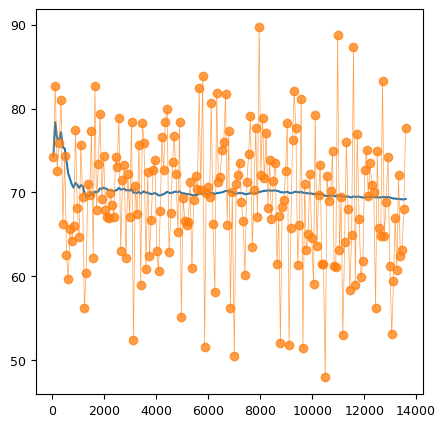

In [29]:
burnin_data = np.loadtxt('/home/hd/hd_hd/hd_gy283/kmc_project/burnin.txt', skiprows=1)
n_int = 200
t_s, t_e, t_mid, I = burnin_data[:n_int, 0], burnin_data[:n_int, 1], burnin_data[:n_int, 2], burnin_data[:n_int, 3]

e0 = 1.602176634e-19
I = I * e0 * 1e12 * 1e9

dt = t_e - t_s
tmid = 0.5*(t_s + t_e)

I_run = np.cumsum(I * dt) / np.cumsum(dt)   # time-weighted running mean

fig, ax = plt.subplots(figsize=(5,5))

ax.plot(tmid, I_run)
ax.plot(tmid, I, marker='o', alpha=.75, lw=0.5)

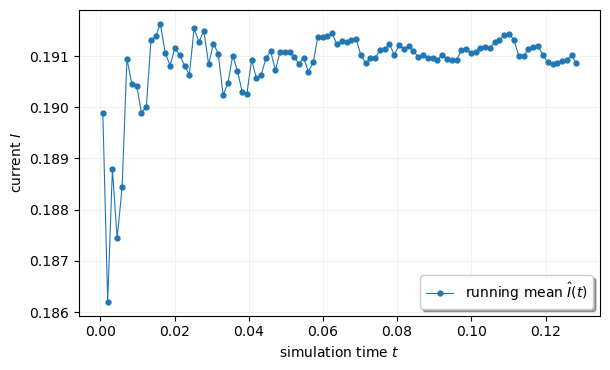

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# skip header row
data = np.loadtxt('/gpfs/bwfor/work/ws/hd_gy283-my_data/burnins_a=5/burn.txt', skiprows=1)
ts, te, tmid, I = data.T
ts = ts * 1e-6
te = te * 1e-6
tmid = tmid * 1e-6
dt = (te - ts)

# time-weighted running mean (correct for unequal dt)
I_run = np.cumsum(I * dt) / np.cumsum(dt)

fig, ax = plt.subplots(figsize=(6.2, 3.8))

# Option B: draw each bin as a horizontal segment
#ax.hlines(I, ts, te, linewidth=0.8, alpha=0.6, label="binned current $I_b$ (per interval)")

# Option A: also show midpoints as small markers (optional)
#ax.plot(tmid, I, marker='o', markersize=2.2, linewidth=0, alpha=0.8)

# running mean
ax.plot(tmid, I_run, linewidth=0.8, marker='o', markersize=3.5, label=r"running mean $\hat I(t)$")

ax.set_xlabel("simulation time $t$")
ax.set_ylabel("current $I$")
ax.legend(fancybox=True, frameon=True, shadow=True)
ax.grid(True, linewidth=0.4, alpha=0.3)
fig.tight_layout()
plt.show()


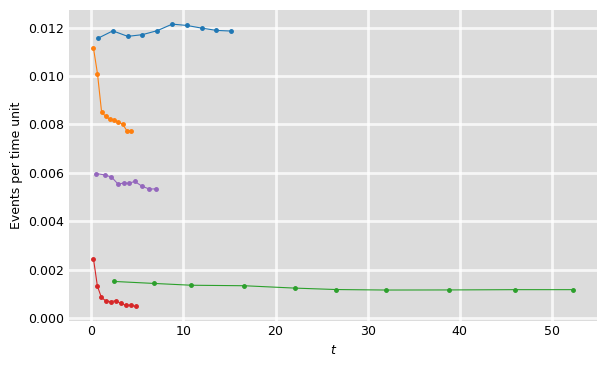

In [26]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6.2, 3.8))

e0 = 1.602176634e-19

for i in range(5):
    # skip header row
    data = np.loadtxt(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/burnins_ed=0.1_a=5_steps=10e7/burnin_{i}.txt', skiprows=1)
    ts, te, tmid, I = data.T[:, :10]
    dt = (te - ts)
    
    # time-weighted running mean (correct for unequal dt)
    I_run = np.cumsum(I * dt) / np.cumsum(dt)
    I_run = I_run * 1e12 * 1e9 * e0

    ts = ts * 1e-6
    te = te * 1e-6
    tmid = tmid * 1e-6
    
    # Option B: draw each bin as a horizontal segment
    #ax.hlines(I, ts, te, linewidth=0.8, alpha=0.6, label="binned current $I_b$ (per interval)")
    
    # Option A: also show midpoints as small markers (optional)
    #ax.plot(tmid, I, marker='o', markersize=2.2, linewidth=0, alpha=0.8)
    
    # running mean
    ax.plot(tmid, I_run, linewidth=0.8, marker='o', markersize=2.5, label=r"running mean $\hat I(t)$")

ax.spines[:].set_visible(False)
ax.set_xlabel("$t$")
ax.set_ylabel("Events per time unit")
#ax.legend(fancybox=True, frameon=True, shadow=True)
ax.set_facecolor('gainsboro')
ax.tick_params(length=0.0)
ax.grid(True, c='w', linewidth=2.0, alpha=0.75)
fig.tight_layout()
plt.show()

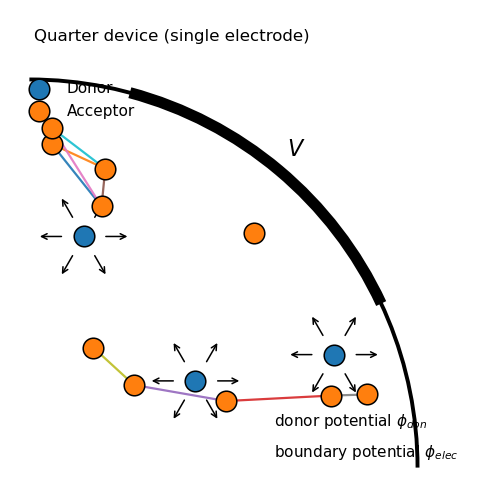

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc

# --- Quarter-device schematic with one electrode ---
R = 1.0
N_A, N_D = 10, 3
r_AA = 0.33
seed = 10

# One electrode segment on the outer boundary (angles in degrees, within 0..90)
elec_a1, elec_a2 = 25, 75
elec_label = r"$V$"

rng = np.random.default_rng(seed)

def sample_quarter_disk(n, radius=1.0):
    th = rng.uniform(0, np.pi/2, n)
    rr = radius * np.sqrt(rng.uniform(0, 1, n))
    return rr*np.cos(th), rr*np.sin(th)

# Positions in the quarter disk
xA, yA = sample_quarter_disk(N_A, R*0.92)
xD, yD = sample_quarter_disk(N_D, R*0.85)
A = np.column_stack([xA, yA])
D = np.column_stack([xD, yD])

fig, ax = plt.subplots(figsize=(6.2, 6.2))

# Quarter boundary: outer arc + radial edges
ax.add_patch(Arc((0, 0), 2*R, 2*R, theta1=0, theta2=90, lw=2.8))
#ax.plot([0, R], [0, 0], lw=2.8)  # x-edge
#ax.plot([0, 0], [0, R], lw=2.8)  # y-edge

# Electrode segment (thick arc)
ax.add_patch(Arc((0, 0), 2*R, 2*R, theta1=elec_a1, theta2=elec_a2, lw=8))
am = np.deg2rad((elec_a1 + elec_a2) / 2)
ax.text(1.07*R*np.cos(am), 1.07*R*np.sin(am), elec_label, ha="center", va="center", fontsize=16)
ax.text(0.05, 0.96, "Quarter device (single electrode)", transform=ax.transAxes,
        ha="left", va="top", fontsize=12)

# Donors + tiny "field arrows"
ax.scatter(xD, yD, s=220, edgecolors="k", linewidths=1.1, label="Donor", zorder=4)
for xd, yd in D:
    angles = np.linspace(0, 2*np.pi, 6, endpoint=False)
    for ang in angles:
        r0, r1 = 0.05, 0.12
        x0, y0 = xd + r0*np.cos(ang), yd + r0*np.sin(ang)
        x1, y1 = xd + r1*np.cos(ang), yd + r1*np.sin(ang)
        ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                    arrowprops=dict(arrowstyle="->", lw=1.1),
                    zorder=3)

# Acceptors
ax.scatter(xA, yA, s=220, edgecolors="k", linewidths=1.1, label="Acceptor", zorder=5)

# Acceptor–acceptor links (nearby pairs)
for i in range(N_A):
    for j in range(i + 1, N_A):
        if np.linalg.norm(A[i] - A[j]) <= r_AA:
            ax.plot([A[i, 0], A[j, 0]], [A[i, 1], A[j, 1]],
                    lw=1.6, alpha=0.9, zorder=2)

# Minimal labels
ax.text(0.63, 0.12, r"donor potential $\phi_{don}$", fontsize=11, ha="left", va="center")
ax.text(0.63, 0.04, r"boundary potential $\phi_{elec}$", fontsize=11, ha="left", va="center")

# Style
ax.set_aspect("equal", "box")
ax.set_xlim(-0.05, 1.18)
ax.set_ylim(-0.05, 1.18)
ax.axis("off")
ax.legend(loc="upper left", bbox_to_anchor=(0.0, 0.88), frameon=False, fontsize=11)

plt.show()


In [37]:
data = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_samples_1e6/batch_0.npz')
print(data.files)

total_states = 40000
n = data['adj_mat'].shape[0]
partners = []
for i in range(n):
    num_partners = float(data['adj_mat'][i].sum()) * 100.0 / total_states
    partners.append(num_partners)
print('DONE')

['currents', 'inputs', 'sampleStd', 'sem', 'acc_xy', 'don_xy', 'init_en', 'rand_en', 'acc_don', 'acc_acc', 'rate_pref', 'adj_mat']
DONE


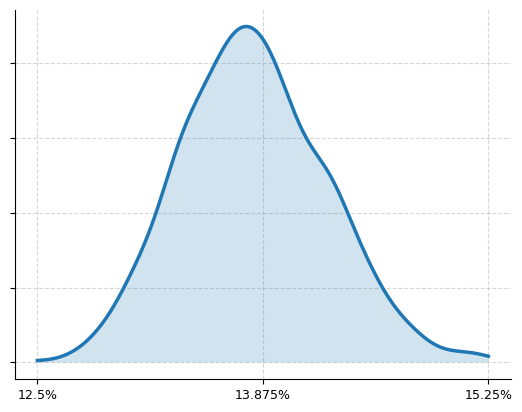

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

fig, ax = plt.subplots()

x = np.asarray(partners)
kde = gaussian_kde(x)
ticks = [x.min(), (x.max() + x.min()) / 2, x.max()]
tick_labels = [str(t) + '%' for t in ticks]
ax.set_xticks(ticks, tick_labels)
xs = np.linspace(x.min(), x.max(), 400)
ax.plot(xs, kde(xs), lw=2.5, zorder=5)
ax.fill_between(xs, kde(xs), alpha=0.2, zorder=5)
ax.tick_params(labelleft=None)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(alpha=.5, ls='dashed')
plt.show()


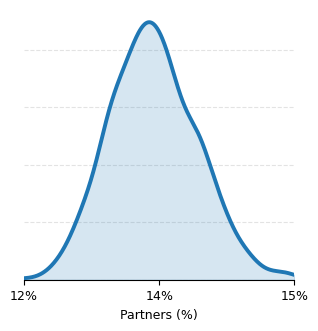

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Use your data
x = np.asarray(partners, dtype=float)

from scipy.stats import gaussian_kde
kde = gaussian_kde(x)
xs = np.linspace(x.min(), x.max(), 500)
ys = kde(xs)

fig, ax = plt.subplots(figsize=(7.2, 3.2), constrained_layout=True)

(line,) = ax.plot(xs, ys, lw=2.8, zorder=3)
ax.fill_between(xs, ys, alpha=0.18, zorder=2, color=line.get_color())

# Min / mid / max ticks with % labels
xmin, xmax = float(x.min()), float(x.max())
ticks = [xmin, 0.5 * (xmin + xmax), xmax]
ax.set_xticks(ticks, [f"{t:.0f}%" for t in ticks])

# Clean styling
ax.tick_params(axis="y", left=False, labelleft=False)
ax.grid(True, axis="y", linestyle="--", alpha=0.35)
ax.spines[["top", "right", "left"]].set_visible(False)

ax.margins(x=0.02)
ax.set_xlim(xmin, xmax)
ax.set_ylim(bottom=0)

ax.set_xlabel("Partners (%)")
ax.set_box_aspect(1)
#ax.set_title("Smoothed distribution (KDE)")
plt.savefig('partners.pdf', bbox_inches='tight')
plt.show()


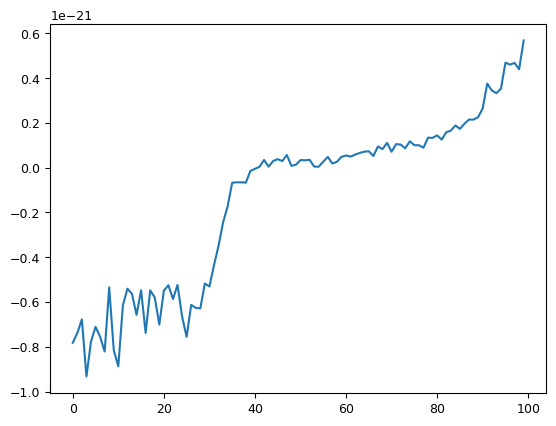

In [7]:
data = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/uni_1e7_a=5_test.npz')['current'] * 1e21 * 1.602e-19
plt.plot(data)

In [31]:
results = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/BO_gm_XOR/results.npy', allow_pickle=True)
print(results)

{'params': array([[-0.18879847,  1.30709823,  0.29443546,  0.3512414 , -0.46493531]]), 'targets': array([0.98491179])}


[array([-0.01730908]), array([-0.00163405]), array([0.00020422]), array([0.00090192])]


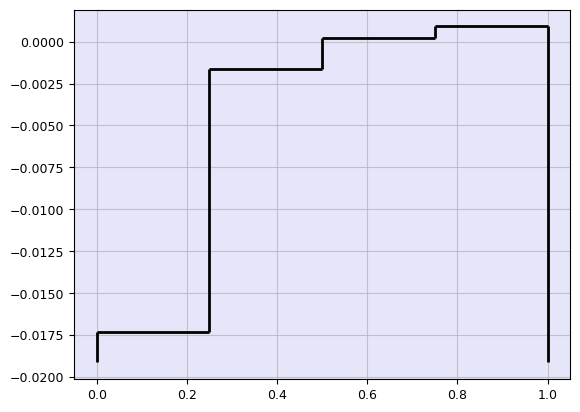

In [42]:
iteration = 37

"""I_00 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/BO_gm_XOR/iter_{iteration}/gate_a=0.0_b=0.0_iter={iteration}.npz')['current'] * 1e21
I_01 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/BO_gm_XOR/iter_{iteration}/gate_a=0.0_b=1.0_iter={iteration}.npz')['current'] * 1e21
I_10 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/BO_gm_XOR/iter_{iteration}/gate_a=1.0_b=0.0_iter={iteration}.npz')['current'] * 1e21
I_11 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/BO_gm_XOR/iter_{iteration}/gate_a=1.0_b=1.0_iter={iteration}.npz')['current'] * 1e21"""

C = 1.602e-19

I_00 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/gate=XOR_0.0_0.0.npz')['current'] / C
I_01 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/gate=XOR_0.0_1.0.npz')['current'] / C
I_10 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/gate=XOR_1.0_0.0.npz')['current'] / C
I_11 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/gate=XOR_1.0_1.0.npz')['current'] / C


vals = [I_00, I_01, I_10, I_11] 
print(vals)
max_val = max(vals)
min_val = min(vals)
max_margin = max_val - min_val
y_min = min_val - 0.10 * max_margin
fig, ax = plt.subplots()

l_w = 2.
plot_kwargs = {
    'lw': l_w,
    'color': 'k'
}
x = np.linspace(0, 1, len(vals) + 1)
ax.vlines(x=x[0], ymin=y_min, ymax=vals[0], **plot_kwargs)
ax.vlines(x=x[-1], ymin=y_min, ymax=vals[-1], **plot_kwargs)
for i in range(1, len(vals) + 1):
    ax.hlines(y=vals[i-1], xmin=x[i-1], xmax=x[i], **plot_kwargs)
for j in range(1, len(vals)):
    ax.vlines(x=x[j], ymin=vals[j-1], ymax=vals[j], **plot_kwargs)
ax.grid(alpha=.7)
ax.set_facecolor('lavender')

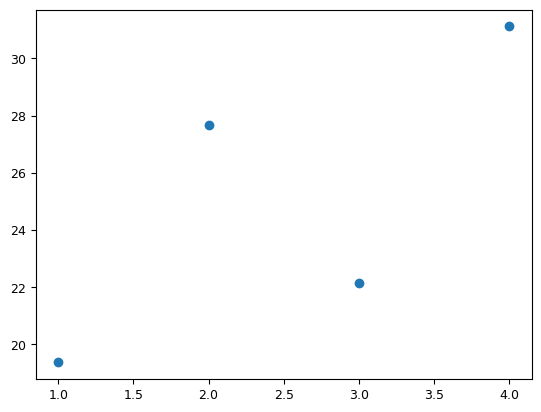

In [3]:
scale = 1e12*1e9
n = 3
current_0 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/BO_test/iter_{n}/gate_a=0.0_b=0.0_iter={n}.npz')['current'] * scale
current_1 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/BO_test/iter_{n}/gate_a=0.0_b=0.5_iter={n}.npz')['current'] * scale
current_2 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/BO_test/iter_{n}/gate_a=0.5_b=0.0_iter={n}.npz')['current'] * scale
current_3 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/BO_test/iter_{n}/gate_a=0.5_b=0.5_iter={n}.npz')['current'] * scale

Is = [current_0, current_1, current_2, current_3]

plt.scatter([1, 2, 3, 4], Is)

In [14]:
data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/BO_test/iter_{n}/gate_a=0.0_b=0.0_iter={n}.npz')
print(data['sim_time']*1e-12)

[4.03722989e-06]


In [2]:
data_dir = Path('/gpfs/bwfor/work/ws/hd_gy283-my_data/configs')
data_dir.mkdir(parents=True, exist_ok=True)
ang_a, ang_d, r_a, r_d = create_dopant_configuration(radius=150.0, n_a=200, n_d=3, name_a='uniform_acceptors_1', name_d='uniform_donors_1', mode='uniform', eps=None, save_dir=data_dir)

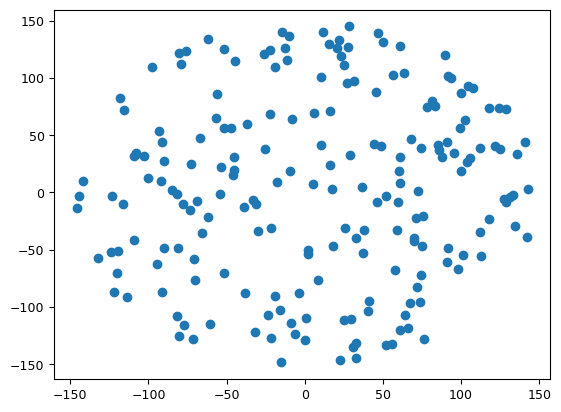

In [5]:
data = np.loadtxt(data_dir / 'uniform_acceptors_1.txt')
plt.scatter(*data.T)

NameError: name 'data' is not defined

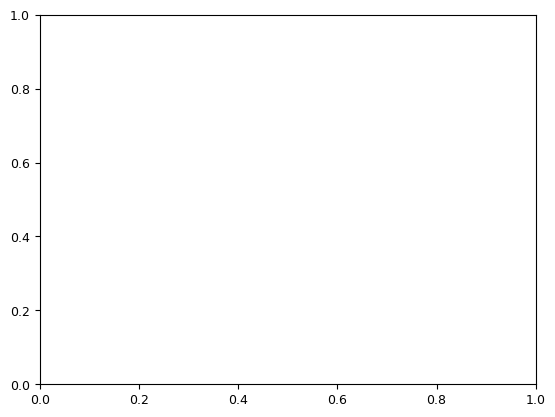

In [2]:
fig, ax = plt.subplots()

current_distribution(ax, add_cbar=True, device_data=data)

['out_idx', 'currents', 'inputs', 'sampleStd', 'sem', 'acc_xy', 'don_xy', 'init_en', 'rand_en', 'acc_don', 'acc_acc', 'rate_pref', 'adj_mat', 'variances', 'means', 'norm_weights']
1000
(1000, 200, 2)
(8, 3)
(8, 2)
(8,)
[[-1.45888133  1.44162064]
 [-3.32769156  4.17683369]
 [ 3.23911555 -3.64371024]
 [ 0.7874647  -1.28432639]
 [-5.32342657  1.538283  ]
 [ 1.16265537  5.24978564]
 [-0.04523161 -2.21041155]
 [ 0.84472837 -4.20499074]]
[0.05421463 0.26806208 0.02324715 0.16490194 0.0516256  0.1783556
 0.10211046 0.15748253]


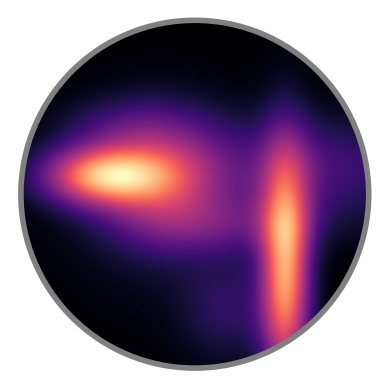

In [13]:
from scipy.stats import multivariate_normal

def sample(means,
           covs,
           weights,
           radius,
           N):
    
    positions = []
    cum_sum_weights = np.cumsum(weights)

    while len(positions) < N:

        u = np.random.uniform(0.0, 1.0) * cum_sum_weights[-1]
        component = np.searchsorted(cum_sum_weights, u)

        x = np.random.multivariate_normal(mean=means[component], cov=covs[component])

        if np.sqrt(x[0]**2 + x[1]**2) < radius:

            positions.append(x) 
    
    return np.vstack(positions)

def gaussian_mixture_pos(radius, n_a, n_comp, std_min, std_max):
    
    #log_bound_min = 2*np.log(std_min)
    #log_bound_max = 2*np.log(std_max)
    
    means = []
    covs = []
    weights = []
    
    raw_weights = []
    
    for comp in range(n_comp):
        u = np.random.random(size=(1,))
    
        r = 0.95 * radius * np.sqrt(u)
        theta = 2*np.pi*np.random.random((1,))
        means.append(np.array([r*np.cos(theta), r*np.sin(theta)]).squeeze(-1))
        #means.append(np.array([0.0, 0.0]))
        #covs.append(np.exp((log_bound_max - log_bound_min)*np.random.random_sample() + log_bound_min) * np.eye(2))
        sx = (std_max - std_min)*np.random.uniform(0, 1) + std_min
        sy = (std_max - std_min)*np.random.uniform(0, 1) + std_min
        var1 = sx*sx
        var2 = sy*sy
        covs.append(np.diag([var1, var2], k=0))
        raw_weight = np.random.random()
        raw_weights.append(raw_weight)
    
    raw_weight_sum = sum(raw_weights)
    weights = [rw / raw_weight_sum for rw in raw_weights]
    
    pos = sample(means, covs, weights, radius, n_a)

    out_dict = {
        'means': means,
        'covs': covs,
        'weights': weights,
        'positions': pos
    }
        
    return out_dict

data = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_gmm_params/batch_0.npz')
print(data.files)
n = data['currents'].shape[0]
print(n)
print(data['acc_xy'].shape)

#print(data['variances'].shape)
#print(data['means'].shape)

radius = 150.0
n_a = data['acc_xy'].shape[1]
idx = np.random.randint(0, 19)
R = np.sqrt(np.pi*radius**2 / n_a)

var = data['variances'][idx]
mean = data['means'][idx]
weights = data['norm_weights'][idx]

print(var.shape)
print(mean.shape)
print(weights.shape)

num_comps = var.shape[0]
mean_l = []
cov_l = []
weight_l = []
for i in range(num_comps):
    mean_l.append(mean[i])
    weight_l.append(weights[i])

    cov_l.append(np.array([
        [var[i][0], 0.0],
        [0.0, var[i][1]]
    ]))

acc = data['acc_xy'][idx]
x_acc, y_acc = acc.T

pad = 0.5  # or whatever
xmin, xmax = x_acc.min() - pad, x_acc.max() + pad
ymin, ymax = y_acc.min() - pad, y_acc.max() + pad

# Build grid

nx = ny = 200
disc_radius = radius / R
xx, yy = np.meshgrid(
    np.linspace(-disc_radius, disc_radius, nx),
    np.linspace(-disc_radius, disc_radius, ny)
)

# Stack into (ny, nx, 2) for pdf evaluation
grid = np.stack([xx, yy], axis=-1)

mask = (xx**2 + yy**2) <= (radius/R)**2

pdf = np.zeros(xx.shape)
for m, C, w in zip(mean_l, cov_l, weight_l):
    rv = multivariate_normal(mean=m, cov=C)
    pdf += w * rv.pdf(grid)

dx = (xmax - xmin) / (nx - 1)
dy = (ymax - ymin) / (ny - 1)
pdf_disc_unnorm = np.where(mask, pdf, 0.0)
Z = pdf_disc_unnorm.sum() * dx * dy
pdf_disc = pdf_disc_unnorm / Z

pdf_disc = np.where(mask, pdf_disc, np.nan)

fig, ax = plt.subplots()

im = ax.imshow(
    pdf_disc.T,
    origin='lower',
    extent=[-disc_radius, disc_radius, -disc_radius, disc_radius],
    cmap='magma'
)
#fig.colorbar(im, ax=ax, label='Mixture PDF')

#ax.scatter(x_acc, y_acc, s=10, alpha=.7)
ax.add_patch(ps.Circle(xy=(0,0), radius=radius / R, fill=None, lw=4., color='gray', zorder=6))

ax.set_xlim(-disc_radius-pad, disc_radius+pad)
ax.set_ylim(-disc_radius-pad, disc_radius+pad)
ax.spines[:].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

mean_vals = np.array(mean_l)
weight_vals = np.array(weight_l)
print(mean_vals)
print(weight_vals)
#for i in range(len(mean_l)):
#    ax.scatter(mean_vals[i][0], mean_vals[i][1], s=weight_vals[i]*200, marker='x', c='r')

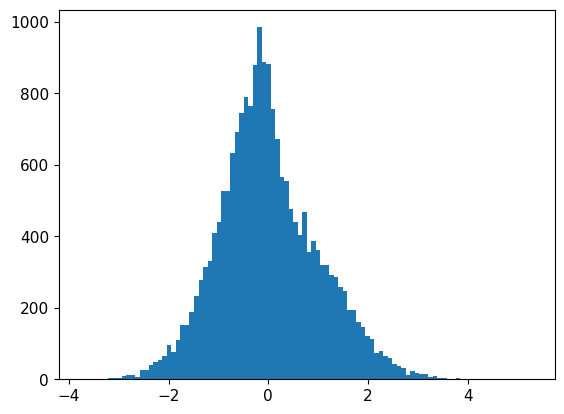

In [14]:
n = 20
Xl = []
posl = []
Il = []
col = 0
I_col = 0
for i in range(n):
    data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_samples_1e6/batch_{i}.npz')
    Xl.append(data['inputs'][:, col])
    posl.append(data['acc_xy'])
    Il.append(data['currents'][:, I_col])
Xa = np.concatenate(Xl, axis=0)
posa = np.concatenate(posl, axis=0)
Ia = np.concatenate(Il, axis=0)

Ia = (Ia - Ia.mean()) / Ia.std()

plt.hist(Ia, bins=100)
#plt.hist(Xa, bins=50)
#plt.scatter(*posa[:20].T)
plt.show()

[]

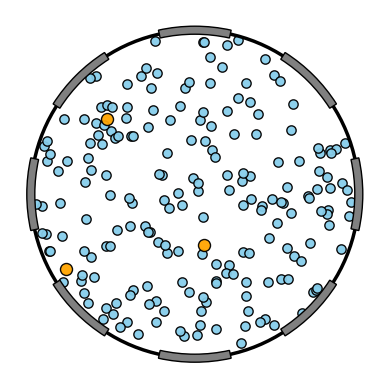

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as ps
data = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_samples_1e6/batch_0.npz')
R = np.sqrt(np.pi * 150**2 / 200)
radius = 150 / R
fig, ax = plt.subplots()

n_E = 8
arcs = []
th = np.linspace(0.0, 315, n_E)
th_width = 12.5
for i in range(n_E):
    """arcs.append(
        ps.Arc(
            xy=(0.0, 0.0),
            width=2*radius + 0.40,
            height=2*radius + 0.40,
            linewidth=8,
            color=colors[i + n_A],
            theta1=th[i]-th_width,
            theta2=th[i]+th_width,
            zorder=5
        )
    )"""
    arcs.append(
        ps.Wedge(
            center=(0, 0),
            r=radius + .4,
            fc='gray',
            ec='k',
            theta1=th[i]-th_width,
            theta2=th[i]+th_width,
            width = 0.4,
            zorder=6
        )
    )
    
for arc in arcs:
    ax.add_patch(arc)

idx = np.random.randint(0, 1000)
ax.scatter(*data['acc_xy'][idx].T, s=45, fc='skyblue', ec='k', alpha=.95)
ax.scatter(*data['don_xy'][idx].T, s=75, fc='orange', ec='k', alpha=.95)
ax.add_patch(ps.Circle(xy=(0,0), radius=150 / R + 0.2, fill=None, lw=2.5, color='k', zorder=4))
ax.set_box_aspect(1)
ax.spines[:].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])
plt.savefig('exemplary_device.pdf', bbox_inches='tight')

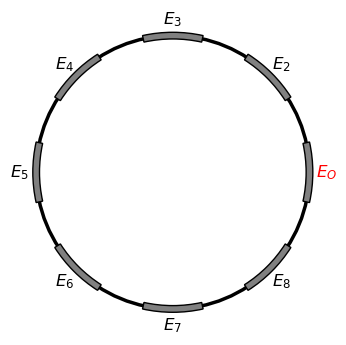

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as ps

data = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_samples_1e6/batch_0.npz')

R = np.sqrt(np.pi * 150**2 / 200)
radius = 150 / R

fig, ax = plt.subplots(figsize=(4,4))

n_E = 8
arcs = []
th = np.linspace(0.0, 315, n_E)   # centers: 0,45,...,315
th_width = 12.5

for i in range(n_E):
    wedge = ps.Wedge(
        center=(0, 0),
        r=radius + .4,
        fc='gray',
        ec='k',
        theta1=th[i]-th_width,
        theta2=th[i]+th_width,
        width=0.4,
        zorder=6
    )
    arcs.append(wedge)
    ax.add_patch(wedge)

    # --- annotation (label 1 starts at angle 0° = right) ---
    ang = np.deg2rad(th[i])          # mid-angle of wedge
    r_mid = radius + 1.2      # midway between inner (radius) and outer (radius+0.4)
    x, y = r_mid*np.cos(ang), r_mid*np.sin(ang)
    if i==0:
        ax.text(x, y, rf"$E_O$", ha="center", va="center", color='r', fontsize=12, zorder=7, fontweight='bold')
    else:
        ax.text(x, y, rf"$E_{i+1}$", ha="center", va="center", fontsize=12, zorder=7, fontweight='bold')

idx = np.random.randint(0, 1000)
ax.scatter(*data['acc_xy'][idx].T, s=45, fc='w', ec='w', alpha=.95)
ax.scatter(*data['don_xy'][idx].T, s=75, fc='w', ec='w', alpha=.95)

ax.add_patch(ps.Circle(xy=(0,0), radius=150 / R + 0.2, fill=None, lw=2.5, color='k', zorder=4))

ax.set_box_aspect(1)
ax.spines[:].set_visible(False)
ax.set_xticks([])
ax.set_yticks([])

plt.savefig('electrode_configuration.pdf', bbox_inches='tight')


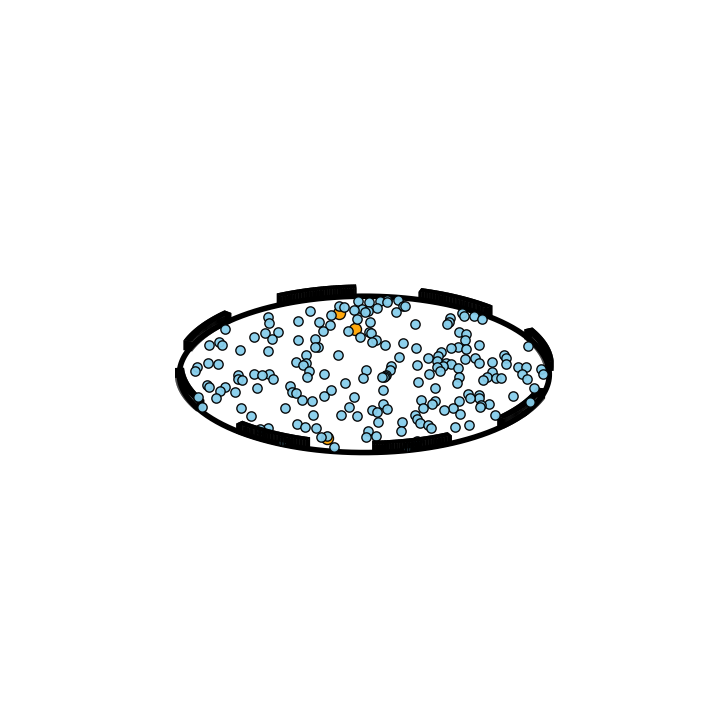

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# -----------------------------
# Load data + scale (your code)
# -----------------------------
data = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_samples_1e6/batch_0.npz')
R = np.sqrt(np.pi * 150**2 / 200)
radius = 150 / R

# -----------------------------
# Helper: extruded wedge (ring segment) as a 3D prism
# -----------------------------
def wedge_prism_faces(center, r_inner, r_outer, theta1_deg, theta2_deg, z0=0.0, z1=0.2, n=40):
    """
    Build faces for an extruded ring-segment wedge between angles [theta1, theta2]
    and radii [r_inner, r_outer], extruded from z0 to z1.
    Returns list of faces; each face is a list of (x,y,z) vertices.
    """
    cx, cy = center
    t1 = np.deg2rad(theta1_deg)
    t2 = np.deg2rad(theta2_deg)
    ts = np.linspace(t1, t2, n)

    # Top and bottom rings (outer/inner)
    outer_xy = np.column_stack([cx + r_outer*np.cos(ts), cy + r_outer*np.sin(ts)])
    inner_xy = np.column_stack([cx + r_inner*np.cos(ts[::-1]), cy + r_inner*np.sin(ts[::-1])])  # reverse for proper loop

    # Top face (z=z1) and bottom face (z=z0)
    top = [(x, y, z1) for x, y in np.vstack([outer_xy, inner_xy])]
    bot = [(x, y, z0) for x, y in np.vstack([outer_xy, inner_xy])]

    faces = []
    faces.append(top)

    # Vertical outer wall
    for k in range(len(ts)-1):
        x1, y1 = outer_xy[k]
        x2, y2 = outer_xy[k+1]
        faces.append([(x1, y1, z0), (x2, y2, z0), (x2, y2, z1), (x1, y1, z1)])

    # Vertical inner wall
    inner_xy_fwd = np.column_stack([cx + r_inner*np.cos(ts), cy + r_inner*np.sin(ts)])
    for k in range(len(ts)-1):
        x1, y1 = inner_xy_fwd[k]
        x2, y2 = inner_xy_fwd[k+1]
        faces.append([(x1, y1, z0), (x2, y2, z0), (x2, y2, z1), (x1, y1, z1)])

    # Radial side at theta1
    x1o, y1o = cx + r_outer*np.cos(t1), cy + r_outer*np.sin(t1)
    x1i, y1i = cx + r_inner*np.cos(t1), cy + r_inner*np.sin(t1)
    faces.append([(x1i, y1i, z0), (x1o, y1o, z0), (x1o, y1o, z1), (x1i, y1i, z1)])

    # Radial side at theta2
    x2o, y2o = cx + r_outer*np.cos(t2), cy + r_outer*np.sin(t2)
    x2i, y2i = cx + r_inner*np.cos(t2), cy + r_inner*np.sin(t2)
    faces.append([(x2o, y2o, z0), (x2i, y2i, z0), (x2i, y2i, z1), (x2o, y2o, z1)])

    return faces

# -----------------------------
# Plot (3D, with base plane figure)
# -----------------------------
fig = plt.figure(figsize=(7.2, 7.2))
ax = fig.add_subplot(111, projection='3d')

# Make it feel less "packed"
ax.set_proj_type('ortho')      # removes perspective squish
pad = 3.0                      # whitespace around disk
ax.set_xlim(-(radius + pad), (radius + pad))
ax.set_ylim(-(radius + pad), (radius + pad))
ax.set_zlim(-0.5, 2.0)

# Flatter Z so it reads as "base plane"
ax.set_box_aspect((1, 1, 0.22))
ax.view_init(elev=25, azim=-60)

# -----------------------------
# Electrode wedges (extruded)
# -----------------------------
n_E = 8
th = np.linspace(0.0, 315, n_E)
th_width = 12.5

r_outer = radius + 0.4
w = 0.4
r_inner = r_outer - w

electrode_height = 0.25     # <-- "stick out" amount
arc_resolution = 50         # smoothness

for i in range(n_E):
    theta1 = th[i] - th_width
    theta2 = th[i] + th_width

    faces = wedge_prism_faces(
        center=(0.0, 0.0),
        r_inner=r_inner,
        r_outer=r_outer,
        theta1_deg=theta1,
        theta2_deg=theta2,
        z0=0.0,
        z1=electrode_height,
        n=arc_resolution
    )
    poly = Poly3DCollection(
        faces,
        facecolors='k',
        linewidths=0.3,
        alpha=1.0
    )
    ax.add_collection3d(poly)

# -----------------------------
# Atoms on the base plane (z=0)
# -----------------------------
idx = np.random.randint(0, 1000)

acc = data['acc_xy'][idx]  # (N,2)
don = data['don_xy'][idx]  # (M,2)

ax.scatter(acc[:, 0], acc[:, 1], np.zeros(len(acc)),
           s=45, c='skyblue', edgecolors='k', alpha=.95, depthshade=False)

ax.scatter(don[:, 0], don[:, 1], np.zeros(len(don)),
           s=75, c='orange', edgecolors='k', alpha=.95, depthshade=False)

# -----------------------------
# Boundary circle (as a 3D line at z=0)
# -----------------------------
t = np.linspace(0, 2*np.pi, 400)
rb = radius + 0.2
ax.plot(rb*np.cos(t), rb*np.sin(t), np.zeros_like(t), color='k', lw=4)

# -----------------------------
# Clean look (no axes)
# -----------------------------
ax.set_axis_off()
plt.tight_layout()
plt.show()


In [1]:
import matplotlib.pyplot as plt
import numpy as np

latex_txt_width = 404.02908 # in pt
in_per_pt = 1 / 72.27
width_in_pt = latex_txt_width * in_per_pt
height_in_pt = 0.618 * width_in_pt

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 12,          # base font (affects cbar label unless overridden)
    "xtick.labelsize": 12,    # affects horizontal colorbar ticks
    "ytick.labelsize": 12,    # affects vertical colorbar ticks
    # Optional extras you may want:
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

num_geom = 20
electrode_pairs = [
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 6],
    [6, 7],
    [7, 0]
]

current_list_0 = []
for j in electrode_pairs:
    input_idx, output_idx = j[1], j[0]
    for k in range(num_geom):
        data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/iv_exp_from_paper/en_dis=0.01/sim_input_idx={input_idx}_output_idx={output_idx}_geom={k}_en_dis=0.01.npz')
        current_list_0.append(data['current'])

currents_0 = np.stack(current_list_0) * 1e12 * 1e9
average_current_0 = currents_0.mean(axis=0)
std_current_0 = currents_0.std(axis=0)

p_50_0 = np.percentile(currents_0, 50, axis=0)

current_list_1 = []
for j in electrode_pairs:
    input_idx, output_idx = j[1], j[0]
    for k in range(num_geom):
        data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/iv_exp_from_paper/en_dis=0.1/sim_input_idx={input_idx}_output_idx={output_idx}_geom={k}_en_dis=0.1.npz')
        current_list_1.append(data['current'])

currents_1 = np.stack(current_list_1) * 1e12 * 1e9
average_current_1 = currents_1.mean(axis=0)
std_current_1 = currents_1.std(axis=0)

p_50_1= np.percentile(currents_1, 50, axis=0)

current_list_2 = []
for j in electrode_pairs:
    input_idx, output_idx = j[1], j[0]
    for k in range(num_geom):
        data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/iv_exp_from_paper/en_dis=0.05/sim_input_idx={input_idx}_output_idx={output_idx}_geom={k}_en_dis=0.05.npz')
        current_list_2.append(data['current'])

currents_2 = np.stack(current_list_2) * 1e12 * 1e9
average_current_2 = currents_2.mean(axis=0)
std_current_2 = currents_2.std(axis=0)

p_50_2 = np.percentile(currents_2, 50, axis=0)

current_list_3 = []
for j in electrode_pairs:
    input_idx, output_idx = j[1], j[0]
    for k in range(num_geom):
        data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/iv_exp_from_paper/en_dis=0.0/sim_input_idx={input_idx}_output_idx={output_idx}_geom={k}_en_dis=0.0.npz')
        current_list_3.append(data['current'])

currents_3 = np.stack(current_list_3) * 1e12 * 1e9
average_current_3 = currents_3.mean(axis=0)
std_current_3 = currents_3.std(axis=0)

p_50_3 = np.percentile(currents_3, 50, axis=0)

current_list_wit_T = []
for j in electrode_pairs:
    input_idx, output_idx = j[1], j[0]
    for k in range(num_geom):
        data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/iv_from_paper_with_T/en_dis=0.0/sim_input_idx={input_idx}_output_idx={output_idx}_geom={k}_en_dis=0.0.npz')
        current_list_wit_T.append(data['current'])

currents_with_T = np.stack(current_list_wit_T) * 1e12 * 1e9
average_current_with_T = currents_with_T.mean(axis=0)
std_current_with_T = currents_with_T.std(axis=0)

p_50_T = np.percentile(currents_with_T, 50, axis=0)

/tmp/ipykernel_278095/3581810260.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[1].legend()


"fig, axs = plt.subplot_mosaic(mosaic=mosaic_layout, figsize=(12,6), layout='constrained')\n\nfor ax in axs.values():\n    ax.spines[:].set_linewidth(1.5)\n\naxs['B'].set_aspect('equal')\naxs['C'].set_aspect('equal')\n\naxs['A'].grid(ls='--', c='w')\naxs['A'].tick_params(direction='in')\naxs['A'].set_facecolor('lavender')\n\naxs['A'].set_xlabel(r'$V_{\\mathrm{in}}$ $[ V ]$')\naxs['A'].set_ylabel(r'$I_{\\mathrm{out}}$ $[ \nu_0 e_0 ]$')\n\naxs['A'].fill_between(v, average_current_0-p_50_0, average_current_0+p_50_0, alpha=0.4, zorder=5)\naxs['A'].fill_between(v, average_current_1-p_50_1, average_current_1+p_50_2, alpha=0.4, zorder=5)\naxs['A'].fill_between(v, average_current_2-p_50_2, average_current_2+p_50_2, alpha=0.4, zorder=5)\n\naxs['A'].plot(v, average_current_0)\naxs['A'].plot(v, average_current_1)\naxs['A'].plot(v, average_current_2)"

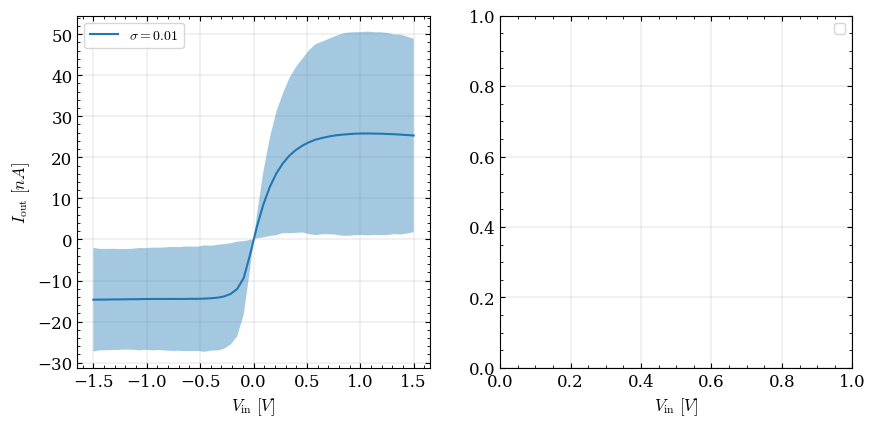

In [3]:
v = np.linspace(-1.5, 1.5, average_current_0.shape[0])

#fig, ax = plt.subplots(figsize=(width_in_pt, height_in_pt), ncols=2, constrained_layout=True)
fig, ax = plt.subplots(figsize=(10, 10), ncols=2)
for a in ax:
    a.set_box_aspect(1)
    a.minorticks_on()
    a.tick_params(direction='in', which='both')
    a.tick_params(which='both', top=True, right=True)
    #a.grid(c='gray', which='minor', alpha=.5, ls='--')
    a.grid(c='gray', which='major', alpha=.5, lw=0.3, zorder=-1)

ax[0].set_xlabel(r'$V_{\mathrm{in}} \, \,[ V ]$')
ax[0].set_ylabel(r'$I_{\mathrm{out}} \, \, [ nA ]$')

ax[0].fill_between(v, average_current_0-p_50_0, average_current_0+p_50_0, alpha=0.4, zorder=5)
ax[0].plot(v, average_current_0, label=rf'$\sigma = 0.01$')

#ax[0].fill_between(v, average_current_1-p_50_1, average_current_1+p_50_1, alpha=0.4, zorder=5)
#ax[0].plot(v, average_current_1, label=rf'$\sigma = 0.1$')

#ax[0].fill_between(v, average_current_2-p_50_2, average_current_2+p_50_2, alpha=0.4, zorder=5)
#ax[0].plot(v, average_current_2, label=rf'$\sigma = 0.05$')

#ax[1].fill_between(np.linspace(-1.5, 1.5, 50), average_current_3-p_50_3, average_current_3+p_50_3, alpha=0.4, zorder=5)
#ax[1].plot(np.linspace(-1.5, 1.5, 50), average_current_3, label=rf'$T = 77 \, \, [K]$')

#ax[1].fill_between(np.linspace(-1.5, 1.5, 50), average_current_with_T-p_50_T, average_current_with_T+p_50_T, alpha=0.4, zorder=5)
#ax[1].plot(np.linspace(-1.5, 1.5, 50), average_current_with_T, label=rf'$T = 300 \, [K]$')

ax[1].set_xlabel(r'$V_{\mathrm{in}} \, \,[ V ]$')

ax[0].legend()
ax[1].legend()

#fig.subplots_adjust(top=0.7, bottom=0.12, left=0.12, right=0.98)
plt.savefig(f'iv_curves.pdf', bbox_inches='tight', pad_inches=0.2)

mosaic_layout = [
    ['A', 'B'],
    ['A', 'C']    
]

"""fig, axs = plt.subplot_mosaic(mosaic=mosaic_layout, figsize=(12,6), layout='constrained')

for ax in axs.values():
    ax.spines[:].set_linewidth(1.5)

axs['B'].set_aspect('equal')
axs['C'].set_aspect('equal')

axs['A'].grid(ls='--', c='w')
axs['A'].tick_params(direction='in')
axs['A'].set_facecolor('lavender')

axs['A'].set_xlabel(r'$V_{\mathrm{in}}$ $[ V ]$')
axs['A'].set_ylabel(r'$I_{\mathrm{out}}$ $[ \nu_0 e_0 ]$')

axs['A'].fill_between(v, average_current_0-p_50_0, average_current_0+p_50_0, alpha=0.4, zorder=5)
axs['A'].fill_between(v, average_current_1-p_50_1, average_current_1+p_50_2, alpha=0.4, zorder=5)
axs['A'].fill_between(v, average_current_2-p_50_2, average_current_2+p_50_2, alpha=0.4, zorder=5)

axs['A'].plot(v, average_current_0)
axs['A'].plot(v, average_current_1)
axs['A'].plot(v, average_current_2)"""

In [5]:
data = np.load('/gpfs/bwfor/work/ws/hd_gy283-my_data_new/logic_gates_data/grad_towards_1e7_gate_data/grad_towards_1e7_gate=AND_0.0_0.0.npz')
print(data['inputs'])

[ 0.         -0.39848936 -0.26099992  0.         -1.02215219  0.
 -0.24687934  1.05411577]


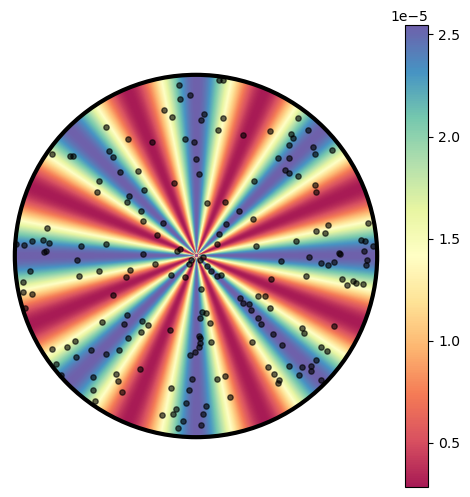

In [4]:
import matplotlib.pyplot as plt
import numpy as np

def sample_anisotropic(N, R=150.0, m=3, a=0.6, phi=0.0, seed=None):
    """
    Sample N dopants in a disk of radius R with m-fold angular anisotropy.
    a in [0,1): 0=uniform, ->1 strong anisotropy. phi rotates the pattern.
    """
    rng = np.random.default_rng(seed)
    pts = []
    # accept–reject on theta with weight w = 1 + a*cos(m*(theta - phi))
    while len(pts) < N:
        # uniform-in-disk radius
        r = R * np.sqrt(rng.random())
        theta = rng.random() * 2*np.pi
        w = 1 + a*np.cos(m*(theta - phi))
        if rng.random() < w/(1+a):         # normalized acceptance
            pts.append((r*np.cos(theta), r*np.sin(theta)))
    return np.array(pts)

def anisotropic_pdf(R, m, a, phi_deg, n=400):

    phi = np.deg2rad(phi_deg)   

    x = np.linspace(-R, R, n)
    y = np.linspace(-R, R, n)
    xx, yy = np.meshgrid(x, y)

    rr = np.hypot(xx, yy)
    theta = np.arctan2(yy, xx)

    f = (1 + a*np.cos(m*(theta - phi))) / (np.pi * R**2)
    f = np.where(rr <= R, f, np.nan)

    return f
phi_deg = 0
a = 0.8
m = 8
f = anisotropic_pdf(R=150, m=m, a=a, phi_deg=phi_deg)

sample = sample_anisotropic(N=200, m=m, a=a, phi=np.deg2rad(phi_deg))
np.savetxt("/home/hd/hd_hd/hd_gy283/kmc_project/configs/radial_distribution.txt", sample, fmt="%.6f", delimiter="\t")
R = 150
fig, ax = plt.subplots(figsize=(6,6))

ax.set_aspect("equal", adjustable="box")
im = ax.imshow(f, extent=(-R, R, -R, R), origin="lower", cmap="Spectral", alpha=0.9)
ax.scatter(*sample.T, s=14.5, color="k", alpha=0.6, zorder=3)
ax.add_patch(ps.Circle(xy=(0,0), radius=R, fill=None, linewidth=3, zorder=4))

ax.spines[:].set_visible(False)
pad = 4
ax.set_xlim(-R-pad, R+pad)
ax.set_ylim(-R-pad, R+pad)
ax.set_xticks([])
ax.set_yticks([])

fig.colorbar(im)

In [11]:
angles_acc, angles_don, r_acc, r_don = create_dopant_configuration(150.0, 200, 3, f"acceptors_1", f"donors_1", 'uniform', 0.0, '/home/hd/hd_hd/hd_gy283/kmc_project/configs/std_configs/')

['current', 'currentStd', 'sem', 'control', 'inputIdx', 'outputIdx']
(100,)


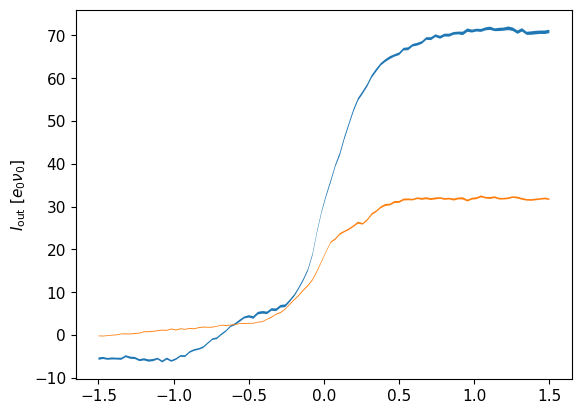

In [11]:
def scale_to_current(raw_current, scale):

    I_nA = raw_current * scale

    return I_nA

data_0 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/relu/sim_1.npz")
data_1 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/relu/sim_3.npz")
print(data_0.files)
print(data_0['current'].shape)

scale = 1e9 * 1e12
I_nA_0 = scale_to_current(data_0['current'], scale)
I_nA_1 = scale_to_current(data_1['current'], scale)

V = np.linspace(-1.5, 1.5, 100)
plt.fill_between(V, I_nA_0-data_0['sem']*scale, I_nA_0+data_0['sem']*scale)
plt.fill_between(V, I_nA_1-data_1['sem']*scale, I_nA_1+data_1['sem']*scale)
plt.ylabel(r"$I_{\mathrm{out}}$ $[e_0 \nu_0]$")
plt.show()

['currents', 'inputs', 'sampleStd', 'sem', 'acc_xy', 'don_xy', 'init_en', 'rand_en', 'acc_don', 'acc_acc', 'rate_pref', 'adj_mat']
(1000, 8)


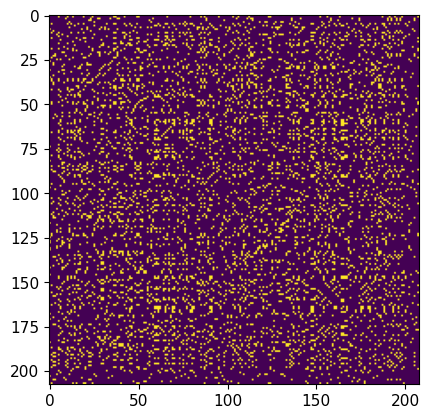

In [10]:
batch = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_samples_1e6/batch_0.npz')
print(batch.files)
idx = 123
print(batch['currents'].shape)
#print(batch['sem'][idx])
#print(batch['adj_mat'][idx].sum())
plt.imshow(batch['adj_mat'][idx])

#plt.scatter(*batch['acc_xy'][idx].T)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as ps
from visualize_hops import visualize_current, current_snapshot
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from mpl_toolkits.axes_grid1 import make_axes_locatable

device = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/device_sanpshots/device_4.npz")
print(device.files)

div_cmap = LinearSegmentedColormap.from_list('div_cmap', (
    # Edit this gradient at https://eltos.github.io/gradient/#0032F5-FF00ED-FF0202-FFF900-00FF03
    (0.000, (0.000, 0.196, 0.961)),
    (0.250, (1.000, 0.000, 0.929)),
    (0.500, (1.000, 0.008, 0.008)),
    (0.750, (1.000, 0.976, 0.000)),
    (1.000, (0.000, 1.000, 0.012))))

def triangle_from_src_to_dst(src, dst, base_width):
    """
    Return the 3 vertices of an isosceles triangle whose base is centered at src
    (length = base_width) and whose tip is at dst.
    """
    v = dst - src
    L = np.linalg.norm(v)
    if L == 0:
        return None  # same point, nothing to draw
    u = v / L                        # direction from src to dst
    n = np.array([-u[1], u[0]])      # unit normal (perpendicular)
    half = 0.5 * base_width

    p_left  = src + half * n
    p_right = src - half * n
    tip     = dst
    return np.vstack([p_left, p_right, tip])

def current_distribution(device_data):
    
    """ Load data"""
    events = device_data['event_matrix']
    simulation_time = device_data['sim_time']
    acc_xy = device_data['acc_xy']
    don_xy = device_data['don_xy']
    ele_xy = device_data['ele_xy']
    energies = device_data['energies']

    n_A = acc_xy.shape[0]
    n_E = ele_xy.shape[0]

    net_events = (events - events.T)
    dir_rows, dir_cols = np.where(net_events > 0)
    #lower_half_currents = np.abs(np.tril(net_events, k=-1))
    abs_current = np.abs(net_events) / simulation_time

    min_current = abs_current.min()
    max_current = abs_current.max()
    #print(min_current)
    #print(max_current)
    #print(events.sum())

    abs_current_normalized = abs_current / max_current

    acc_face_clr = (0, 0.6, 0, 1)

    """ Energies to color """
    cmap = plt.get_cmap('magma')
    norm = plt.Normalize(vmin=energies.min(), vmax=energies.max())
    colors = cmap(norm(energies))

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.set_aspect('equal', adjustable='box')

    """ Device boundary """
    radius = float(np.max(np.linalg.norm(acc_xy, axis=1)))
    device_boundary = ps.Circle(
        xy=(0.0, 0.0),
        radius=radius+0.15,
        fill=None,
        edgecolor='gray',
        zorder=4,
        lw=4
    )
    ax.add_patch(device_boundary)

    """ Electrodes """
    arcs = []
    th = np.linspace(0.0, 315, n_E)
    th_width = 12.5
    for i in range(n_E):
        """arcs.append(
            ps.Arc(
                xy=(0.0, 0.0),
                width=2*radius + 0.40,
                height=2*radius + 0.40,
                linewidth=8,
                color=colors[i + n_A],
                theta1=th[i]-th_width,
                theta2=th[i]+th_width,
                zorder=5
            )
        )"""
        arcs.append(
            ps.Wedge(
                center=(0, 0),
                r=radius + .5,
                fc=colors[i+n_A],
                ec='k',
                theta1=th[i]-th_width,
                theta2=th[i]+th_width,
                width = 0.7,
                zorder=5
            )
        )
        
    for arc in arcs:
        ax.add_patch(arc)
        
    """ Acceptor and donors """
    node_radius = 0.13
    base_width = 2.0 * node_radius
    for i, pt in enumerate(acc_xy):
        ax.add_patch(
            ps.Circle(
                xy=(pt[0], pt[1]),
                radius=node_radius,
                zorder=4,
                color=colors[i]
            )
        )

    """ Plot currents between acceptors """
    for i in range(n_A):
        for j in range(n_A):
            if abs_current_normalized[i, j] > 0.01:
                """ax.plot(
                    [acc_xy[i, 0], acc_xy[j, 0]],
                    [acc_xy[i, 1], acc_xy[j, 1]],
                    color='black',
                    alpha=abs_current_normalized[i, j],
                    zorder=3,
                    lw=1.5
                )"""

                if net_events[i, j] > 0:
                    src = acc_xy[i]
                    dest = acc_xy[j]
                    tri = triangle_from_src_to_dst(src, dest, base_width)
                    if tri is None:
                        continue
                    ax.add_patch(
                        ps.Polygon(
                            tri,
                            closed=True,
                            facecolor='black',
                            edgecolor='none',
                            alpha=float(abs_current_normalized[i, j]),
                            zorder=3
                        )
                    )
                elif net_events[i, j] < 0:
                    src = acc_xy[j]
                    dest = acc_xy[i]
                    tri = triangle_from_src_to_dst(src, dest, node_radius)
                    if tri is None:
                        continue
                    ax.add_patch(
                        ps.Polygon(
                            tri,
                            closed=True,
                            facecolor='black',
                            edgecolor='none',
                            alpha=float(abs_current_normalized[i, j]),
                            zorder=3
                        )
                    )

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.1)
    cbar = fig.colorbar(sm, cax=cax)
    
    ax.set_xlim(-radius - 0.5, radius + 0.5)
    ax.set_ylim(-radius - 0.5, radius + 0.5)
    ax.axis('off')
    plt.savefig('workflow_simulated_device.pdf', bbox_inches='tight')
    plt.show()

['ID', 'acc_xy', 'don_xy', 'ele_xy', 'event_matrix', 'energies', 'sim_time']


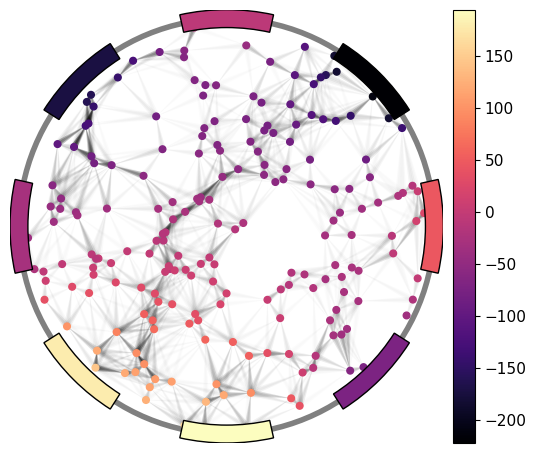

In [16]:
current_distribution(device)

['ID', 'acc_xy', 'don_xy', 'ele_xy', 'event_matrix', 'energies', 'sim_time']


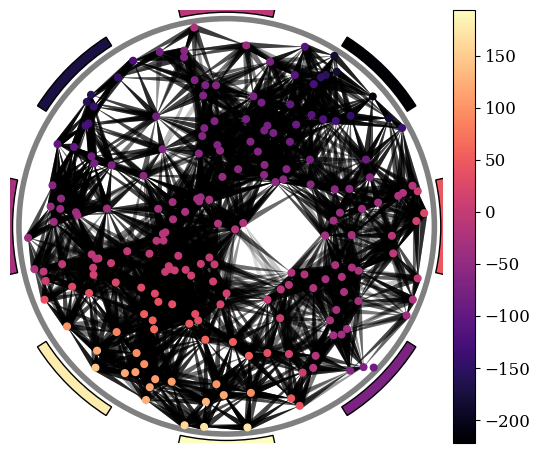

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as ps
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

# ... keep your colormap, triangle_from_src_to_dst, etc.

def current_distribution(device_data):
    events = device_data['event_matrix']
    simulation_time = device_data['sim_time']
    acc_xy = device_data['acc_xy']
    ele_xy = device_data['ele_xy']
    energies = device_data['energies']

    n_A = acc_xy.shape[0]
    n_E = ele_xy.shape[0]

    net_events = (events - events.T)
    abs_current = np.abs(net_events) / simulation_time

    # --- LOG SCALE SETUP (safe with zeros) ---
    # Consider only currents > 0 for log scaling
    positive = abs_current[abs_current > 0]
    if positive.size == 0:
        # nothing to draw
        abs_current_log01 = np.zeros_like(abs_current, dtype=float)
        log_norm = None
    else:
        # you can also choose a percentile to reduce outlier dominance, e.g. vmax=np.percentile(positive, 99)
        vmin = positive.min()
        vmax = positive.max()
        log_norm = LogNorm(vmin=vmin, vmax=vmax, clip=True)

        # Map to [0,1] using the log norm; keep zeros as 0
        abs_current_log01 = np.zeros_like(abs_current, dtype=float)
        mask = abs_current > 0
        abs_current_log01[mask] = log_norm(abs_current[mask])

    # OPTIONAL: threshold in log-space (instead of linear 0.01)
    # This corresponds to "at least 1% of the log range"
    threshold = 0.01

    # --- energies to color (unchanged) ---
    cmap = plt.get_cmap('magma')
    normE = plt.Normalize(vmin=energies.min(), vmax=energies.max())
    colors = cmap(normE(energies))

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_aspect('equal', adjustable='box')

    # Device boundary
    radius = float(np.max(np.linalg.norm(acc_xy, axis=1)))
    ax.add_patch(ps.Circle((0.0, 0.0), radius=radius+0.15, fill=None, edgecolor='gray', zorder=4, lw=4))

    # Electrodes (unchanged)
    arcs = []
    th = np.linspace(0.0, 315, n_E)
    th_width = 12.5
    for i in range(n_E):
        arcs.append(
            ps.Wedge(
                center=(0, 0),
                r=radius + .8,
                fc=colors[i+n_A],
                ec='k',
                theta1=th[i]-th_width,
                theta2=th[i]+th_width,
                width=0.4,
                zorder=5
            )
        )
    for arc in arcs:
        ax.add_patch(arc)

    # Acceptor nodes
    node_radius = 0.13
    base_width = 2.0 * node_radius
    for i, pt in enumerate(acc_xy):
        ax.add_patch(ps.Circle((pt[0], pt[1]), radius=node_radius, zorder=4, color=colors[i]))

    # Plot currents with LOG-scaled alpha
    for i in range(n_A):
        for j in range(n_A):
            a = float(abs_current_log01[i, j])  # in [0,1], log-scaled, zero-safe
            if a > threshold:
                if net_events[i, j] > 0:
                    src = acc_xy[i]
                    dest = acc_xy[j]
                    tri = triangle_from_src_to_dst(src, dest, base_width)
                elif net_events[i, j] < 0:
                    src = acc_xy[j]
                    dest = acc_xy[i]
                    tri = triangle_from_src_to_dst(src, dest, base_width)
                else:
                    continue

                if tri is None:
                    continue

                ax.add_patch(
                    ps.Polygon(
                        tri,
                        closed=True,
                        facecolor='black',
                        edgecolor='none',
                        alpha=a,
                        zorder=3
                    )
                )

    # Energy colorbar (unchanged)
    from matplotlib.cm import ScalarMappable
    sm = ScalarMappable(norm=normE, cmap=cmap)
    sm.set_array([])
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.1)
    fig.colorbar(sm, cax=cax)

    ax.set_xlim(-radius - 0.5, radius + 0.5)
    ax.set_ylim(-radius - 0.5, radius + 0.5)
    ax.axis('off')
    plt.savefig('workflow_simulated_device.pdf')
    plt.show()
device = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/device_sanpshots/device_4.npz")
print(device.files)
current_distribution(device)

4.4.0
11.8
2.7.0+cu118
2.6.1
1000000
0.0
25.180101968112567
0.0
23.51147972282965
0.0
23.51147972282965
Bbox(x0=0.6155882352941178, y0=0.18838235294117656, x1=0.8200000000000001, y1=0.8016176470588234)


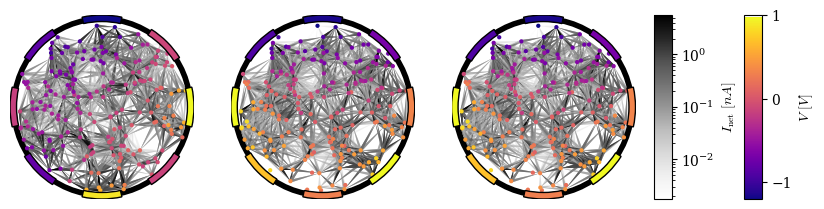

In [23]:
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib.patches as ps
import torch
import torch_geometric
import pandas as pd
import torch.nn as nn
import optuna

print(optuna.__version__)
optuna.logging.set_verbosity(optuna.logging.WARNING)

import torch, os

import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.tri as mtri
from matplotlib.colors import LogNorm
from visualize_hops import visualize_current, current_snapshot
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.ticker import LogFormatterSciNotation
from mpl_toolkits.axes_grid1 import make_axes_locatable

import matplotlib as mpl
mpl.rcParams.update({
    "font.size": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.titlesize": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 10,
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

from torch_geometric.data import Data
from torch_geometric.data import HeteroData
from scipy.optimize import curve_fit
from sm import NeuralNet
#from utils import create_dopant_configuration, current_distribution

def current_distribution(ax, add_cbar, device_data, alpha_cutoff):
    
    """ Load data"""
    e_0 = 1.60217663e-19
    kbT = 77.0*1.380649e-23
    events = device_data['event_matrix']
    simulation_time = device_data['sim_time']
    acc_xy = device_data['acc_xy']
    don_xy = device_data['don_xy']
    ele_xy = device_data['ele_xy']
    energies = device_data['energies'] * kbT / e_0

    n_A = acc_xy.shape[0]
    n_E = ele_xy.shape[0]

    current_scaling_factor = 1e9*1e12 # nanon ampere and time to secondes 

    net_events = (events - events.T)
    dir_rows, dir_cols = np.where(net_events > 0)
    #lower_half_currents = np.abs(np.tril(net_events, k=-1))
    abs_current = np.abs(net_events) / simulation_time * e_0 * current_scaling_factor

    """positive = abs_current[abs_current > 0]

    vmin = positive.min()
    vmax = positive.max()
    curr_norm = LogNorm(vmin=vmin, vmax=vmax)"""
    positive = abs_current[abs_current > 0]
    vmin = np.percentile(positive, 0.1)   # try 1–5
    vmax = np.percentile(positive, 99)  # try 95–99
    vmin = max(vmin, positive.min())
    vmax = max(vmax, vmin * 1.0001)
    
    curr_norm = LogNorm(vmin=vmin, vmax=vmax, clip=True)
    curr_cmap = plt.get_cmap('Greys')
    
    def alpha_from_current(I, vmin, vmax, a_min=0.05, a_max=0.95):
        # map current to [0,1] in log space, then to [a_min, a_max]
        t = (np.log10(I) - np.log10(vmin)) / (np.log10(vmax) - np.log10(vmin))
        t = np.clip(t, 0.0, 1.0)
        return a_min + t * (a_max - a_min)

    min_current = abs_current.min()
    max_current = abs_current.max()
    print(min_current)
    print(max_current)
    #print(events.sum())

    abs_current_normalized = abs_current #/ max_current
    #abs_current_normalized = log_scaling(abs_current, None)

    acc_face_clr = (0, 0.6, 0, 1)

    """ Energies to color """
    cmap = plt.get_cmap('plasma')
    norm = plt.Normalize(vmin=energies.min(), vmax=energies.max())
    colors = cmap(norm(energies))

    ax.set_aspect('equal', adjustable='box')

    """ Device boundary """
    radius = float(np.max(np.linalg.norm(acc_xy, axis=1)))
    device_boundary = ps.Circle(
        xy=(0.0, 0.0),
        radius=radius+0.15,
        fill=None,
        edgecolor='k',
        zorder=4,
        lw=4
    )
    ax.add_patch(device_boundary)

    """ Electrodes """
    arcs = []
    th = np.linspace(0.0, 315, n_E)
    th_width = 12.5
    for i in range(n_E):
        """arcs.append(
            ps.Arc(
                xy=(0.0, 0.0),
                width=2*radius + 0.40,
                height=2*radius + 0.40,
                linewidth=8,
                color=colors[i + n_A],
                theta1=th[i]-th_width,
                theta2=th[i]+th_width,
                zorder=5
            )
        )"""
        arcs.append(
            ps.Wedge(
                center=(0, 0),
                r=radius + .5,
                fc=colors[i+n_A],
                ec='k',
                theta1=th[i]-th_width,
                theta2=th[i]+th_width,
                width = 0.6,
                zorder=5,
            )
        )
        
    for i, arc in enumerate(arcs):
        ax.add_patch(arc)
        #ax.text(x=(radius + 0.4)*np.cos(th[i]), y=(radius + 0.4)*np.sin(th[i]), s=rf'$V_{i}$')
        
    """ Acceptor and donors """
    node_radius = 0.13
    base_width = 2.0 * node_radius
    for i, pt in enumerate(acc_xy):
        ax.add_patch(
            ps.Circle(
                xy=(pt[0], pt[1]),
                radius=node_radius,
                zorder=4,
                color=colors[i]
            )
        )

    """ Plot currents between acceptors """
    for i in range(n_A):
        for j in range(n_A):
            I = abs_current[i, j]  # current in nA
            if I <= 0:
                continue
            
            # IMPORTANT: alpha_cutoff is now interpreted in nA
            if I < alpha_cutoff:
                continue
            
            a = alpha_from_current(I, vmin, vmax)
            fc = curr_cmap(curr_norm(I))  # color encodes current too (matches colorbar)
            
            if net_events[i, j] > 0:
                src = acc_xy[i]
                dest = acc_xy[j]
                tri = triangle_from_src_to_dst(src, dest, base_width)
            elif net_events[i, j] < 0:
                src = acc_xy[j]
                dest = acc_xy[i]
                tri = triangle_from_src_to_dst(src, dest, base_width)
            else:
                continue
            
            if tri is None:
                continue
            
            ax.add_patch(
                ps.Polygon(
                    tri,
                    closed=True,
                    facecolor=fc,      # was 'black'
                    edgecolor='none',
                    alpha=a,           # was a_val (way too large / not in [0,1])
                    zorder=3
                )
            )
            """a_val = abs_current_normalized[i, j]
            if a_val > alpha_cutoff:
                if net_events[i, j] > 0:
                    src = acc_xy[i]
                    dest = acc_xy[j]
                    tri = triangle_from_src_to_dst(src, dest, base_width)
                    if tri is None:
                        continue
                    ax.add_patch(
                        ps.Polygon(
                            tri,
                            closed=True,
                            facecolor='black',
                            edgecolor='none',
                            alpha=a_val,#alpha=np.sqrt(a_val),
                            zorder=3
                        )
                    )
                elif net_events[i, j] < 0:
                    src = acc_xy[j]
                    dest = acc_xy[i]
                    tri = triangle_from_src_to_dst(src, dest, node_radius)
                    if tri is None:
                        continue
                    ax.add_patch(
                        ps.Polygon(
                            tri,
                            closed=True,
                            facecolor='black',
                            edgecolor='none',
                            alpha=a_val,#alpha=np.sqrt(a_val),
                            zorder=3
                        )
                    )"""
    cbar_E = None
    cbar_I = None

    ax.set_xlim(-radius - 0.5, radius + 0.5)
    ax.set_ylim(-radius - 0.5, radius + 0.5)
    ax.axis('off')
    
    # Create mappables for colorbars (but do NOT draw colorbars here)
    sm_I = ScalarMappable(norm=curr_norm, cmap=curr_cmap)
    sm_I.set_array([])
    
    sm_E = ScalarMappable(norm=norm, cmap=cmap)
    sm_E.set_array([])
    
    return ax, sm_E, sm_I

def triangle_from_src_to_dst(src, dst, base_width):
    """
    Return the 3 vertices of an isosceles triangle whose base is centered at src
    (length = base_width) and whose tip is at dst.
    """
    v = dst - src
    L = np.linalg.norm(v)
    if L == 0:
        return None  # same point, nothing to draw
    u = v / L                        # direction from src to dst
    n = np.array([-u[1], u[0]])      # unit normal (perpendicular)
    half = 0.5 * base_width

    p_left  = src + half * n
    p_right = src - half * n
    tip     = dst
    return np.vstack([p_left, p_right, tip])


print(torch.version.cuda)
print(torch.__version__)
print(torch_geometric.__version__)

fig_width = 6.3
fig_height = 6.3 / 3
fig, ax = plt.subplots(ncols=3, figsize=(9, 3))

"""for i, (a, v) in enumerate(zip(ax, volts)):
    
    a.set_box_aspect(1)
    device_data = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/device_sanpshots/dist_device_0_v={v}_radial.npz')
    #print(device_data.files)
    #print(device_data.files)
    #print(device_data['event_matrix'].sum())
    
    _, cbar_I, scbar_E = current_distribution(a, True, device_data, 0.0) 

    a.set_title(rf'$V_{{\mathrm{{in}}}} = {v}$')
#plt.savefig(f'dnpu_current_distribution.pdf', bbox_inches="tight")"""

device_data_0 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/device_0_a=5_ed=0.1.npz')
device_data_1 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/device_1_a=5_ed=0.1.npz')
device_data_2 = np.load(f'/gpfs/bwfor/work/ws/hd_gy283-my_data/final_datasets/device_2_a=5_ed=0.1.npz')

print(device_data_0['event_matrix'].sum())

a_0, _, _ = current_distribution(ax[0], None, device_data_0, 0.0)
a_1, _, _ = current_distribution(ax[1], None, device_data_1, 0.0)
a_2, sm_E, sm_I = current_distribution(ax[2], True, device_data_1, 0.0)

# Reserve space on the right for two bars (tune right=...)
fig.subplots_adjust(right=0.82)

pos = ax[2].get_position()  # Bbox of the right plot in figure coords
print(pos)

w = 0.02
pad = 0.02
# current colorbar (first)
cax_I = fig.add_axes([pos.x1+pad, pos.y0, w, pos.height])  # [left, bottom, width, height]
cbar_I = fig.colorbar(sm_I, cax=cax_I, format=LogFormatterSciNotation())
cbar_I.set_label("$I_{\mathrm{net}} \, \, [nA]$")

# energy colorbar (second, further right)
cax_E = fig.add_axes([pos.x1+0.1+pad, pos.y0, w, pos.height])
cbar_E = fig.colorbar(sm_E, cax=cax_E)
cbar_E.set_label(r"$V \, \, [V]$")
cbar_E.set_ticks([-1., 0.0, 1.])

a_0.set_box_aspect(1)
a_1.set_box_aspect(1)
a_2.set_box_aspect(1)

plt.savefig('hopping_graphs.pdf', bbox_inches='tight')

['ID', 'acceptor_coordinates', 'donor_coordinates', 'electrode_coordinates', 'event_counts', 'device_time']
0.0
0.21957473943052375
10000000


/tmp/ipykernel_1394990/3753818821.py:143: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  net = (events - events.T) / float(total_time)


n=2807
min=1.63e-05, max=0.215
Total spread: 4.12 orders of magnitude
1–99% spread: 3.50 orders of magnitude
10–90% spread: 2.17 orders of magnitude
0.001141929173890021 0.2215342597346641


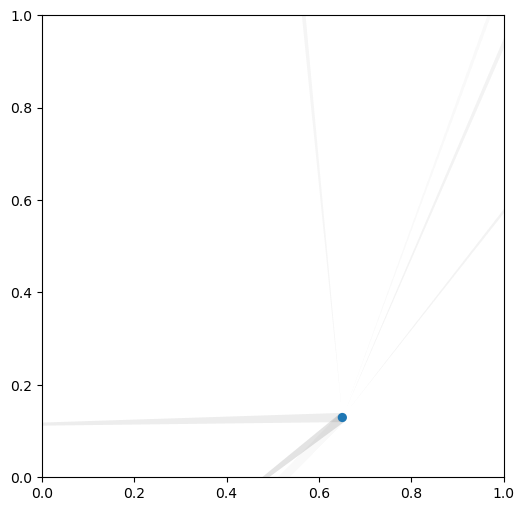

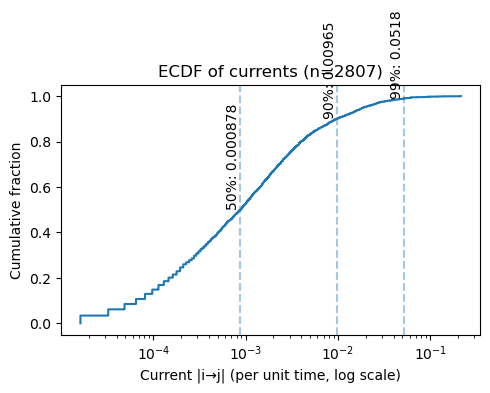

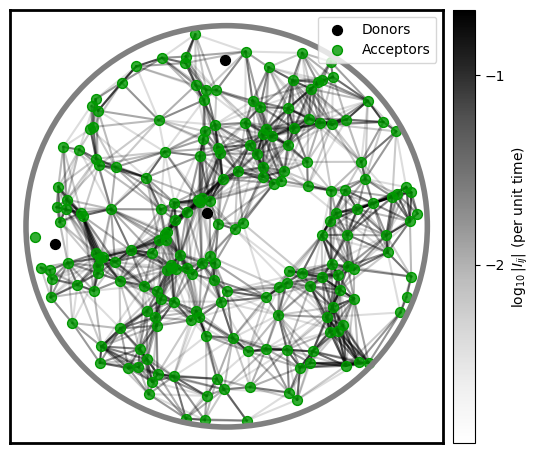

1.6259024618024106e-05 0.2149443054502787


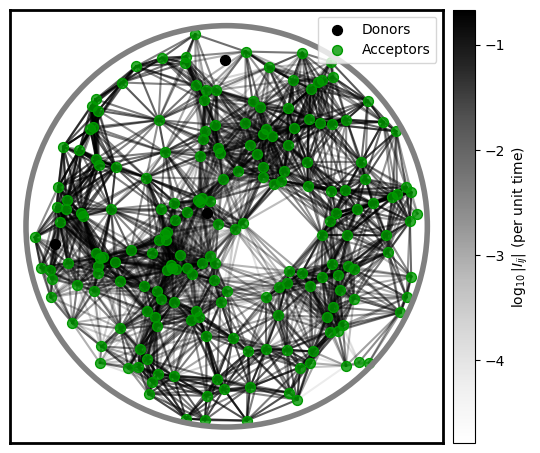

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as ps
from visualize_hops import visualize_current, current_snapshot

device_0 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/device_sanpshots/device_0.npz")
device_1 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/device_sanpshots/device_1.npz")
device_2 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/device_sanpshots/device_0_sig=0.1.npz")
device_3 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/device_sanpshots/device_3.npz")

def triangle_from_src_to_dst(src, dst, base_width):
    """
    Return the 3 vertices of an isosceles triangle whose base is centered at src
    (length = base_width) and whose tip is at dst.
    """
    v = dst - src
    L = np.linalg.norm(v)
    if L == 0:
        return None  # same point, nothing to draw
    u = v / L                        # direction from src to dst
    n = np.array([-u[1], u[0]])      # unit normal (perpendicular)
    half = 0.5 * base_width

    p_left  = src + half * n
    p_right = src - half * n
    tip     = dst
    return np.vstack([p_left, p_right, tip])

def current_distribution(device_data):

    events = device_data['event_counts']
    simulation_time = device_data['device_time']
    acc_xy = device_data['acceptor_coordinates']
    don_xy = device_data['donor_coordinates']

    net_events = (events - events.T)

    # Current magnitude per edge per unit time
    abs_current = np.abs(net_events) / simulation_time
    max_current = abs_current.max()
    if max_current == 0:
        print("No current to draw.")
        return

    abs_current_normalized = abs_current / max_current

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_aspect('equal', adjustable='box')

    radius = float(np.max(np.linalg.norm(acc_xy, axis=1)))
    device_boundary = ps.Circle(
        xy=(0.0, 0.0),
        radius=radius + 0.15,
        fill=None,
        edgecolor='gray',
        zorder=4,
        lw=4
    )
    ax.add_patch(device_boundary)

    node_radius = 0.15
    base_width = 2.0 * node_radius   # base equals point diameter

    # draw nodes
    for pt in acc_xy:
        ax.add_patch(
            ps.Circle(
                xy=(pt[0], pt[1]),
                radius=node_radius,
                zorder=5,           # a tad above triangles so nodes are visible
                facecolor='white',
                edgecolor='black',
                lw=1.0
            )
        )

    n_A = acc_xy.shape[0]
    thresh = 0.01                    # your existing visibility threshold

    for i in range(n_A):
        for j in range(n_A):
            # draw only if net flow is from i to j and strong enough
            if net_events[i, j] > 0 and abs_current_normalized[i, j] > thresh:
                tri = triangle_from_src_to_dst(acc_xy[i], acc_xy[j], base_width)
                if tri is None:
                    continue
                ax.add_patch(
                    ps.Polygon(
                        tri,
                        closed=True,
                        facecolor='black',
                        edgecolor='none',
                        alpha=float(abs_current_normalized[i, j]),
                        zorder=3
                    )
                )

    ax.set_xlim(-radius - 0.5, radius + 0.5)
    ax.set_ylim(-radius - 0.5, radius + 0.5)
    ax.axis('off')
    plt.show()

device_0 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/device_sanpshots/device_0.npz")

current_distribution(device_0)

def current_distribution(device_data):

    events = device_data['event_counts']
    simulation_time = device_data['device_time']
    acc_xy = device_data['acceptor_coordinates']
    don_xy = device_data['donor_coordinates']
    ele_xy = device_data['electrode_coordinates']

    net_events = (events - events.T)
    dir_rows, dir_cols = np.where(net_events > 0)
    #lower_half_currents = np.abs(np.tril(net_events, k=-1))
    abs_current = np.abs(net_events) / simulation_time

    min_current = abs_current.min()
    max_current = abs_current.max()
    print(min_current)
    print(max_current)
    print(events.sum())

    abs_current_normalized = abs_current / max_current

    acc_face_clr = (0, 0.6, 0, 1)

    fig, ax = plt.subplots(figsize=(6, 6))

    ax.set_aspect('equal', adjustable='box')
    
    """ Device boundary """
    radius = float(np.max(np.linalg.norm(acc_xy, axis=1)))
    device_boundary = ps.Circle(
        xy=(0.0, 0.0),
        radius=radius+0.15,
        fill=None,
        edgecolor='gray',
        zorder=4,
        lw=4
    )
    ax.add_patch(device_boundary)

    """ Electrodes """
    arcs = []
    th = np.linspace(0.0, 315, 8)
    th_width = 12.5
    for i in range(ele_xy.shape[0]):
        arcs.append(
            ps.Arc(
                xy=(0.0, 0.0),
                width=2*radius,
                height=2*radius,
                linewidth=5.9,
                theta1=th[i]-th_width,
                theta2=th[i]+th_width,
                zorder=5
            )
        )
    for arc in arcs:
        ax.add_patch(arc)
        
    node_radius = 0.01
    for pt in acc_xy:
        ax.add_patch(
            ps.Circle(
                xy=(pt[0], pt[1]),
                radius=node_radius,
                zorder=4
            )
        )

    tip_len = 1.2 * node_radius  # tweak to taste
    face = dict(edgecolor='none')  # no outline; set facecolor below per edge


    def triangle_wedge(ax, p0, p1, node_radius, tip_at_center=True, **poly_kwargs):
        """
        Isosceles triangle with base centered on origin node (p0), base length = 2*node_radius.
        The apex points toward p1.
    
        tip_at_center=True  -> apex at the destination center (p1)
        tip_at_center=False -> apex at the destination circle edge (stops at its boundary)
        """
        v = p1 - p0
        L = np.hypot(v[0], v[1])
        if L == 0:
            return None
        u = v / L
        n = np.array([-u[1], u[0]])  # perpendicular
    
        # base endpoints centered at p0; base length = 2 * node_radius
        b1 = p0 + n * node_radius
        b2 = p0 - n * node_radius
    
        apex = p1 if tip_at_center else (p1 - u * node_radius)
    
        tri = ps.Polygon([b1, b2, apex], closed=True, **poly_kwargs)
        ax.add_patch(tri)
        return tri 

    n_A = acc_xy.shape[0]
    for i in range(n_A):
        for j in range(n_A):
            if abs_current_normalized[i, j] > 0.0 and abs_current_normalized[i,j] > 0.01:
                """ax.plot(
                    [acc_xy[i, 0], acc_xy[j, 0]],
                    [acc_xy[i, 1], acc_xy[j, 1]],
                    color='black',
                    alpha=abs_current_normalized[i, j],
                    zorder=3,
                    lw=1.5
                )"""
                if net_events[i, j] > 0:
                    p0, p1 = acc_xy[i], acc_xy[j]
                elif net_events[i, j] < 0:
                    p0, p1 = acc_xy[j], acc_xy[i]
                else:
                    continue
    
                triangle_wedge(
                    ax, p0, p1, node_radius,
                    tip_at_center=False,     # set True if you want the tip at the center
                    facecolor='black',
                    edgecolor='none',
                    alpha=float(abs_current_normalized[i, j])
                )
                
current_distribution(device_3)

events = device_1['event_counts']
total_time = device_1['device_time']
net_events = (events - events.T) / total_time

# 1) Net current per unit time
net = (events - events.T) / float(total_time)

# 2) Take unique edge magnitudes (lower triangle, no diagonal)
vals = np.abs(np.tril(net, k=-1)).ravel()
vals = vals[vals > 0]  # keep positives only

if vals.size == 0:
    print("No positive currents found.")
else:
    vmin = vals.min()
    vmax = vals.max()
    orders = np.log10(vmax / vmin)

    # Robust alternatives (ignore outliers)
    q1, q99 = np.percentile(vals, [1, 99])
    q10, q90 = np.percentile(vals, [10, 90])
    orders_1_99  = np.log10(q99 / q1)
    orders_10_90 = np.log10(q90 / q10)

    print(f"n={vals.size}")
    print(f"min={vmin:.3g}, max={vmax:.3g}")
    print(f"Total spread: {orders:.2f} orders of magnitude")
    print(f"1–99% spread: {orders_1_99:.2f} orders of magnitude")
    print(f"10–90% spread: {orders_10_90:.2f} orders of magnitude")

if vals.size == 0:
    print("No positive currents to plot.")
else:
    # 3) ECDF
    x = np.sort(vals)
    y = np.arange(1, x.size + 1) / x.size

    plt.figure(figsize=(5,4))
    plt.step(x, y, where="post")
    plt.xscale("log")  # log-scale on current axis
    plt.xlabel("Current |i→j| (per unit time, log scale)")
    plt.ylabel("Cumulative fraction")
    plt.title(f"ECDF of currents (n={x.size})")

    # Optional: show a few percentiles
    for p in (0.5, 0.9, 0.99):
        v = np.quantile(x, p)
        plt.axvline(v, ls="--", alpha=0.4)
        plt.text(v, p, f"{p*100:.0f}%: {v:.3g}", rotation=90, va="bottom", ha="right")

    plt.tight_layout()

current_snapshot(device_0['event_counts'], device_0['acceptor_coordinates'], device_0['donor_coordinates'], device_0['device_time'])
current_snapshot(device_1['event_counts'], device_1['acceptor_coordinates'], device_1['donor_coordinates'], device_1['device_time'])
#visualize_current(device_2['event_counts'], device_2['acceptor_coordinates'], device_2['donor_coordinates'], device_2['device_time'])

plt.show()

/tmp/ipykernel_541395/1602346347.py:40: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  net_hops = (hopping_counts - hopping_counts.T) / float(total_time)
/tmp/ipykernel_541395/1602346347.py:103: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap(cmap_name)


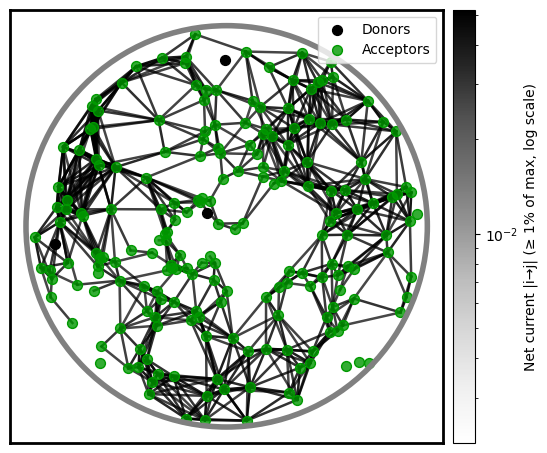

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.cm import ScalarMappable, get_cmap

def visualize_current(
    hopping_counts,
    acceptor_pos,
    donor_pos,
    total_time,
    *,
    map_style="alpha",                  # "alpha" or "color"
    cmap_name="viridis",
    # --- alpha controls
    alpha_min=0.15,
    alpha_max=0.95,
    # --- contrast controls
    p_low=1.0,                          # percentile low cut (ignore bottom x%)
    p_high=99.0,                        # percentile high cut (ignore top x%)
    gamma=0.7,                          # <1 boosts low values; >1 boosts highs
    equalize=False,                     # True -> rank/quantile mapping
    # --- transform for values -> log-like domain
    transform="log",                    # "log" | "log1p" | "asinh"
    log1p_scale=1.0,
    asinh_scale=1.0,
    # --- style
    line_width=1.8,
    draw_colorbar=True,
    show_debug=False,
    # --- NEW: draw only edges >= x% of the global max current
    min_pct_of_max=0.0                  # e.g., 10.0 -> keep >= 10% of max
):
    """
    Visualizes net hops (current) between acceptor sites per unit time.
    Only edges with |current| >= min_pct_of_max% of the *global* max are drawn.
    """
    # --- Compute antisymmetric net hops per unit time
    net_hops = (hopping_counts - hopping_counts.T) / float(total_time)

    # --- Collect strictly positive magnitudes from lower triangle (exclude diagonal)
    lower = np.abs(np.tril(net_hops, k=-1)).ravel()
    pos = lower[lower > 0]

    if pos.size == 0:
        _draw_frame_and_nodes(acceptor_pos, donor_pos)
        plt.show()
        return

    # --- Global max and threshold
    global_max = float(pos.max())
    thr = float((min_pct_of_max / 100.0) * global_max)

    # --- Robust vmin/vmax using percentiles (on all positives, not only filtered)
    lo = np.percentile(pos, p_low)
    hi = np.percentile(pos, p_high)
    vmin = max(lo, np.finfo(float).tiny)
    vmax = max(hi, vmin * (1 + 1e-9))

    # --- For display (colorbar), start at at least the threshold
    vmin_disp = max(vmin, thr)
    vmax_disp = max(vmax, vmin_disp * (1 + 1e-9))

    # --- Define transform into a "log-like" space
    if transform == "log":
        f = lambda v: np.log(v)
        a, b = np.log(vmin), np.log(vmax)
    elif transform == "log1p":
        s = float(log1p_scale)
        f = lambda v: np.log1p(v / s)
        a, b = np.log1p(vmin / s), np.log1p(vmax / s)
    elif transform == "asinh":
        s = float(asinh_scale)
        f = lambda v: np.arcsinh(v / s)
        a, b = np.arcsinh(vmin / s), np.arcsinh(vmax / s)
    else:
        raise ValueError("transform must be 'log', 'log1p', or 'asinh'.")

    denom = (b - a) if (b > a) else 1.0

    # --- Optionally rank-equalize; else transformed normalization with gamma
    if equalize:
        uniq_vals, uniq_idx = np.unique(pos, return_index=True)
        uniq_ranks = np.linspace(0.0, 1.0, uniq_vals.size, endpoint=True)
        def t_from_value(v):
            return float(np.interp(v, uniq_vals, uniq_ranks))
    else:
        def t_from_value(v):
            t = (f(v) - a) / denom
            return float(np.clip(t, 0.0, 1.0) ** gamma)

    # --- Figure and axes
    fig, ax = _prep_axes(acceptor_pos)
    _scatter_nodes(ax, acceptor_pos, donor_pos)

    # --- Normalization for colorbar
    log_norm_ok = (vmin_disp > 0) and (vmax_disp > vmin_disp)
    if log_norm_ok:
        norm_for_cbar = mcolors.LogNorm(vmin=vmin_disp, vmax=vmax_disp)
    else:
        norm_for_cbar = mcolors.Normalize(vmin=vmin_disp, vmax=vmax_disp)
    cmap = get_cmap(cmap_name)

    # --- Draw only edges >= threshold
    n_acceptors = acceptor_pos.shape[0]
    for i in range(n_acceptors):
        for j in range(i + 1, n_acceptors):
            current_value = abs(net_hops[i, j])
            if current_value <= 0 or current_value < thr:
                continue  # skip edges below x% of max

            t = t_from_value(current_value)
            alpha_val = float(alpha_min + t * (alpha_max - alpha_min))
            alpha_val = float(np.clip(alpha_val, alpha_min, alpha_max))

            if map_style == "color":
                color = cmap(norm_for_cbar(current_value)) if log_norm_ok else cmap(1.0)
            elif map_style == "alpha":
                color = "black"
            else:
                raise ValueError("map_style must be 'alpha' or 'color'.")

            ax.plot(
                [acceptor_pos[i, 0], acceptor_pos[j, 0]],
                [acceptor_pos[i, 1], acceptor_pos[j, 1]],
                color=color, lw=line_width, alpha=alpha_val
            )

    ax.legend(loc="upper right")

    # --- Colorbar
    if draw_colorbar:
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        if log_norm_ok:
            if map_style == "color":
                sm = ScalarMappable(norm=norm_for_cbar, cmap=cmap)
            else:
                sm = ScalarMappable(norm=norm_for_cbar, cmap=plt.cm.Greys)
            sm.set_array([])
            cbar = fig.colorbar(sm, cax=cax)
            label = f"Net current |i→j| (≥ {min_pct_of_max:.0f}% of max, log scale)"
            cbar.set_label(label)
        else:
            cax.axis("off")

    if show_debug:
        kept = (pos >= thr).sum()
        print(
            f"[visualize_current] positives={pos.size}, kept={kept}, "
            f"thr={thr:.3g} ({min_pct_of_max:.1f}% of global_max={global_max:.3g}), "
            f"vmin={vmin:.3g}, vmax={vmax:.3g}, vmin_disp={vmin_disp:.3g}, vmax_disp={vmax_disp:.3g}"
        )

    plt.show()


# ---- helpers (unchanged) ----

def _prep_axes(acceptor_pos):
    max_radius = float(np.max(np.linalg.norm(acceptor_pos, axis=1)))
    padding = 0.1 * max_radius
    xlim = (-max_radius - padding, max_radius + padding)
    ylim = (-max_radius - padding, max_radius + padding)

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect("equal")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(2)

    device_boundary = patches.Circle((0, 0), radius=max_radius + 0.15,
                                     fill=False, edgecolor="gray", zorder=4, lw=4)
    ax.add_patch(device_boundary)
    return fig, ax

def _scatter_nodes(ax, acceptor_pos, donor_pos):
    acc_face_color = (0, 0.6, 0, 0.8)
    acc_edge_color = (0, 0.6, 0, 1.0)
    if donor_pos is not None and len(donor_pos) > 0:
        ax.scatter(donor_pos[:, 0], donor_pos[:, 1], s=50, c="k", zorder=3, label="Donors")
    ax.scatter(acceptor_pos[:, 0], acceptor_pos[:, 1], s=50,
               facecolor=acc_face_color, edgecolors=acc_edge_color,
               zorder=3, label="Acceptors")

def _draw_frame_and_nodes(acceptor_pos, donor_pos):
    _, ax = _prep_axes(acceptor_pos)
    _scatter_nodes(ax, acceptor_pos, donor_pos)


device_0 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/device_sanpshots/device_0.npz")
device_1 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/device_sanpshots/device_1.npz")

visualize_current(
    device_1['event_counts'],
    device_1['acceptor_coordinates'],
    device_1['donor_coordinates'],
    device_1['device_time'],
    map_style="alpha",                  # "alpha" or "color"
    cmap_name="viridis",
    # --- alpha controls
    alpha_min=0.15,
    alpha_max=0.95,
    # --- contrast controls
    p_low=1.0,                          # percentile low cut (ignore bottom x%)
    p_high=99.0,                        # percentile high cut (ignore top x%)
    gamma=0.7,                          # <1 boosts low values; >1 boosts highs
    equalize=False,                     # True -> rank/quantile mapping (discrete but high contrast)
    # --- transform for values -> log-like domain
    transform="log",                    # "log" | "log1p" | "asinh"
    log1p_scale=1.0,                    # controls curvature for log1p
    asinh_scale=1.0,                    # controls curvature for asinh
    # --- style
    line_width=1.8,
    draw_colorbar=True,
    show_debug=False,
    min_pct_of_max=1.0  
)

{'data_dir': PosixPath('/gpfs/bwfor/work/ws/hd_gy283-my_data/data_uni_n_a=50'), 'num_batches': 180, 'batch_size': 512, 'x_mean': array([-0.00239967, -0.00082998,  0.00186093,  0.00096561, -0.00027758,
       -0.00078853,  0.00067195]), 'x_std': array([0.86632003, 0.86614983, 0.86601129, 0.86586988, 0.86645395,
       0.86676409, 0.8656184 ]), 'y_mean': -0.000514854630274363, 'y_std': 0.01131343661014544, 'layer_dims': [7, 60, 60, 60, 1], 'num_epochs': 500, 'lr': 0.001, 'save_name': PosixPath('/home/hd/hd_hd/hd_gy283/kmc_project/models/sm_uni_n_a=50_1e7')}
control_volts: tensor([-0.0032,  1.1420,  0.5001, -0.1467, -0.4889, -1.2469])


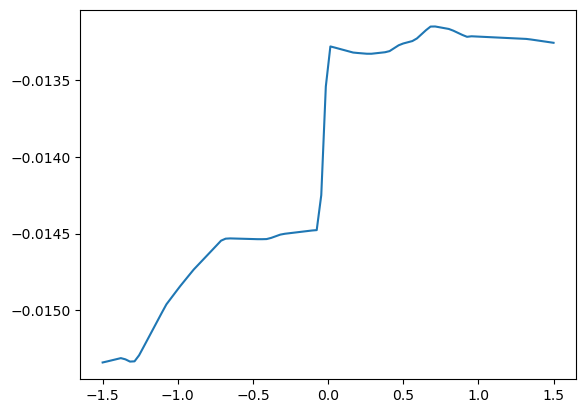

In [49]:
state_dict = torch.load("/home/hd/hd_hd/hd_gy283/kmc_project/models/sm_uni_n_a=50_1e7.pth", map_location="cpu", weights_only=False)
print(state_dict['args'])
x_mean = state_dict['args']['x_mean']
x_std = state_dict['args']['x_std']
y_mean = state_dict['args']['y_mean']
y_std = state_dict['args']['y_std']
layer_dims = state_dict['args']['layer_dims']
model = NeuralNet(layer_dims, x_mean, x_std, y_mean, y_std)
model.load_state_dict(state_dict['model_state_dict'])
model.eval()
N = 100
with torch.no_grad():
    xs = torch.linspace(-1.5, 1.5, N).unsqueeze(1)
    cs = torch.empty(6).uniform_(-1.5, 1.5).expand(N, -1)
    print(f"control_volts: {cs[0, :]}")
    input_tensor = torch.cat([xs, cs], dim=-1)

    y_pred = model(input_tensor.float()).detach().cpu()
volt_range = torch.linspace(-1.5, 1.5, N)
plt.plot(volt_range, y_pred)

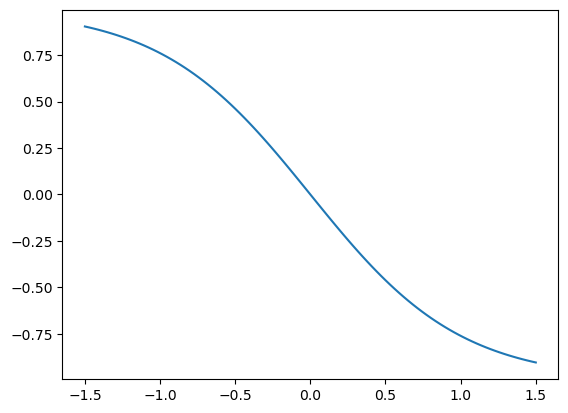

In [57]:
def target_function(t: torch.Tensor):
    N = t.shape[0]
    m = nn.Tanh()
    return -m(t)

input_idx = 0
x = torch.linspace(-1.5, 1.5, N)
target = target_function(x).unsqueeze(1)
plt.plot(x, target)

In [58]:
model.eval()

def mse_loss(x: torch.Tensor, y: torch.Tensor):

    N = x.shape[0]
    x = x.float()
    y = y.float()
    x_norm = (x - x.mean()) / (x.std(unbiased=False) + 1e-8)
    y_norm = (y - y.mean()) / (y.std(unbiased=False) + 1e-8)
    
    mse = torch.mean((y_norm - x_norm)**2).item()

    return mse
    
def objective(trial):

    cv_list = [trial.suggest_float(f"x_{i}", -1.5, 1.5) for i in range(6)]
    cv_tensor = torch.tensor(cv_list, dtype=torch.float32)
    cv_input = cv_tensor.expand(N, -1)
    v_input = torch.linspace(-1.5, 1.5, N).unsqueeze(1)
    
    cv_input_left = cv_input[:, :input_idx]
    cv_input_right = cv_input[:, input_idx:]

    input_tensor = torch.cat([cv_input_left, v_input, cv_input_right], dim=-1)
    with torch.no_grad():
        y_pred = model(input_tensor.float()).detach().cpu()

    mse = mse_loss(y_pred, target)

    if trial.number % 100 == 0:
        print('\x1b[6;30;42m' + f'{trial.number}] Finished with score: {mse: .6f}' + '\x1b[0m')

    return mse
    
tpe = optuna.samplers.TPESampler(multivariate=True, group=True, n_startup_trials=500)
study = optuna.create_study(direction="minimize", sampler=tpe)
study.optimize(objective, n_trials=2_000, n_jobs=4)

print("Best value:", study.best_value)
print("Best params:", study.best_params)    

0] Finished with score:  3.793560
100] Finished with score:  3.533898
200] Finished with score:  3.472999
300] Finished with score:  3.566941
400] Finished with score:  3.943131
500] Finished with score:  3.949371
600] Finished with score:  0.813860
700] Finished with score:  0.711298
800] Finished with score:  0.682546
900] Finished with score:  0.631379
1000] Finished with score:  3.924264
1100] Finished with score:  0.652117
1200] Finished with score:  1.089002
1300] Finished with score:  3.650686
1400] Finished with score:  1.463659
1500] Finished with score:  3.127757
1600] Finished with score:  2.087069
1700] Finished with score:  2.562671
1800] Finished with score:  0.254408
1900] Finished with score:  3.369045
Best value: 0.05677592381834984
Best params: {'x_0': 0.362421394861843, 'x_1': 1.4618418576444339, 'x_2': 1.3337731919101, 'x_3': -1.4200852493513292, 'x_4': 1.243023786341083, 'x_5': -1.2649548306082807}


[0.11637553091480833, 1.4435244007745052, -0.6170103249259223, -1.463547085388857, -1.4123938475969657, -0.4163816138951789]


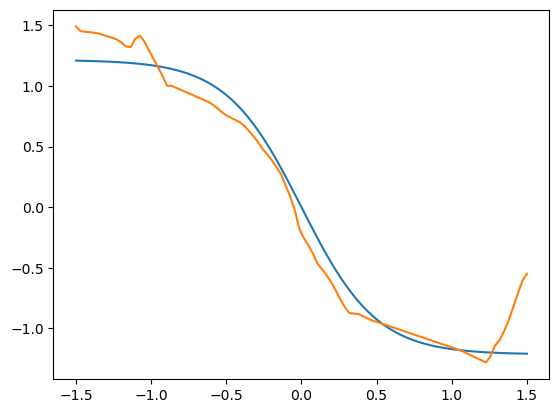

In [56]:
best_vals = []

for v in study.best_params.items():
    best_vals.append(v[1])
print(best_vals)
v = torch.linspace(-1.5, 1.5, N).unsqueeze(-1)
c_volts = torch.tensor(best_vals, dtype=torch.float32).expand(N, -1)

v_tensor = torch.cat([v, c_volts], dim=1)

with torch.no_grad():  
    pred = model(v_tensor).cpu().detach()

target = (target - target.mean()) / target.std()
pred = (pred - pred.mean()) / pred.std()

plt.plot(x, target)
plt.plot(x, pred)

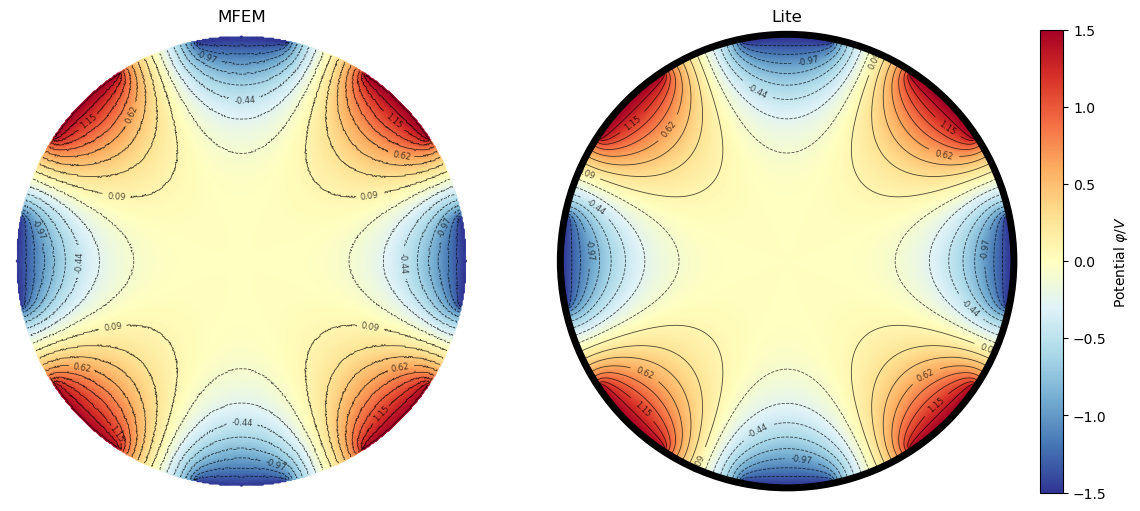

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.tri as mtri

import matplotlib.patches as ps

mfem = pd.read_csv("/home/hd/hd_hd/hd_gy283/kmc_project/data/pde_solver/mfem_xy.csv")
lite = pd.read_csv("/home/hd/hd_hd/hd_gy283/kmc_project/data/pde_solver/lite_xy.csv")  # from your lightweight solver
"""
fig, ax = plt.subplots(1,2, figsize=(10,4), constrained_layout=True)

ax[0].scatter(mfem.x, mfem.y, c=mfem.phi, cmap="RdYlBu_r", s=2)
ax[0].set_title("MFEM"); ax[0].set_aspect('equal')

ax[1].scatter(lite.x, lite.y, c=lite.phi, cmap="RdYlBu_r", s=2)
ax[1].set_title("Lite"); ax[1].set_aspect('equal')

plt.show()
"""

# Choose common contour levels so both panels are comparable
phi_min = min(mfem.phi.min(), lite.phi.min())
phi_max = max(mfem.phi.max(), lite.phi.max())
levels = np.linspace(phi_min, phi_max, 18)  # tweak number of lines here

R = mfem.x.max()

pad = 5.0

fig, ax = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for a in ax:
    a.set_xlim(-R-pad, R+pad)
    a.set_ylim(-R-pad, R+pad)
    a.set_xticks([])
    a.set_yticks([])
    a.spines[:].set_visible(False)

# --- MFEM ---
ax[0].scatter(mfem.x, mfem.y, c=mfem.phi, cmap="RdYlBu_r", s=2, zorder=1)
tri_m = mtri.Triangulation(mfem.x.values, mfem.y.values)
cs_m = ax[0].tricontour(tri_m, mfem.phi.values, levels=levels, colors='k',
                        linewidths=0.6, alpha=0.7, zorder=2)
# Optional labels on a subset of lines (comment out if cluttered)
ax[0].clabel(cs_m, cs_m.levels[::3], fmt="%.2f", fontsize=6, inline=True)
ax[0].set_title("MFEM")
ax[0].set_aspect('equal')

# --- Lite ---
ax[1].scatter(lite.x, lite.y, c=lite.phi, cmap="RdYlBu_r", s=2, zorder=1)
tri_l = mtri.Triangulation(lite.x.values, lite.y.values)
cs_l = ax[1].tricontour(tri_l, lite.phi.values, levels=levels, colors='k',
                        linewidths=0.6, alpha=0.7, zorder=2)
ax[1].clabel(cs_l, cs_l.levels[::3], fmt="%.2f", fontsize=6, inline=True)
ax[1].set_title("Lite")
ax[1].set_aspect('equal')

ax[1].add_patch(ps.Circle(xy=(0,0), radius=R+1.9, fill=None, lw=5))

# Optional: a single shared colorbar
cbar = fig.colorbar(ax[1].collections[0], ax=ax, orientation='vertical', fraction=0.025, pad=0.02)
cbar.set_label("Potential $\\varphi / V$")

plt.show()

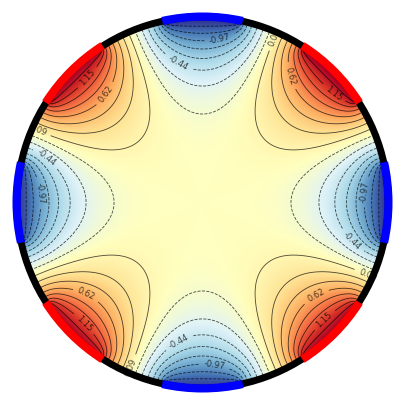

In [17]:
lite = pd.read_csv("/home/hd/hd_hd/hd_gy283/kmc_project/data/pde_solver/lite_xy.csv")  # from your lightweight solver

fig, ax = plt.subplots(figsize=(5,5))
R = 150.0
pad = 7.5
arcs = []
n_electrodes = 8
th = np.linspace(0, 315, 8)
th_width = 12.5

electrode_volts = [-1.5, 1.5, -1.5, 1.5, -1.5, 1.5, -1.5, 1.5]

cmap = plt.get_cmap("bwr")#mcolors.LinearSegmentedColormap.from_list("", ['red', 'violet', 'blue'])
norm = plt.Normalize(-1.5, 1.5)
colors = cmap(norm(electrode_volts))

for i in range(n_electrodes):
    arcs.append(
        ps.Arc(
            xy=(0,0), 
            width=2*R + 4.2, 
            height=2*R + 4.2, 
            color=colors[i],
            linewidth=5.9,
            theta1=th[i]-th_width, 
            theta2=th[i]+th_width,
            zorder=6
        )
    )

ax.set_xlim(-R-pad, R+pad)
ax.set_ylim(-R-pad, R+pad)
ax.set_xticks([])
ax.set_yticks([])
ax.spines[:].set_visible(False)

ax.scatter(lite.x, lite.y, c=lite.phi, cmap="RdYlBu_r", s=2, zorder=1)
tri_l = mtri.Triangulation(lite.x.values, lite.y.values)
cs_l = ax.tricontour(tri_l, lite.phi.values, levels=levels, colors='k',
                        linewidths=0.6, alpha=0.7, zorder=2)
ax.clabel(cs_l, cs_l.levels[::3], fmt="%.2f", fontsize=6, inline=True)
ax.set_aspect('equal')

ax.add_patch(ps.Circle(xy=(0,0), radius=R+1.9, color="k", fill=None, lw=5, zorder=5))

for arc in arcs:
    ax.add_patch(arc)

plt.savefig("/home/hd/hd_hd/hd_gy283/kmc_project/data/pngs/pde_solution.png")
#cbar = fig.colorbar(ax.collections[0], ax=ax, orientation='vertical', fraction=0.025, pad=0.02)

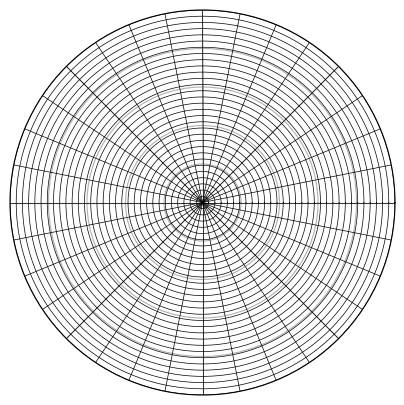

In [71]:
r_ticks = np.arange(0.0, 1.0, 0.05)
t_ticks = np.arange(0.0, 360.0, 10)

R = 1

Nt = 32
Nr = 32

dr = R / (Nr - 1)
dt = 2*np.pi / Nt

th_vals = np.arange(Nt) * dt
r_vals = np.arange(Nr) * dr

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='polar')
ax.set_theta_zero_location('E')  # 0° at +x
ax.set_theta_direction(-1)       # clockwise increasing theta

for th in th_vals:
    ax.plot([th, th], [0, R], "k", lw=0.5)

th_dense = np.linspace(0, 2*np.pi, 400)
for r in r_vals:
    ax.plot(th_dense, np.full_like(th_dense, r), "k", lw=0.5)

ax.set_yticklabels([])
ax.set_xticklabels([])
ax.set_rmax(R)

plt.savefig("/home/hd/hd_hd/hd_gy283/kmc_project/data/pngs/pde_grid.png")

plt.show()

In [30]:
import pandas as pd
import numpy as np

# Load CSVs: columns x,y,phi
mfem = pd.read_csv("/home/hd/hd_hd/hd_gy283/kmc_project/mfem_xy.csv")
lite = pd.read_csv("/home/hd/hd_hd/hd_gy283/kmc_project/lite_xy.csv")

# Join on (x,y). Assumes identical raster; if not, this will shrink to intersection.
df = mfem.merge(lite, on=["x","y"], suffixes=("_mfem","_lite"))
phi_m = df["phi_mfem"].to_numpy()
phi_l = df["phi_lite"].to_numpy()

# ---------- Plain (unaligned) errors ----------
diff = phi_m - phi_l
rmse = np.sqrt(np.mean(diff**2))
mae  = np.mean(np.abs(diff))
linf = np.max(np.abs(diff))
rng  = np.max(phi_m) - np.min(phi_m)
rel_rmse_pct = 100.0 * rmse / (rng if rng != 0 else 1.0)

print("=== Unaligned errors ===")
print(f"RMSE           : {rmse:.6g}")
print(f"MAE            : {mae:.6g}")
print(f"Linf (max abs) : {linf:.6g}")
print(f"Relative RMSE  : {rel_rmse_pct:.3f}%  (normalized by MFEM range)")

# ---------- Offset-only alignment (β) ----------
beta = np.mean(phi_m - phi_l)  # least-squares offset
diff_off = phi_m - (phi_l + beta)
rmse_off = np.sqrt(np.mean(diff_off**2))
linf_off = np.max(np.abs(diff_off))
mae_off  = np.mean(np.abs(diff_off))
rel_rmse_off = 100.0 * rmse_off / (rng if rng != 0 else 1.0)

print("\n=== Offset-aligned (φ_m ≈ φ_l + β) ===")
print(f"β (offset)     : {beta:.6g}")
print(f"RMSE           : {rmse_off:.6g}")
print(f"MAE            : {mae_off:.6g}")
print(f"Linf (max abs) : {linf_off:.6g}")
print(f"Relative RMSE  : {rel_rmse_off:.3f}%")

# ---------- Affine alignment (α, β) ----------
A = np.vstack([phi_l, np.ones_like(phi_l)]).T
alpha, beta_aff = np.linalg.lstsq(A, phi_m, rcond=None)[0]
diff_aff = phi_m - (alpha * phi_l + beta_aff)
rmse_aff = np.sqrt(np.mean(diff_aff**2))
linf_aff = np.max(np.abs(diff_aff))
mae_aff  = np.mean(np.abs(diff_aff))
rel_rmse_aff = 100.0 * rmse_aff / (rng if rng != 0 else 1.0)

print("\n=== Affine-aligned (φ_m ≈ α φ_l + β) ===")
print(f"α (scale)      : {alpha:.6g}")
print(f"β (offset)     : {beta_aff:.6g}")
print(f"RMSE           : {rmse_aff:.6g}")
print(f"MAE            : {mae_aff:.6g}")
print(f"Linf (max abs) : {linf_aff:.6g}")
print(f"Relative RMSE  : {rel_rmse_aff:.3f}%")

# ---------- Boundary-only error (diagnostic) ----------
# Grab points near the circle: r ≈ R
r = np.hypot(df["x"].to_numpy(), df["y"].to_numpy())
R = np.max(r)  # should be ~ your radius
mask_bdr = np.isclose(r, R, rtol=0, atol=R/ max(50, int(np.sqrt(len(r)))))  # a thin ring
if mask_bdr.any():
    bd = diff_aff[mask_bdr]
    print("\n=== Boundary (affine-aligned) ===")
    print(f"Boundary RMSE  : {np.sqrt(np.mean(bd**2)):.6g}")
    print(f"Boundary Linf  : {np.max(np.abs(bd)):.6g}")
else:
    print("\n[warn] Could not identify boundary ring in the raster.")

# ---------- Optional: write a difference map CSV ----------
out = df[["x","y"]].copy()
out["diff_aff"] = diff_aff  # best-aligned residual
out.to_csv("diff_aff_xy.csv", index=False)
print("\nWrote diff_aff_xy.csv (x,y,residual after affine alignment).")


=== Unaligned errors ===
RMSE           : 0.00921109
MAE            : 0.0056244
Linf (max abs) : 0.28823
Relative RMSE  : 0.307%  (normalized by MFEM range)

=== Offset-aligned (φ_m ≈ φ_l + β) ===
β (offset)     : -0.000141018
RMSE           : 0.00921001
MAE            : 0.00562031
Linf (max abs) : 0.288089
Relative RMSE  : 0.307%

=== Affine-aligned (φ_m ≈ α φ_l + β) ===
α (scale)      : 1.00598
β (offset)     : -0.000142801
RMSE           : 0.00868054
MAE            : 0.00538159
Linf (max abs) : 0.280841
Relative RMSE  : 0.289%

=== Boundary (affine-aligned) ===
Boundary RMSE  : 0.0216053
Boundary Linf  : 0.120662

Wrote diff_aff_xy.csv (x,y,residual after affine alignment).


['current', 'currentStd', 'sem', 'control', 'inputIdx', 'outputIdx']


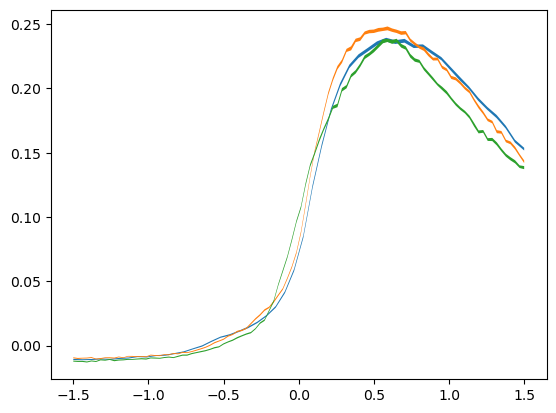

In [64]:
data_0 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/vMB_sim_444.npz")
data_1 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/vMB_sim_111.npz")
data_2 = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/vMB_sim_222.npz")
print(data_1.files)
x_100 = np.linspace(-1.5, 1.5, 100)
x_50 = np.linspace(-1.5, 1.5, 50)
plt.fill_between(x_50, data_0["current"]-data_0["sem"], data_0["current"]+data_0["sem"])
plt.fill_between(x_100, data_1["current"]-data_1["sem"], data_1["current"]+data_1["sem"])
plt.fill_between(x_100, data_2["current"]-data_2["sem"], data_2["current"]+data_2["sem"])

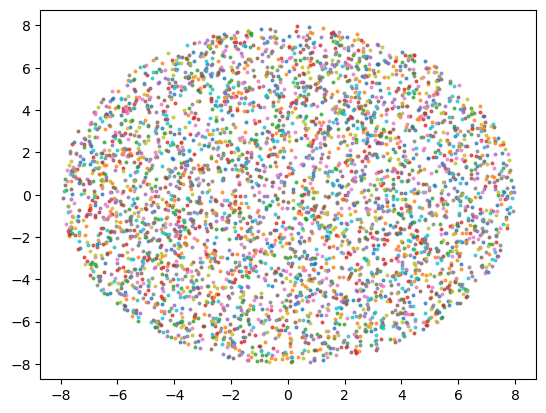

In [56]:
from sm_with_pos import SMPos
from train_sm import create_data_loaders

idx = np.random.randint(0, 25)
dummy_data = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/pos_batches_1e6/batch_{idx}.npz")

num_batches = 200
for b in range(num_batches):
    batch = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/pos_batches_1e6/batch_{b}.npz")
    #print(batch.files)
for i in range(20):
    plt.scatter(*dummy_data["acc_xy"][i].T, s=3.5, alpha=.7)

['inputIdx', 'outputIdx', 'currents', 'inputs', 'sampleStd', 'sem', 'acc_xy', 'don_xy']
(100,)
(100, 200, 2)


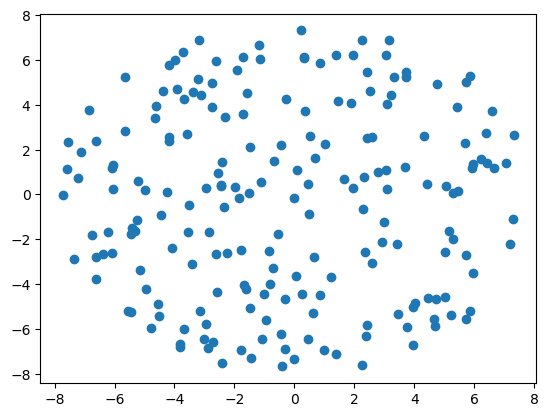

In [27]:
sim = np.load("/gpfs/bwfor/work/ws/hd_gy283-my_data/pos_batches_1e7/batch_0.npz")
print(sim.files)
print(sim["currents"].shape)
print(sim["acc_xy"].shape)
idx = np.random.randint(0, 100)
plt.scatter(*sim["acc_xy"][idx].T)

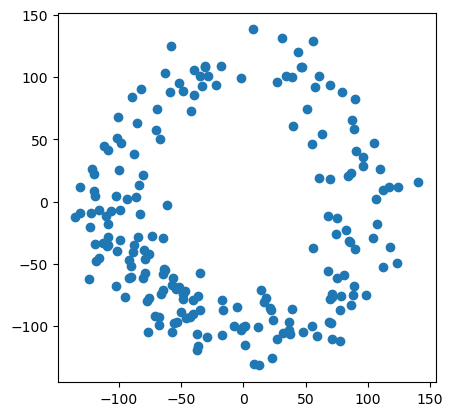

In [4]:
pos = np.loadtxt("/gpfs/bwfor/work/ws/hd_gy283-my_data/data_vMB/vMB_configs/acceptors.txt")
fig, ax = plt.subplots()
ax.scatter(*pos.T)
ax.set_aspect("equal")

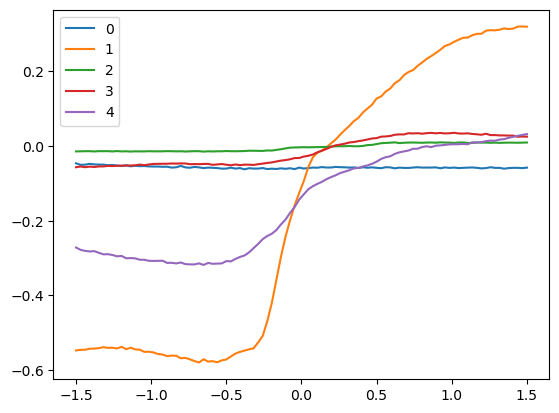

In [156]:
x = np.linspace(-1.5, 1.5, 100)
for i in range(5):
    data = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/sim_radial_distribution_{i}.npz")
    plt.plot(x, data["current"], label=i)
    plt.legend()

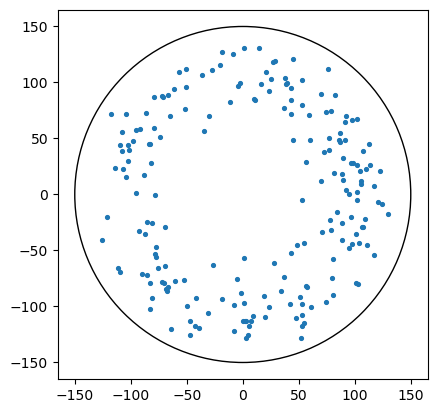

In [12]:
acc = np.loadtxt("/home/hd/hd_hd/hd_gy283/kmc_project/cpp_vMB.txt")
fig, ax = plt.subplots()
ax.scatter(*acc.T, s=7.5)
ax.add_patch(ps.Circle(xy=(0,0), radius=150.0, fill=None))
ax.set_aspect("equal")

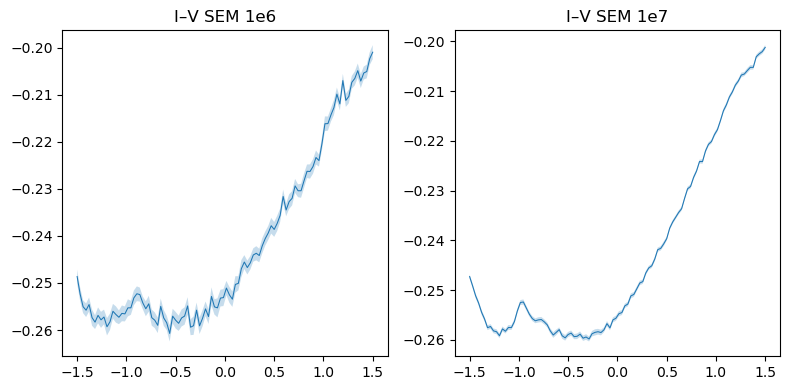

In [4]:
test_data_1e6 = np.load("/home/hd/hd_hd/hd_gy283/kmc_project/sim_vMB_test.npz")
test_data_1e7 = np.load("/home/hd/hd_hd/hd_gy283/kmc_project/sim_vMB_test_1e7.npz")

I_1e7 = test_data_1e7["current"]
I_sem_1e7 = test_data_1e7["sem"]

I_1e6 = test_data_1e6["current"]
I_sem_1e6 = test_data_1e6["sem"]

N = 100
vs = np.linspace(-1.5, 1.5, N)
fig, ax = plt.subplots(ncols=2, figsize=(8, 4))

for a in ax:
    a.set_aspect('auto')

#ax[0].errorbar(vs, I, yerr=I_sem, fmt='o', markersize=1.5, capsize=3, alpha=.7)
#ax[0].plot(vs, I, lw=1., linestyle="dashed", zorder=3)
#ax[0].set_title("I–V with uncertainty (SEM)")

ax[0].plot(vs, I_1e6, lw=0.75)
ax[0].fill_between(vs, I_1e6 - I_sem_1e6, I_1e6 + I_sem_1e6, alpha=0.25)
ax[0].set_title("I–V SEM 1e6")

ax[1].plot(vs, I_1e7, lw=0.75)
ax[1].fill_between(vs, I_1e7 - I_sem_1e7, I_1e7 + I_sem_1e7, alpha=0.25)
ax[1].set_title("I–V SEM 1e7")

plt.tight_layout()

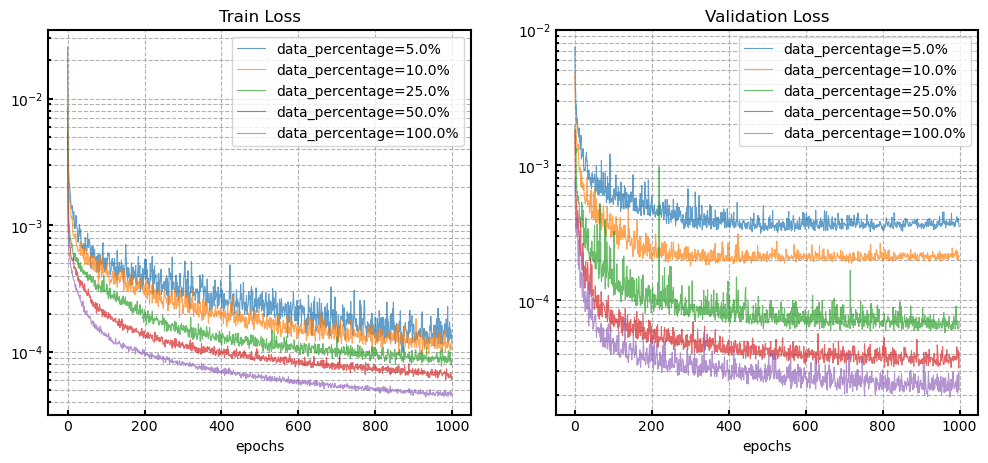

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from sm import NeuralNet

num_batches_list = [10, 20, 50, 100, 200]

fig, ax = plt.subplots(ncols=2, figsize=(12, 5))
norm = Normalize(vmin=min(num_batches_list), vmax=max(num_batches_list))
cmap = plt.get_cmap("jet")

for idx, i in enumerate(num_batches_list):
    checkpoint = torch.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/sm_vMB_MCSteps=1e7_num_batches={i}.pth", map_location=torch.device("cpu"), weights_only=False)
    model = NeuralNet(in_features=7, out_features=1, hidden_dim=checkpoint["args"]["hd"], num_layers=checkpoint["args"]["num_layers"])
    # Restore model parameters
    model.load_state_dict(checkpoint["model_state_dict"])
    
    # Restore training arguments (if needed)
    saved_args = checkpoint["args"]
    
    # Restore losses
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]
    plot_kwargs = {
        "lw": .8,
        "alpha": 0.7
    }

    for a in ax:
        a.spines[:].set_linewidth(1.5)
    
    ax[0].plot(train_losses, **plot_kwargs, label=f"data_percentage={100 * i*1000 / 200000}%")
    ax[0].set_yscale("log")
    ax[0].tick_params(which="both", direction="in", width=1.5)
    ax[0].legend()
    ax[0].set_aspect("auto")
    ax[0].set_xlabel("epochs")
    ax[0].grid(True, which="both", linestyle="dashed")#
    ax[0].set_title("Train Loss")
    
    ax[1].plot(val_losses, **plot_kwargs, label=f"data_percentage={100 * i*1000 / 200000}%")
    ax[1].set_yscale("log")
    ax[1].tick_params(which="both", direction="in", width=1.5)
    ax[1].legend()
    ax[1].set_aspect("auto")
    ax[1].set_xlabel("epochs")
    ax[1].grid(True, which="both", linestyle="dashed")
    ax[1].set_title("Validation Loss")

In [2]:
from tune_sm import find_control_voltages_1D

def target_function(t: torch.Tensor):
        N = t.shape[0]
        return 0.25*torch.sin(2*t)
    
min = -1.5
max = 1.5
N = 100
x = torch.linspace(min, max, N)
target = target_function(x).unsqueeze(1)

state_dict = torch.load(f="/home/hd/hd_hd/hd_gy283/kmc_project/models/SM_1e6_vonMises_beta_0.pth", map_location=torch.device("cpu"))
#print(state_dict)

in_features = 7
out_features = 1
hidden_dim = 90
num_layers = 10

model = NeuralNet(in_features=in_features, out_features=out_features, hidden_dim=hidden_dim, num_layers=num_layers)
model.load_state_dict(state_dict=state_dict)

input_idx = 0
study = find_control_voltages_1D(model=model, target=target, N=N, min_voltage=min, max_voltage=max, input_idx=input_idx, n_startup_trials=1000, n_trials=2_000, PRINT_EVERY=1000)

print("Best value:", study.best_value)
print("Best params:", study.best_params)  

4.4.0
cuda


TypeError: find_control_voltages_1D() got an unexpected keyword argument 'min_voltage'

v_list=[0.9087684029521395, 1.081264180783419, -0.31040417077013527, 1.3745292029787675, 0.01781493815272761, -0.29835713274305525]
noise=[-0.02607364 -0.04372324  0.07223905  0.05006392  0.07181847 -0.10867331]
c_v with noise=tensor([ 0.9088,  1.0813, -0.3104,  1.3745,  0.0178, -0.2984])


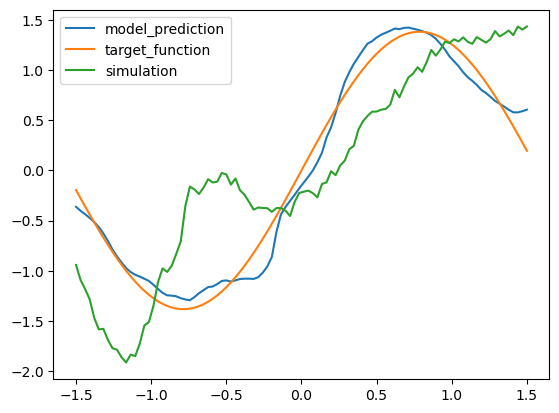

In [63]:
v_list = []
for k in study.best_params.keys():
    v_list.append(study.best_params[k])
print(f"v_list={v_list}")
v_array = np.array(v_list)
noise = np.random.normal(loc=0.0, scale=0.05, size=v_array.shape)
print(f"noise={noise}")

c_tensor = torch.tensor(v_list, dtype=torch.float32).expand(N, -1)
print(f"c_v with noise={c_tensor[0,:]}")
c_tensor_left = c_tensor[:, :input_idx]
c_tensor_right = c_tensor[:, input_idx:]
v_tensor = torch.linspace(-1.5, 1.5, N).unsqueeze(1)
input_tensor = torch.cat([c_tensor_left, v_tensor, c_tensor_right], dim=1)

y = model(input_tensor).detach().cpu()
x = torch.linspace(-1.5, 1.5, N)

y_norm = (y - y.mean()) / y.std()
target_norm = (target_function(x) - target_function(x).mean()) / target_function(x).std()

data = np.load("/home/hd/hd_hd/hd_gy283/kmc_project/simulated_curve_vonMises_beta_no_noise.npz")
current_norm = (data["current"] - data["current"].mean()) / data["current"].std()
plt.plot(x, y_norm, label="model_prediction")
plt.plot(x, target_norm, label="target_function")
plt.plot(x, current_norm, label="simulation")
plt.legend()

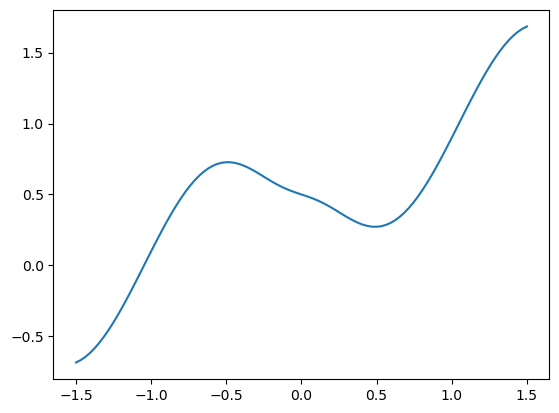

In [26]:
def test_target(t: torch.Tensor):
    N = t.shape[0]
    return -0.7*torch.sin(3*t) + torch.sigmoid(7*t)

x = torch.linspace(-1.5, 1.5, 100)

out = test_target(x)

plt.plot(x, out)

## 1.) Uniform Distribution

torch.Size([100, 1])


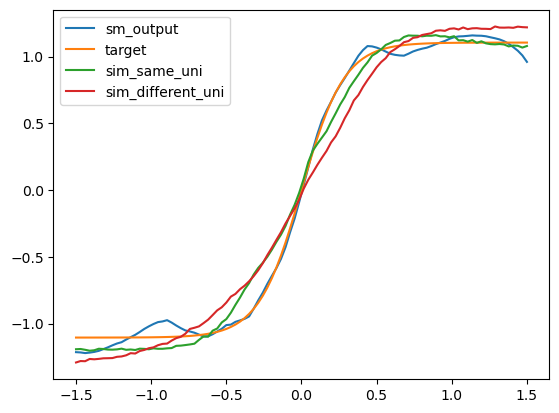

In [24]:
best_params = {'x_0': -1.3521200735168495, 'x_1': -1.4902781359421968, 'x_2': 1.1775679593714892, 'x_3': 1.4850596665151372, 'x_4': -0.5546491202122263, 'x_5': -0.5566989497370551}

v_list = []
for k in best_params.keys():
    v_list.append(best_params[k])

N = 100
c_volts = torch.tensor(v_list, dtype=torch.float32)
volts = torch.linspace(-1.5, 1.5, N, dtype=torch.float32).unsqueeze(1)
print(volts.shape)

input_tensor = c_volts.expand(N, -1)
input_tensor = torch.cat((input_tensor[:, :1], volts, input_tensor[:, 1:]), dim=1)

state_dict = torch.load(f="/home/hd/hd_hd/hd_gy283/kmc_project/models/SM_100k_0.pth", map_location=torch.device("cpu"))

in_features = 7
out_features = 1
hidden_dim = 90
num_layers = 7

model = NeuralNet(in_features=in_features, out_features=out_features, hidden_dim=hidden_dim, num_layers=num_layers)
model.load_state_dict(state_dict=state_dict)
model.eval()

y = model(input_tensor).detach().cpu()

def target_function(t: torch.Tensor):
        N = t.shape[0]
        return torch.sigmoid(7*t)
x = torch.linspace(-1.5, 1.5, N)

target = target_function(x)
target_norm = (target - target.mean()) / target.std()

data_0 = np.load("/home/hd/hd_hd/hd_gy283/kmc_project/simulated_curve_uni.npz")
current_norm_0 = (data_0["current"] - data_0["current"].mean()) / data_0["current"].std()

data_1 = np.load("/home/hd/hd_hd/hd_gy283/kmc_project/simulated_curve_different_uni.npz")
current_norm_1 = (data_1["current"] - data_1["current"].mean()) / data_1["current"].std()

y_norm = (y - y.mean()) / y.std()
plt.plot(x, y_norm, label="sm_output")
plt.plot(x, target_norm, label="target")
plt.plot(x, current_norm_0, label="sim_same_uni")
plt.plot(x, current_norm_1, label="sim_different_uni")
plt.legend()

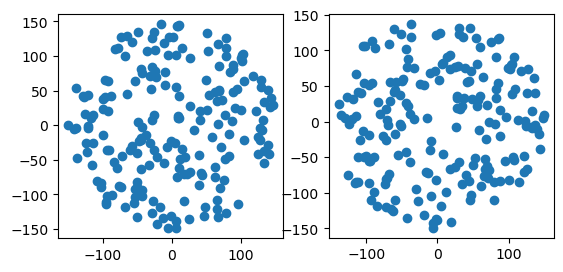

In [22]:
acc_1 = np.loadtxt("/home/hd/hd_hd/hd_gy283/kmc_project/configs/acc_0.txt")
acc_2 = np.loadtxt("/home/hd/hd_hd/hd_gy283/kmc_project/data/sm_batches/acceptors.txt")

fig, ax = plt.subplots(1, 2)

ax[0].set_aspect("equal")
ax[1].set_aspect("equal")

ax[0].scatter(*acc_1.T)
ax[1].scatter(*acc_2.T)

## 2.) von Mises and Beta

torch.Size([100, 1])
tensor([[-1.5000, -1.3362,  1.4418, -1.1590, -1.4984, -0.7704, -0.5946],
        [-1.4697, -1.3362,  1.4418, -1.1590, -1.4984, -0.7704, -0.5946],
        [-1.4394, -1.3362,  1.4418, -1.1590, -1.4984, -0.7704, -0.5946],
        [-1.4091, -1.3362,  1.4418, -1.1590, -1.4984, -0.7704, -0.5946],
        [-1.3788, -1.3362,  1.4418, -1.1590, -1.4984, -0.7704, -0.5946]])


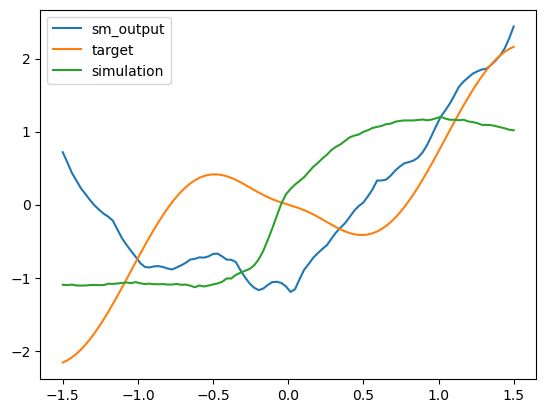

In [9]:
best_params = {'x_0': -1.3361728511258262, 'x_1': 1.441842973713247, 'x_2': -1.1589845724078525, 'x_3': -1.4984348328318093, 'x_4': -0.770405593405382, 'x_5': -0.5946394889964599}
v_list = []
for k in best_params.keys():
    v_list.append(best_params[k])

N = 100
c_volts = torch.tensor(v_list, dtype=torch.float32)
volts = torch.linspace(-1.5, 1.5, N, dtype=torch.float32).unsqueeze(1)
print(volts.shape)

input_tensor = c_volts.expand(N, -1)
input_tensor = torch.cat((volts, input_tensor), dim=1)
print(input_tensor[:5, :])
state_dict = torch.load(f="/home/hd/hd_hd/hd_gy283/kmc_project/models/SM_1e6_vonMises_beta_0.pth", map_location=torch.device("cpu"))

in_features = 7
out_features = 1
hidden_dim = 90
num_layers = 10

model = NeuralNet(in_features=in_features, out_features=out_features, hidden_dim=hidden_dim, num_layers=num_layers)
model.load_state_dict(state_dict=state_dict)
model.eval()

y = model(input_tensor).detach().cpu()

def target_function(t: torch.Tensor):
        N = t.shape[0]
        return -0.7*torch.sin(3*t) + torch.sigmoid(7*t)
x = torch.linspace(-1.5, 1.5, N)

data = np.load("/home/hd/hd_hd/hd_gy283/kmc_project/simulated_curve_vonMises_beta.npz")
current_norm = (data["current"] - data["current"].mean()) / data["current"].std()

target = target_function(x)
target_norm = (target - target.mean()) / target.std()
y_norm = (y - y.mean()) / y.std()
plt.plot(x, y_norm, label="sm_output")
plt.plot(x, target_norm, label="target")
plt.plot(x, current_norm, label="simulation")
plt.legend()

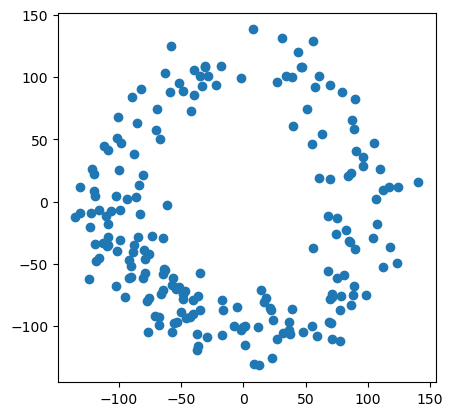

In [5]:
acc_0 = np.loadtxt("/home/hd/hd_hd/hd_gy283/kmc_project/data/sm_batches_1e6_vonMises_beta/acceptors.txt")
fig, ax = plt.subplots()
ax.set_aspect("equal")
ax.scatter(*acc_0.T)

In [ ]:
def target_function(x):

    target = 1 / (1 + np.exp(-4*x)) + -0.5*np.sin(4*x)

    return target

x = np.linspace(-1.5, 1.5, 100)

plt.plot(x, target_function(x))

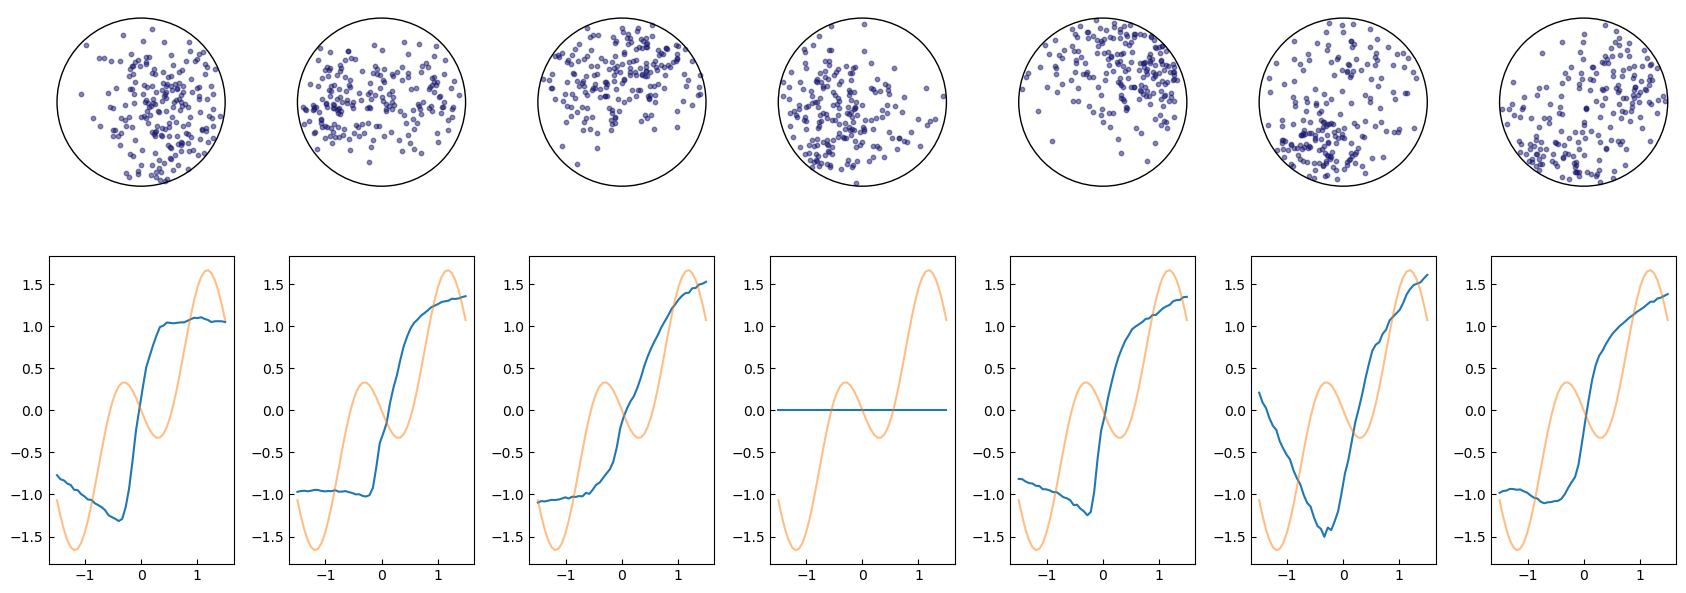

In [53]:
trials = 7
circle_kwargs = {
    "xy": (0,0),
    "radius": 150 + 2.5,
    "fill": None
}

x = np.linspace(-1.5, 1.5, 50)
fig, axs = plt.subplots(nrows=2, ncols=trials, figsize=(3*trials, 8))
for i in range(trials):
    pos = np.loadtxt(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/find_node_dist_test/trial_{i}/acceptors_trial={i}_sample=0.txt")
    data = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/find_node_dist_test/trial_{i}/curve_trial={i}_sample=0.npz")
    curve = (data["current"] - data["current"].mean()) / (data["current"].std() + 1e-8)
    target = target_function(x)
    target = (target - target.mean()) / (target.std() + 1e-8)
    axs[0, i].set_aspect("equal")
    axs[0, i].scatter(*pos.T, s=10, alpha=.5, c="midnightblue")
    axs[0, i].add_patch(ps.Circle(**circle_kwargs))
    axs[0, i].spines[["top", "bottom", "right", "left"]].set_visible(False)
    axs[0, i].set_xticks([])
    axs[0, i].set_yticks([])

    axs[1, i].set_aspect("auto")
    axs[1, i].plot(x, curve)
    axs[1, i].plot(x, target, alpha=.5, lw=1.5)
    axs[1, i].tick_params(direction="in")

plt.subplots_adjust(hspace=0.0, wspace=0.3)

['inputIdx', 'outputIdx', 'currents', 'inputs', 'acc_xy', 'don_xy', 'ele_xy', 'init_energies', 'acc_don_int', 'acc_acc_int', 'rand_energies', 'rate_prefactors', 'neighbours']
(100,)
(100, 8)
(100, 200, 2)
(100, 3, 2)
(8, 2)
(100, 208)
(100, 200)
(100, 200)
(100, 200)
(100, 208, 208)
(100, 208, 208)
5578
43264
12.892936390532544 %


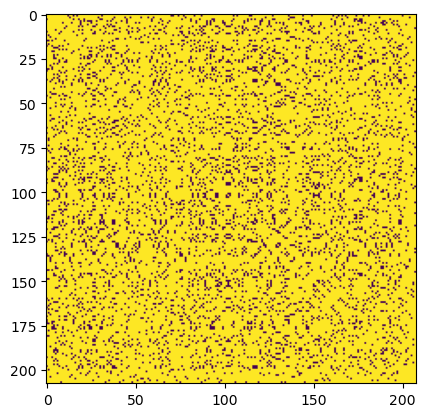

In [3]:
data = np.load(f"/gpfs/bwfor/work/ws/hd_gy283-my_data/independant_state_batches/test_batch_of_independant_states.npz")
print(data.files)

print(data["currents"].shape)
print(data["inputs"].shape)
print(data["acc_xy"].shape)
print(data["don_xy"].shape)
print(data["ele_xy"].shape)
print(data["init_energies"].shape)
print(data["acc_don_int"].shape)
print(data["acc_acc_int"].shape)
print(data["rand_energies"].shape)
print(data["rate_prefactors"].shape)
print(data["neighbours"].shape)
print(data["neighbours"][0].sum())

full_num_rates = data["neighbours"][0].shape[0]*data["neighbours"][0].shape[0]
print(data["neighbours"][0].shape[0]*data["neighbours"][0].shape[0])
print(100*data["neighbours"][0].sum() / full_num_rates, "%") 

plt.imshow(data["neighbours"][0], cmap="viridis_r")

In [65]:
def make_graph(
    currents,
    inputs,
    ele_pos,
    acc_pos,
    don_pos,
    init_energies,
    acc_don_int,
    acc_acc_int,
    rand_energies,
    rate_prefactors,
    neighbours
):
    
    graph = HeteroData()

    N_E = ele_pos.shape[0]
    N_A = acc_pos.shape[0]

    graph["electrode"].pos = torch.as_tensor(ele_pos, dtype=torch.float32)
    graph["acceptor"].pos = torch.as_tensor(acc_pos, dtype=torch.float32)

    total_acc_energies = torch.as_tensor(init_energies[:N_A], dtype=torch.float32).view(-1, 1)
    total_ele_energies = torch.as_tensor(init_energies[N_A:], dtype=torch.float32).view(-1, 1)

    acc_don_energy = torch.as_tensor(acc_don_int, dtype=torch.float32).view(-1, 1)
    acc_acc_energy = torch.as_tensor(acc_acc_int, dtype=torch.float32).view(-1, 1)
    acc_rand_energies = torch.as_tensor(rand_energies, dtype=torch.float32).view(-1, 1)

    acc_node_features = torch.cat([
        acc_don_energy,
        acc_acc_energy,
        acc_rand_energies], dim=-1)

    graph["electrode"].x = total_ele_energies
    graph["acceptor"].x = acc_node_features

    A_dense = torch.as_tensor(neighbours, dtype=torch.float32)
    R_dense = None if rate_prefactors is None else torch.as_tensor(rate_prefactors, dtype=torch.float32)

    A_dense = A_dense.clone()
    if A_dense.dtype.is_floating_point:
        A_dense.fill_diagonal_(0.0)
        mask_all = A_dense != 0
    else:
        A_dense.fill_diagonal_(0)
        mask_all = A_dense.bool()

    AA_mask = mask_all[:N_A, :N_A]
    AE_mask = mask_all[:N_A, N_A:N_A+N_E]
    EA_mask = mask_all[N_A:N_A+N_E, :N_A]
    EE_mask = mask_all[N_A:N_A+N_E, N_A:N_A+N_E]

    R_AA = R_AE = R_EA = R_EE = None
    if R_dense is not None:
        R_AA = R_dense[:N_A, :N_A]
        R_AE = R_dense[:N_A, N_A:N_A+N_E]
        R_EA = R_dense[N_A:N_A+N_E, :N_A]
        R_EE = R_dense[N_A:N_A+N_E, N_A:N_A+N_E]

    def add_edges(src_ntype, rel, dst_ntype, mask, R_block):
        
        if mask.numel() == 0:
            return
        r, c = mask.nonzero(as_tuple=True)
        if r.numel() == 0:
            return
        ei = torch.stack([r.long(), c.long()], dim=0)
        graph[(src_ntype, rel, dst_ntype)].edge_index = ei
        if R_block is not None:
            R_val = R_block[r, c].float().view(-1, 1)
            graph[(src_ntype, rel, dst_ntype)].edge_attr = R_val

    add_edges("acceptor", "A_A", "acceptor", AA_mask, R_AA)
    add_edges("acceptor", "A_E", "electrode", AE_mask, R_AE)
    add_edges("electrode", "E_A", "acceptor", EA_mask, R_EA)
    add_edges("electrode", "E_E", "electrode", EE_mask, R_EE)

    graph.y = torch.tensor([float(currents)], dtype=torch.float32)
    graph.inputs = torch.as_tensor(inputs, dtype=torch.float32).view(-1, 1)
    
    return graph

idx = 0
currents = data["currents"][idx]
inputs = data["inputs"][idx]
ele_pos = data["ele_xy"]
acc_pos = data["acc_xy"][idx]
don_pos = data["don_xy"][idx]
init_energies = data["init_energies"][idx]
acc_don_int = data["acc_don_int"][idx]
acc_acc_int = data["acc_acc_int"][idx]
rand_energies = data["rand_energies"][idx]
rate_prefactors = data["rate_prefactors"][idx]
neighbours = data["neighbours"][idx]

g = make_graph(
    currents,
    inputs,
    ele_pos, acc_pos, don_pos,
    init_energies, acc_don_int, acc_acc_int, rand_energies,
    rate_prefactors, neighbours
)

graph_list = []

for i in range(data["currents"].shape[0]):
    _g = make_graph(
            data["currents"][i],
            data["inputs"][i],
            data["ele_xy"], data["acc_xy"][i], data["don_xy"][i],
            data["init_energies"][i], data["acc_don_int"][i], data["acc_acc_int"][i], data["rand_energies"][i],
            data["rate_prefactors"][i], data["neighbours"][i]
    )

    graph_list.append(_g)  

print(len(graph_list))
        

100


In [ ]:
def sigmoid_fit(v, I_0, I_1, a, V_2):

    out = I_0 + (I_1 - I_0) / (1 + np.exp(-a*(v - V_2)))

    return out

def linear_fit(v, a, b):

    out = a*v + b

    return out

vs = np.linspace(-1.5, 1.5, 50)
n = 100
arr = np.zeros((n, n))

rows = []
for i in range(n):
    data = np.load(f"../../data/100_sweep/row_{i}.npz")
    rows.append(data["out"])
    for j in range(n):
        curve = data["out"][j]
        num_of_points = curve.shape[0]
        fit_params, cov = curve_fit(linear_fit, vs, curve)
        rmse = np.sqrt( np.mean( (curve - linear_fit(vs, fit_params[0], fit_params[1]))**2 ) )
        arr[i][j] = rmse

#flipped_arr = arr[::-1]

fig, ax = plt.subplots(figsize=(6,5))

im = ax.imshow(
    arr,
    extent=[0.01, 0.2,
            77, 200],
    aspect="auto",
    origin="lower",
    cmap="seismic_r"
)

xticks = np.linspace(0.01, 0.2, 5)
yticks = np.linspace(77, 200, 5)
ax.set_xticks(xticks)
ax.set_yticks(yticks)

plt.colorbar(im, ax=ax)

FileNotFoundError: [Errno 2] No such file or directory: '../../data/100_sweep/row_18.npz'

# 2.) Truncated Normal Geometry

7.978845608028652
3.191538243211461
std_scaled: 3.191538243211461


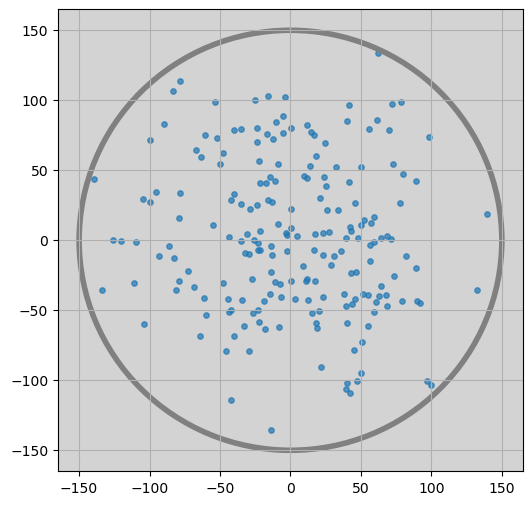

In [9]:
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

radius = 150.0
n_a = 200
n_d = 3
R = np.sqrt(np.pi*radius**2 / 200)
scaled_radius = radius / R
print(scaled_radius)
print(60. / R)

std_dev = radius / 2.5
std_scaled = std_dev / R
print(f"std_scaled: {std_scaled}")
cov_matrix = (std_dev ** 2) * np.eye(2)

if os.path.isfile("../../configs/acceptor_normal.txt"):
    pass
else:
    file = open("../../configs/acceptor_normal.txt", "x")

acceptor_pos = []

with open("../../configs/acceptor_normal.txt", "w") as f:
    while len(acceptor_pos) < 200:
        X = np.random.multivariate_normal(mean=np.zeros(2), cov=cov_matrix)
        if np.sqrt(X[0]**2 + X[1]**2) <= radius:
            acceptor_pos.append(X)

with open("../../configs/acceptor_normal.txt", "w") as f:
    for _pos in acceptor_pos:
        f.write(f"{_pos[0]}\t{_pos[1]}\n")

acceptors_array = np.array(acceptor_pos)

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(acceptors_array[:,0], acceptors_array[:,1], s=15., alpha=.7)
ax.grid()
ax.set_facecolor("lightgrey")    
boundary = Circle((0, 0), radius=radius, fill=False, edgecolor="gray", lw=4)
ax.add_patch(boundary)


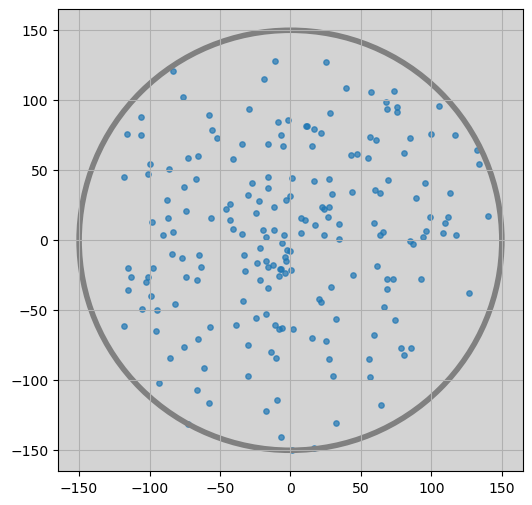

In [12]:
coordinates = []

with open("../../configs/acceptor_normal.txt", "r") as f:
    for _l in f:
        line = _l.strip().split()

        coords = np.array([float(line[0]), float(line[1])])
        coordinates.append(coords)

coordinate_array = np.array(coordinates)

fig, ax = plt.subplots(figsize=(6,6))

ax.scatter(coordinate_array[:,0], coordinate_array[:,1], s=15., alpha=.7)
ax.grid()
ax.set_facecolor("lightgrey")    
boundary = Circle((0, 0), radius=radius, fill=False, edgecolor="gray", lw=4)
ax.add_patch(boundary)


['ID', 'inputs', 'outputs']


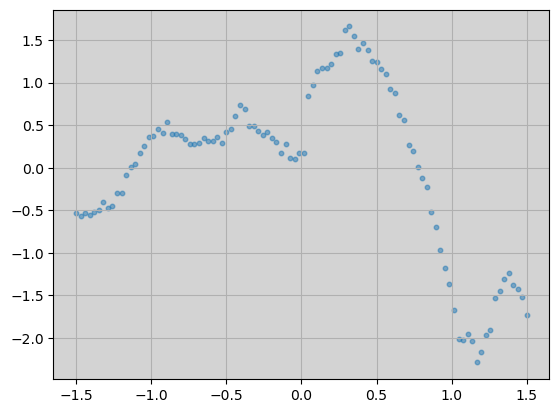

In [91]:
data = np.load("../../data/batch_10002.npz")
inputs = data["inputs"]

print(data.files)
num = len(data["outputs"][0,:])

vs = np.linspace(-1.5, 1.5, num)

plot_kwargs = {
    "s": 10.5,
    "alpha": .5,
}

fig, ax = plt.subplots()

output_mean = np.mean(data["outputs"][0, :])
output_std = np.std(data["outputs"][0, :], ddof=1)
normalized_outputs = (data["outputs"][0, :] - output_mean) / output_std

ax.scatter(vs, normalized_outputs, **plot_kwargs)
ax.grid()
ax.set_facecolor("lightgrey")

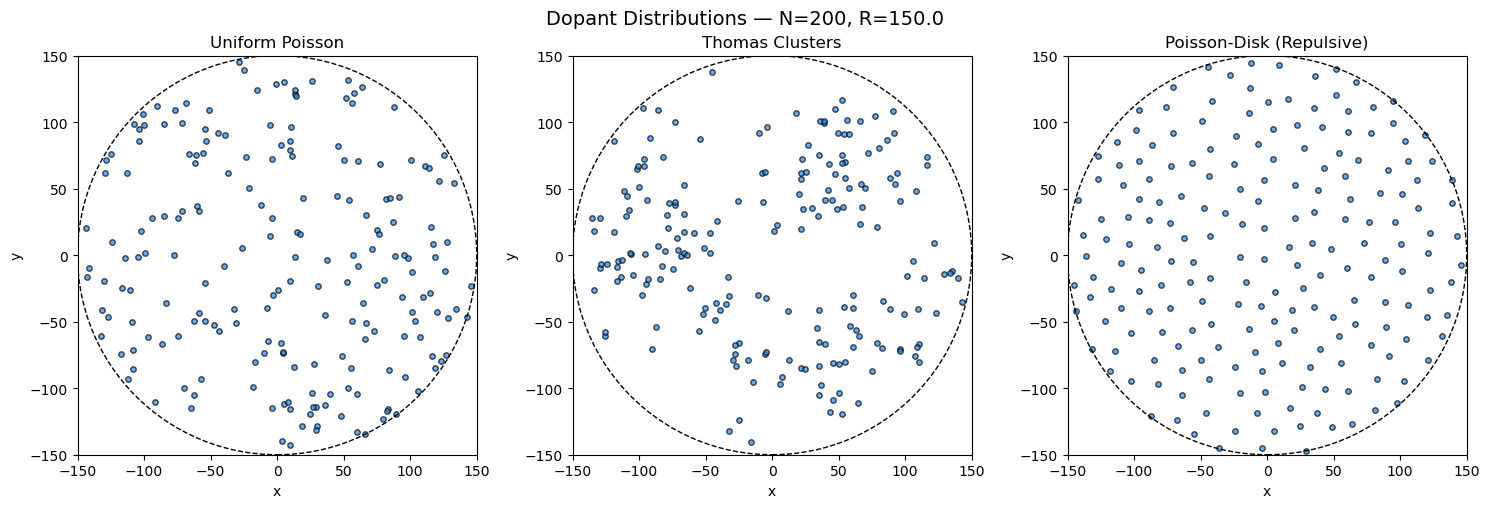

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# CONFIGURATION
# -----------------------------
R = 150.0      # disk radius
N = 200        # number of acceptors
seed = np.random.randint(0, 100000)      # reproducibility
rng = np.random.default_rng(seed)

# -----------------------------
# 1) Uniform Poisson
# -----------------------------
def sample_uniform_poisson(N, R, rng):
    # Sample polar coords
    phi = rng.uniform(0, 2*np.pi, N)
    r = R * np.sqrt(rng.uniform(0, 1, N))  # sqrt for uniform density
    x = r * np.cos(phi)
    y = r * np.sin(phi)
    return x, y

# -----------------------------
# 2) Thomas Process (Clustering)
# -----------------------------
def sample_thomas_process(N, R, sigma=20.0, mu=10, rng=None):
    """
    Thomas (Neyman-Scott) cluster process.
    sigma = std dev of cluster radius
    mu    = mean number of offspring per parent
    """
    area = np.pi * R**2
    kappa = N / (mu * area)  # parent density
    n_parents = rng.poisson(kappa * area)

    # Sample parent locations uniformly
    phi_p = rng.uniform(0, 2*np.pi, n_parents)
    r_p = R * np.sqrt(rng.uniform(0, 1, n_parents))
    px = r_p * np.cos(phi_p)
    py = r_p * np.sin(phi_p)

    xs, ys = [], []
    while len(xs) < N:
        # Choose a random parent
        idx = rng.integers(0, n_parents)
        cx, cy = px[idx], py[idx]

        # Gaussian displacement
        dx = rng.normal(0, sigma)
        dy = rng.normal(0, sigma)

        x = cx + dx
        y = cy + dy

        # Keep only if inside disk
        if x**2 + y**2 <= R**2:
            xs.append(x)
            ys.append(y)

    return np.array(xs), np.array(ys)

# -----------------------------
# 3) Hard-Core Poisson Disk (Repulsion)
# -----------------------------
def sample_poisson_disk(N, R, h=15.0, max_tries=10000, rng=None):
    """Simple dart-throwing Poisson-disk sampling."""
    xs, ys = [], []
    tries = 0
    h2 = h**2
    while len(xs) < N and tries < max_tries:
        tries += 1
        phi = rng.uniform(0, 2*np.pi)
        r = R * np.sqrt(rng.uniform(0, 1))
        x = r * np.cos(phi)
        y = r * np.sin(phi)

        # Check min distance constraint
        ok = True
        for xx, yy in zip(xs, ys):
            if (x-xx)**2 + (y-yy)**2 < h2:
                ok = False
                break
        if ok:
            xs.append(x)
            ys.append(y)
    return np.array(xs), np.array(ys)

# -----------------------------
# Generate three distributions
# -----------------------------
x_uni, y_uni = sample_uniform_poisson(N, R, rng)
x_tho, y_tho = sample_thomas_process(N, R, sigma=20.0, mu=10, rng=rng)
x_rep, y_rep = sample_poisson_disk(N, R, h=15.0, rng=rng)

# -----------------------------
# Visualization
# -----------------------------
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
titles = ["Uniform Poisson", "Thomas Clusters", "Poisson-Disk (Repulsive)"]

for ax, (x, y, title) in zip(axs, [(x_uni, y_uni, titles[0]),
                                  (x_tho, y_tho, titles[1]),
                                  (x_rep, y_rep, titles[2])]):
    ax.set_aspect("equal")
    ax.set_xlim(-R, R)
    ax.set_ylim(-R, R)
    ax.scatter(x, y, s=15, color="dodgerblue", alpha=0.7, edgecolor="k")
    circle = plt.Circle((0, 0), R, fill=False, color="black", linestyle="--")
    ax.add_artist(circle)
    ax.set_title(title)
    ax.set_xlabel("x")
    ax.set_ylabel("y")

plt.suptitle(f"Dopant Distributions — N={N}, R={R}", fontsize=14)
plt.tight_layout()
plt.show()
